<a href="https://colab.research.google.com/github/juhungaro/Pipoca/blob/main/Entrega2_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Etapa 1 – Pré-processamento dos Dados

*   Organizar os datasets de imagens e dados temporais coletados na Sprint 1.
*   Realizar tratamento dos dados, garantindo que estejam estruturados e prontos para serem usados no modelo.
*   Identificar padrões e sazonalidades na série temporal NDVI, explorando diferentes abordagens estatísticas para entender variações de produtividade.

# Produção agrícola 🌱🌽
Fonte de dados CONAB, série histórica grãos https://portaldeinformacoes.conab.gov.br/downloads/arquivos/SerieHistoricaGraos.txt



--- Bloco 1: Configuração Inicial e Upload (Milho CONAB) ---
Executando no Google Colab.
Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.
Diretórios 'dados_originais' e 'dados_processados' verificados/criados.

--- Limpando arquivo 'serie_historica_graos.csv' antigo de 'dados_originais' (se existir) ---
--- Arquivo 'serie_historica_graos.csv' não encontrado para limpar ---

--- Upload Arquivo CONAB ---
Faça o upload do arquivo: serie_historica_graos.csv


Saving serie_historica_graos.csv to serie_historica_graos.csv

Movendo arquivo carregado para 'dados_originais'...
  Arquivo carregado detectado: 'serie_historica_graos.csv'
  Movido e Renomeado: 'serie_historica_graos.csv' -> 'dados_originais/serie_historica_graos.csv'

[OK] Arquivo 'serie_historica_graos.csv' encontrado em 'dados_originais'.

--- Fim do Bloco 1: Configuração e Upload (Milho CONAB) ---

--- Bloco 2: Carregamento e Verificação Inicial (Milho CONAB) ---
[OK] Arquivo CONAB carregado: dados_originais/serie_historica_graos.csv
     Dimensões: (12453, 8)
     Primeiras 5 linhas:


,ano_agricola,dsc_safra_previsao,uf,produto,id_produto,area_plantada_mil_ha,producao_mil_t,produtividade_mil_ha_mil_t
0,1976/77,UNICA,AL,ALGODAO EM PLUMA,4586,99.3,6.0,0.1
1,1976/77,UNICA,BA,ALGODAO EM PLUMA,4586,123.4,7.0,0.1
2,1976/77,UNICA,CE,ALGODAO EM PLUMA,4586,1296.0,70.0,0.1
3,1976/77,UNICA,GO,ALGODAO EM PLUMA,4586,73.1,28.2,0.4
4,1976/77,UNICA,MA,ALGODAO EM PLUMA,4586,44.4,2.0,0.0



     Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12453 entries, 0 to 12452
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ano_agricola                12453 non-null  object 
 1   dsc_safra_previsao          12453 non-null  object 
 2   uf                          12453 non-null  object 
 3   produto                     12453 non-null  object 
 4   id_produto                  12453 non-null  int64  
 5   area_plantada_mil_ha        12453 non-null  float64
 6   producao_mil_t              12453 non-null  float64
 7   produtividade_mil_ha_mil_t  12453 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 778.4+ KB

--- Fim do Bloco 2: Carregamento e Verificação Inicial ---

--- Bloco 3: Tratamento e Filtragem (Milho CONAB) ---
  Iniciando tratamento. Linhas iniciais: 12453
    - Após filtro UF='MT': 597 linhas
    - Após filtro produto=

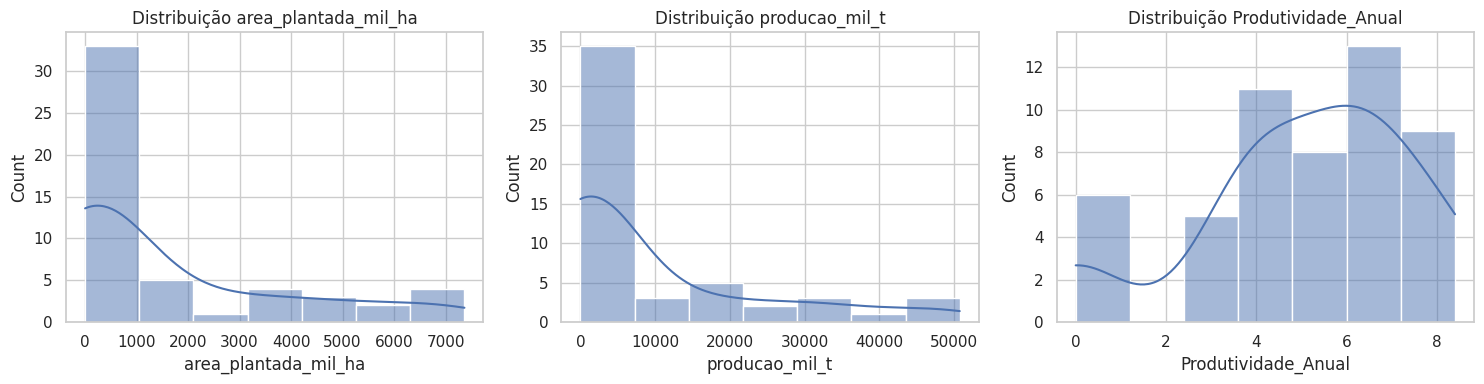


  Evolução temporal das métricas (por safra):


<Figure size 1400x600 with 0 Axes>

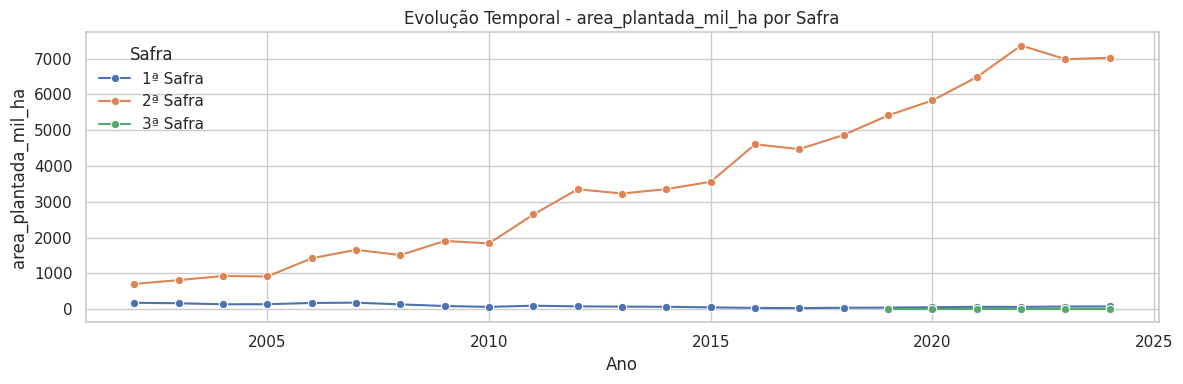

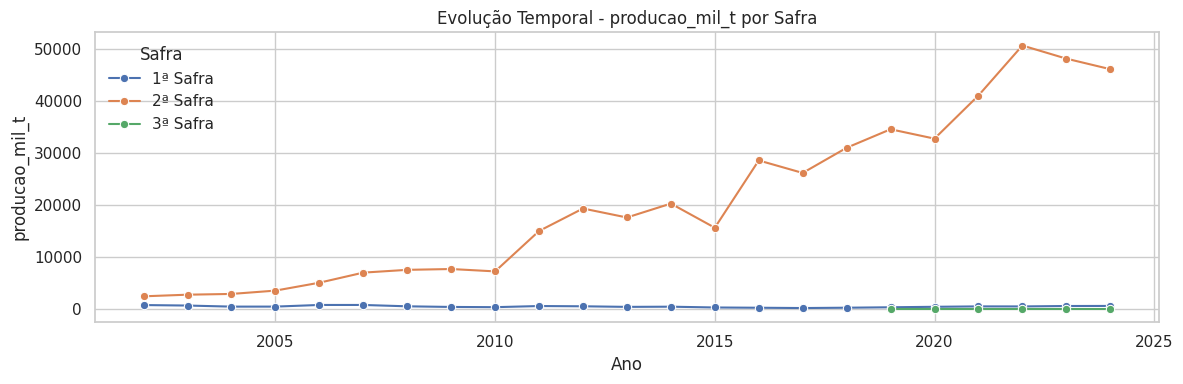

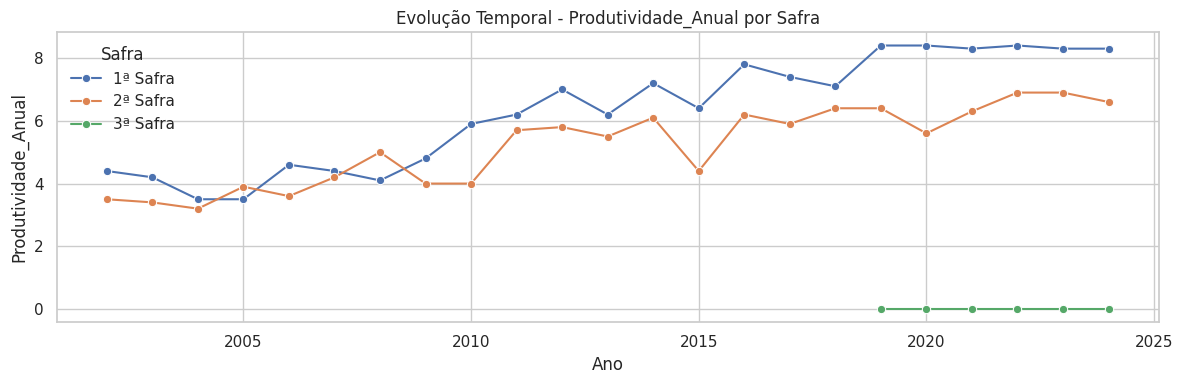


  Boxplot - Produtividade Anual por Ano e Safra:


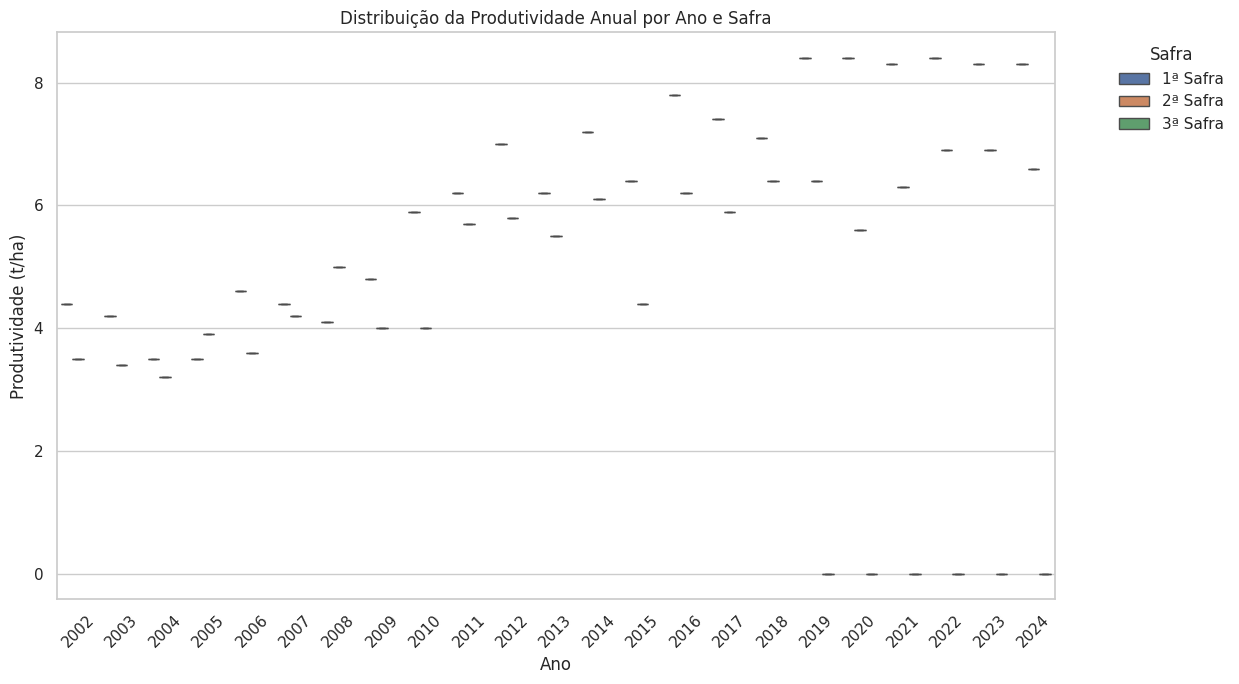


--- Fim do Bloco 4: Análise Exploratória ---

--- Bloco 5: Salvar Resultado Processado (Milho CONAB) ---
[OK] Dados de milho processados salvos em: dados_processados/milho.csv

  Informações do DataFrame Salvo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ANO                   52 non-null     Int64  
 1   safra                 52 non-null     object 
 2   area_plantada_mil_ha  52 non-null     float64
 3   producao_mil_t        52 non-null     float64
 4   Produtividade_Anual   52 non-null     float64
dtypes: Int64(1), float64(3), object(1)
memory usage: 2.2+ KB

  Primeiras linhas do DataFrame Salvo:
    ANO     safra  area_plantada_mil_ha  producao_mil_t  Produtividade_Anual
0  2002  1ª Safra                 176.0           772.0                  4.4
1  2002  2ª Safra                 704.0          2456.0                  

In [1]:
# -*- coding: utf-8 -*-
# Etapa 1: Pré-processamento Dados de Produção Agrícola (Milho CONAB - Blocos)

# --- Bloco 1: Configuração Inicial e Upload ---
# Objetivo: Importar bibliotecas, definir pastas, limpar arquivo antigo (se existir),
#           fazer upload (se Colab) e verificar se o arquivo está pronto.

print("--- Bloco 1: Configuração Inicial e Upload (Milho CONAB) ---")

# Importar Bibliotecas Essenciais
import pandas as pd
import numpy as np
import os
import re # Para expressões regulares (limpeza de 'safra')
import matplotlib.pyplot as plt
import seaborn as sns
import sys # Para controle de erro opcional
import shutil # Para mover arquivos

# Tentar importar do Colab para upload/download
try:
    from google.colab import files
    IN_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    IN_COLAB = False
    print("Executando localmente.")
    class DummyFiles: # Classe para simular 'files' localmente
        def upload(self):
            print("AVISO: files.upload() chamado, mas não disponível localmente.")
            print("       Coloque o arquivo 'serie_historica_graos.csv' na pasta 'dados_originais'.")
            # Simula um upload bem-sucedido para testes locais
            dummy_path = os.path.join('dados_originais', 'serie_historica_graos.csv')
            if not os.path.exists(dummy_path):
                 # Cria um arquivo vazio ou com cabeçalho mínimo
                 os.makedirs('dados_originais', exist_ok=True)
                 with open(dummy_path, 'w', encoding='utf-8') as f:
                      f.write("uf;produto;ano_agricola;dsc_safra_previsao;area_plantada_mil_ha;producao_mil_t;produtividade_mil_ha_mil_t\n")
                 print(f"       Arquivo dummy '{dummy_path}' criado para execução local.")
            return {os.path.basename(dummy_path): None} # Simula retorno do Colab

        def download(self, path):
             print(f"AVISO: files.download({path}) chamado, mas não disponível localmente.")
             print(f"       O arquivo processado está salvo em: {path}")
    files = DummyFiles()

# Configurações Gerais de Plotagem (opcional, pode herdar do notebook principal)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
    print("Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.")
except OSError:
    print("Estilo 'seaborn-v0_8-whitegrid' não encontrado, tentando 'seaborn-whitegrid'...")
    try:
        plt.style.use('seaborn-whitegrid')
        print("Estilo de plotagem 'seaborn-whitegrid' aplicado.")
    except OSError:
        print("Nenhum estilo seaborn encontrado. Usando estilo padrão do Matplotlib.")
sns.set(style="whitegrid")

# Definir Pastas (garante que existam)
pasta_dados_originais = 'dados_originais'
pasta_dados_processados = 'dados_processados'
os.makedirs(pasta_dados_originais, exist_ok=True)
os.makedirs(pasta_dados_processados, exist_ok=True)
print(f"Diretórios '{pasta_dados_originais}' e '{pasta_dados_processados}' verificados/criados.")

# Nome esperado do arquivo CONAB
nome_arquivo_conab = "serie_historica_graos.csv"
caminho_arquivo_conab_orig = os.path.join(pasta_dados_originais, nome_arquivo_conab)

# Limpeza de arquivo anterior (opcional, mas recomendado no Colab)
print(f"\n--- Limpando arquivo '{nome_arquivo_conab}' antigo de '{pasta_dados_originais}' (se existir) ---")
if os.path.exists(caminho_arquivo_conab_orig):
    try:
        os.remove(caminho_arquivo_conab_orig)
        print(f"  Removido: {nome_arquivo_conab}")
        print("--- Limpeza concluída ---")
    except OSError as e:
        print(f"  Erro ao remover {nome_arquivo_conab}: {e}")
else:
    print(f"--- Arquivo '{nome_arquivo_conab}' não encontrado para limpar ---")


# Upload do arquivo CONAB (se estiver no Colab)
if IN_COLAB:
    print("\n--- Upload Arquivo CONAB ---")
    print(f"Faça o upload do arquivo: {nome_arquivo_conab}")
    uploaded_conab = files.upload()
    print(f"\nMovendo arquivo carregado para '{pasta_dados_originais}'...")
    # Pega o nome do PRIMEIRO arquivo carregado (independente do nome exato)
    if uploaded_conab:
        uploaded_filename = list(uploaded_conab.keys())[0]
        print(f"  Arquivo carregado detectado: '{uploaded_filename}'")
        try:
            source_path = uploaded_filename # Nome do arquivo na pasta raiz do Colab
            # Define o caminho de DESTINO com o NOME PADRÃO esperado
            destination_path = os.path.join(pasta_dados_originais, nome_arquivo_conab)
            shutil.move(source_path, destination_path) # Move e RENOMEIA para o nome padrão
            print(f"  Movido e Renomeado: '{uploaded_filename}' -> '{destination_path}'")
        except Exception as e:
            print(f"Erro ao mover/renomear {uploaded_filename}: {e}.")
    else:
        print("  Nenhum arquivo foi carregado.")


# Verifica se o arquivo existe no local esperado COM O NOME PADRÃO
if os.path.exists(caminho_arquivo_conab_orig):
    print(f"\n[OK] Arquivo '{nome_arquivo_conab}' encontrado em '{pasta_dados_originais}'.")
else:
    print(f"\n[ERRO] Arquivo '{nome_arquivo_conab}' NÃO encontrado em '{pasta_dados_originais}'.")
    print("       Certifique-se de que o upload foi feito ou o arquivo está no local correto.")

print("\n--- Fim do Bloco 1: Configuração e Upload (Milho CONAB) ---")
# >>> Execute esta célula <<<

# --- Bloco 2: Carregamento e Verificação Inicial ---
# Objetivo: Carregar o arquivo CSV da CONAB em um DataFrame (df_conab_raw)
#           e realizar verificações básicas.

print("\n--- Bloco 2: Carregamento e Verificação Inicial (Milho CONAB) ---")

df_conab_raw = None # Inicializa

# Verifica se o caminho do arquivo foi definido no bloco anterior
# E se o arquivo realmente existe com o nome padrão esperado
if 'caminho_arquivo_conab_orig' in locals() and os.path.exists(caminho_arquivo_conab_orig):
    try:
        # Tenta ler com latin1, depois utf-8
        try:
            df_conab_raw = pd.read_csv(caminho_arquivo_conab_orig, sep=";", encoding='latin1')
        except UnicodeDecodeError:
            print("  Falha com latin1, tentando utf-8...")
            df_conab_raw = pd.read_csv(caminho_arquivo_conab_orig, sep=";", encoding='utf-8')
        print(f"[OK] Arquivo CONAB carregado: {caminho_arquivo_conab_orig}")
        print(f"     Dimensões: {df_conab_raw.shape}")
        print("     Primeiras 5 linhas:")
        # Usa display para melhor formatação no Colab/Jupyter
        from IPython.display import display
        display(df_conab_raw.head())
        print("\n     Informações do DataFrame:")
        df_conab_raw.info()

    except FileNotFoundError:
        print(f"[ERRO] Arquivo CONAB não encontrado em: {caminho_arquivo_conab_orig}")
    except Exception as e:
        print(f"[ERRO] Falha ao carregar o arquivo CONAB: {e}")
else:
    print("[ERRO] Caminho do arquivo CONAB não definido ou arquivo não existe. Execute o Bloco 1.")

print("\n--- Fim do Bloco 2: Carregamento e Verificação Inicial ---")
# >>> Execute esta célula APÓS o Bloco 1 <<<

# --- Bloco 3: Tratamento e Filtragem ---
# Objetivo: Aplicar filtros (UF, Produto, Ano), renomear colunas,
#           limpar dados ('safra'), tratar NaNs e criar colunas de ano.
#           Cria o df_milho_proc.

print("\n--- Bloco 3: Tratamento e Filtragem (Milho CONAB) ---")

df_milho_proc = None # Inicializa

# Só executa se o Bloco 2 criou df_conab_raw com sucesso
if 'df_conab_raw' in locals() and isinstance(df_conab_raw, pd.DataFrame):
    df_working = df_conab_raw.copy() # Trabalha em uma cópia
    ano_inicio_filtro = 2002 # Define o ano inicial desejado (igual ao clima)

    print(f"  Iniciando tratamento. Linhas iniciais: {len(df_working)}")

    # Filtro por UF = 'MT'
    if 'uf' in df_working.columns:
        df_working = df_working[df_working['uf'].str.upper() == 'MT'].copy()
        print(f"    - Após filtro UF='MT': {len(df_working)} linhas")
    else: print("    - [AVISO] Coluna 'uf' não encontrada para filtro.")

    # Filtro por produto = 'MILHO'
    if 'produto' in df_working.columns:
        df_working = df_working[df_working['produto'].str.strip().str.upper() == 'MILHO'].copy()
        print(f"    - Após filtro produto='MILHO': {len(df_working)} linhas")
    else: print("    - [AVISO] Coluna 'produto' não encontrada para filtro.")

    # Separar ano agrícola
    if 'ano_agricola' in df_working.columns:
        def separa_anos(ano_agricola):
            if isinstance(ano_agricola, str) and '/' in ano_agricola:
                a1, a2 = ano_agricola.split('/')
                try: a1_int = int(a1.strip())
                except: a1_int = None
                try: a2_int = int(a2.strip())
                except: a2_int = None
                return a1_int, a2_int
            elif isinstance(ano_agricola, str):
                try: return int(ano_agricola.strip()), None
                except: return None, None
            return None, None

        anos_split = df_working['ano_agricola'].apply(separa_anos)
        df_working['primeiro_ano'] = anos_split.str[0].astype('Int64')
        df_working['segundo_ano'] = anos_split.str[1].astype('Int64')
        print("    - Colunas 'primeiro_ano' e 'segundo_ano' criadas/atualizadas.")
    else: print("    - [AVISO] Coluna 'ano_agricola' não encontrada.")

    # Renomear colunas principais
    rename_map_milho = {
        'dsc_safra_previsao': 'safra',
        'area_plantada_mil_ha': 'area_plantada_mil_ha',
        'producao_mil_t': 'producao_mil_t',
        'produtividade_mil_ha_mil_t': 'produtividade_t_ha' # t/ha
    }
    cols_a_renomear_milho = {k: v for k, v in rename_map_milho.items() if k in df_working.columns}
    df_working.rename(columns=cols_a_renomear_milho, inplace=True)
    print(f"    - Colunas renomeadas: {list(cols_a_renomear_milho.values())}")

    # Padronizar coluna 'safra'
    if 'safra' in df_working.columns:
        def padroniza_safra(s):
            if not isinstance(s, str): return s
            s = s.upper().strip()
            s = re.sub(r'1[ÂAªAa]*\s*SAFRA', '1ª SAFRA', s)
            s = re.sub(r'2[ÂAªAa]*\s*SAFRA', '2ª SAFRA', s)
            s = re.sub(r'3[ÂAªAa]*\s*SAFRA', '3ª SAFRA', s)
            s = re.sub(r'UNICA', 'ÚNICA', s)
            return s.title()
        df_working['safra'] = df_working['safra'].apply(padroniza_safra)
        print("    - Coluna 'safra' padronizada.")
    else: print("    - [AVISO] Coluna 'safra' não encontrada para padronização.")

    # Filtrar por ano >= ano_inicio_filtro (usando 'primeiro_ano')
    if 'primeiro_ano' in df_working.columns:
        linhas_antes_filtro_ano = len(df_working)
        # Garante que 'primeiro_ano' é numérico antes de filtrar
        df_working['primeiro_ano'] = pd.to_numeric(df_working['primeiro_ano'], errors='coerce')
        df_working = df_working[df_working['primeiro_ano'] >= ano_inicio_filtro].copy()
        removidos_filtro_ano = linhas_antes_filtro_ano - len(df_working)
        if removidos_filtro_ano > 0:
             print(f"    - Removidas {removidos_filtro_ano} linhas com ano < {ano_inicio_filtro}.")
        print(f"    - Após filtro ano >= {ano_inicio_filtro}: {len(df_working)} linhas")
    else: print(f"    - [AVISO] Coluna 'primeiro_ano' não disponível para filtro de ano.")

    # Converter colunas numéricas finais e tratar NaNs
    colunas_numericas_milho = ['area_plantada_mil_ha', 'producao_mil_t', 'produtividade_t_ha']
    print("    - Convertendo colunas numéricas finais e tratando NaNs:")
    for col in colunas_numericas_milho:
         if col in df_working.columns:
              df_working[col] = pd.to_numeric(df_working[col], errors='coerce')
              print(f"      Coluna '{col}' convertida para numérico.")
         else:
              print(f"      Atenção: Coluna '{col}' não encontrada.")

    # Remover linhas com NaNs nas colunas essenciais
    colunas_essenciais_milho = ['primeiro_ano', 'safra'] + colunas_numericas_milho
    colunas_presentes_milho = [col for col in colunas_essenciais_milho if col in df_working.columns]
    linhas_antes_nan = len(df_working)
    df_working.dropna(subset=colunas_presentes_milho, inplace=True)
    removidos_nan = linhas_antes_nan - len(df_working)
    if removidos_nan > 0: print(f"    - {removidos_nan} linhas removidas devido a NaNs em colunas essenciais.")

    # Renomear colunas de ano e produtividade para padrão final
    df_working = df_working.rename(columns={'primeiro_ano': 'ANO', 'produtividade_t_ha': 'Produtividade_Anual'})
    print("    - Colunas 'primeiro_ano' -> 'ANO' e 'produtividade_t_ha' -> 'Produtividade_Anual' renomeadas.")

    # Selecionar e reordenar colunas finais
    colunas_finais_milho = ['ANO', 'safra', 'area_plantada_mil_ha', 'producao_mil_t', 'Produtividade_Anual']
    colunas_presentes_milho_final = [col for col in colunas_finais_milho if col in df_working.columns]
    df_milho_proc = df_working[colunas_presentes_milho_final].reset_index(drop=True)

    # <<< IMPORTANTE: Tratar múltiplas safras por ano >>>
    # Se houver mais de uma linha por ANO (ex: 1ª e 2ª safra), precisamos decidir como agregar
    # Opção 1: Manter separado (adicionar coluna 'safra' ao groupby em etapas futuras)
    # Opção 2: Calcular uma média/soma anual (pode perder informação)
    # Opção 3: Focar em uma safra específica (ex: 2ª safra)
    # Por enquanto, vamos manter separado, mas isso afetará o merge na Etapa 2
    print("\n    Verificando se há múltiplas safras por ano...")
    contagem_anos = df_milho_proc['ANO'].value_counts()
    anos_multiplos = contagem_anos[contagem_anos > 1].index.tolist()
    if anos_multiplos:
        print(f"    [AVISO] Anos com múltiplas safras encontradas: {sorted(anos_multiplos)}")
        print("            A base 'milho.csv' conterá múltiplas linhas para esses anos.")
        print("            A Etapa 2 precisará ser ajustada para lidar com isso (ex: agrupar por ANO e SAFRA ou calcular média anual).")
    else:
        print("    [INFO] Apenas uma entrada por ano encontrada (ou múltiplas safras já foram agregadas).")


    print(f"\n[OK] Processamento concluído. Base final: {df_milho_proc.shape[0]} linhas x {df_milho_proc.shape[1]} colunas.")
    print("     Primeiras 5 linhas:")
    print(df_milho_proc.head())
    print("\n     Tipos de dados finais:")
    print(df_milho_proc.dtypes)
    print("\n     Verificação final de nulos:")
    print(df_milho_proc.isnull().sum())

else:
    print("[ERRO] DataFrame bruto 'df_conab_raw' não foi criado na etapa anterior.")

print("\n--- Fim do Bloco 3: Tratamento e Filtragem ---")
# >>> Execute esta célula APÓS o Bloco 2 <<<


# --- Bloco 4: Análise Exploratória ---
# Objetivo: Gerar gráficos para entender a distribuição e evolução
#           dos dados de produção/produtividade de milho processados.

print("\n--- Bloco 4: Análise Exploratória (Milho CONAB) ---")

# Só executa se o Bloco 3 criou df_milho_proc com sucesso
if 'df_milho_proc' in locals() and isinstance(df_milho_proc, pd.DataFrame) and not df_milho_proc.empty:

    colunas_numericas_plot = ['area_plantada_mil_ha', 'producao_mil_t', 'Produtividade_Anual']
    colunas_numericas_plot = [col for col in colunas_numericas_plot if col in df_milho_proc.columns] # Garante que existem

    if colunas_numericas_plot:
        # Distribuições (histogramas)
        print("\n  Histogramas - Distribuição das variáveis:")
        n_cols_plot = len(colunas_numericas_plot)
        plt.figure(figsize=(5 * n_cols_plot, 4))
        for i, coluna in enumerate(colunas_numericas_plot):
            plt.subplot(1, n_cols_plot, i + 1)
            sns.histplot(df_milho_proc[coluna], kde=True)
            plt.title(f'Distribuição {coluna}')
        plt.tight_layout()
        plt.show()

        # Séries temporais (Agrupando por ANO e SAFRA para ver evolução)
        print("\n  Evolução temporal das métricas (por safra):")
        if 'ANO' in df_milho_proc.columns and 'safra' in df_milho_proc.columns:
            # Pivotear para ter safras como colunas ou usar hue no lineplot
            plt.figure(figsize=(14, 6))
            # Usar 'hue' para separar linhas por safra
            for coluna in colunas_numericas_plot:
                 # Cria um subplot para cada métrica para clareza
                 plt.figure(figsize=(12, 4))
                 sns.lineplot(data=df_milho_proc, x='ANO', y=coluna, hue='safra', marker='o', errorbar=None) # errorbar=None se não quiser desvio
                 plt.title(f'Evolução Temporal - {coluna} por Safra')
                 plt.xlabel('Ano')
                 plt.ylabel(coluna)
                 plt.legend(title='Safra')
                 plt.grid(True)
                 plt.tight_layout()
                 plt.show()
        else:
            print("    - [AVISO] Colunas 'ANO' ou 'safra' não encontradas para plotar série temporal por safra.")

        # Boxplots por Ano (Produtividade, separado por safra)
        print("\n  Boxplot - Produtividade Anual por Ano e Safra:")
        if 'ANO' in df_milho_proc.columns and 'Produtividade_Anual' in df_milho_proc.columns and 'safra' in df_milho_proc.columns:
             df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce')
             df_milho_proc_plot = df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'])
             if not df_milho_proc_plot.empty:
                  plt.figure(figsize=(14, 7)) # Aumenta tamanho
                  sns.boxplot(x='ANO', y='Produtividade_Anual', hue='safra', data=df_milho_proc_plot)
                  plt.title('Distribuição da Produtividade Anual por Ano e Safra')
                  plt.xlabel('Ano')
                  plt.ylabel('Produtividade (t/ha)')
                  plt.xticks(rotation=45)
                  plt.grid(True, axis='y')
                  plt.legend(title='Safra', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legenda
                  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Ajusta layout para legenda
                  plt.show()
             else: print("    - [AVISO] Não há dados válidos para gerar boxplot anual por safra.")
        else: print("    - [AVISO] Colunas 'ANO', 'Produtividade_Anual' ou 'safra' não encontradas para boxplot.")

    else:
        print("  Nenhuma coluna numérica encontrada para plotar.")
else:
    print("  DataFrame processado 'df_milho_proc' não disponível ou vazio. Análise exploratória pulada.")

print("\n--- Fim do Bloco 4: Análise Exploratória ---")
# >>> Execute esta célula APÓS o Bloco 3 <<<


# --- Bloco 5: Salvar Resultado Processado ---
# Objetivo: Salvar o DataFrame processado (df_milho_proc) em um arquivo CSV.

print("\n--- Bloco 5: Salvar Resultado Processado (Milho CONAB) ---")

# Só salva se o Bloco 3 criou df_milho_proc com sucesso
if 'df_milho_proc' in locals() and isinstance(df_milho_proc, pd.DataFrame) and not df_milho_proc.empty:
    # Define o caminho de saída
    caminho_saida_milho = os.path.join(pasta_dados_processados, 'milho.csv')
    try:
        # Salva o DataFrame final
        df_milho_proc.to_csv(caminho_saida_milho, index=False, encoding='utf-8')
        print(f"[OK] Dados de milho processados salvos em: {caminho_saida_milho}")
        print("\n  Informações do DataFrame Salvo:")
        df_milho_proc.info()
        print("\n  Primeiras linhas do DataFrame Salvo:")
        print(df_milho_proc.head())
    except Exception as e:
        print(f"[ERRO] Falha ao salvar o arquivo processado: {e}")
else:
    print("[ERRO] DataFrame processado 'df_milho_proc' não disponível ou vazio. Nenhum arquivo salvo.")

print("\n--- Fim do Bloco 5: Salvar Resultado ---")
print("\n=== FIM DA ETAPA 1 (Processamento Milho CONAB) ===")
# >>> Execute esta célula APÓS o Bloco 3 (e opcionalmente Bloco 4) <<<


# Dados SatVeg

Dados obtidos do sensor SatVeg para a Fazenda São José, Sorriso-MT
Coordenadas: -55.95520,-12.88229 | -55.95729,-12.88229

--- Bloco 1: Configuração Inicial e Upload (SatVeg) ---
Executando no Google Colab.
Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.
Diretórios 'dados_originais' e 'dados_processados' verificados/criados.

--- Limpando arquivo 'satveg_original.csv' antigo de 'dados_originais' (se existir) ---
--- Arquivo 'satveg_original.csv' não encontrado para limpar ---

--- Upload Arquivo SatVeg ---
Faça o upload do seu arquivo CSV do SatVeg (separador ';', encoding latin1)


Saving dados_satveg.csv to dados_satveg.csv

Movendo arquivo carregado para 'dados_originais'...
  Arquivo carregado detectado: 'dados_satveg.csv'
  Movido e Renomeado: 'dados_satveg.csv' -> 'dados_originais/satveg_original.csv'

[OK] Arquivo 'satveg_original.csv' encontrado em 'dados_originais'.

--- Fim do Bloco 1: Configuração e Upload (SatVeg) ---

--- Bloco 2: Carregamento e Verificação Inicial (SatVeg) ---
[OK] Arquivo SatVeg carregado: dados_originais/satveg_original.csv
     Dimensões: (576, 4)
     Primeiras 5 linhas:


,Data,NDVI,PreFiltro,FlatBottom
0,18/02/2000,"0,6119","0,6542","0,6542"
1,05/03/2000,"0,6542","0,6542","0,6542"
2,21/03/2000,"0,5751","0,5751","0,6542"
3,06/04/2000,"0,6839","0,6839","0,6839"
4,22/04/2000,"0,4797","0,4797","0,4808"



     Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Data        576 non-null    object
 1   NDVI        576 non-null    object
 2   PreFiltro   576 non-null    object
 3   FlatBottom  576 non-null    object
dtypes: object(4)
memory usage: 18.1+ KB

--- Fim do Bloco 2: Carregamento e Verificação Inicial ---

--- Bloco 3: Pré-processamento (SatVeg) ---
  Iniciando pré-processamento. Linhas iniciais: 576
    - Coluna 'Data' convertida para datetime.
    - Colunas 'ANO', 'MES', 'AnoMes' criadas.
    - Convertendo colunas numéricas:
      Coluna 'NDVI' convertida para float.
      Coluna 'PreFiltro' convertida para float.
      Coluna 'FlatBottom' convertida para float.
    - Coluna 'NDVI_media_mensal' calculada.
    - Verificação de nulos PÓS-processamento:
      Não há valores nulos.
[OK] Pré-processamento SatVeg concluído

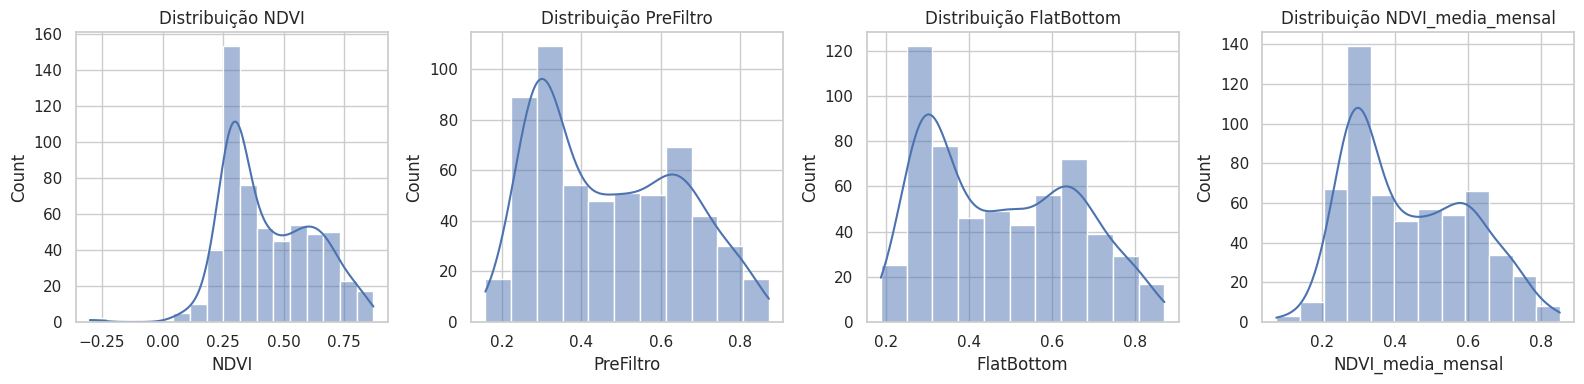


  Série Temporal - NDVI Original:


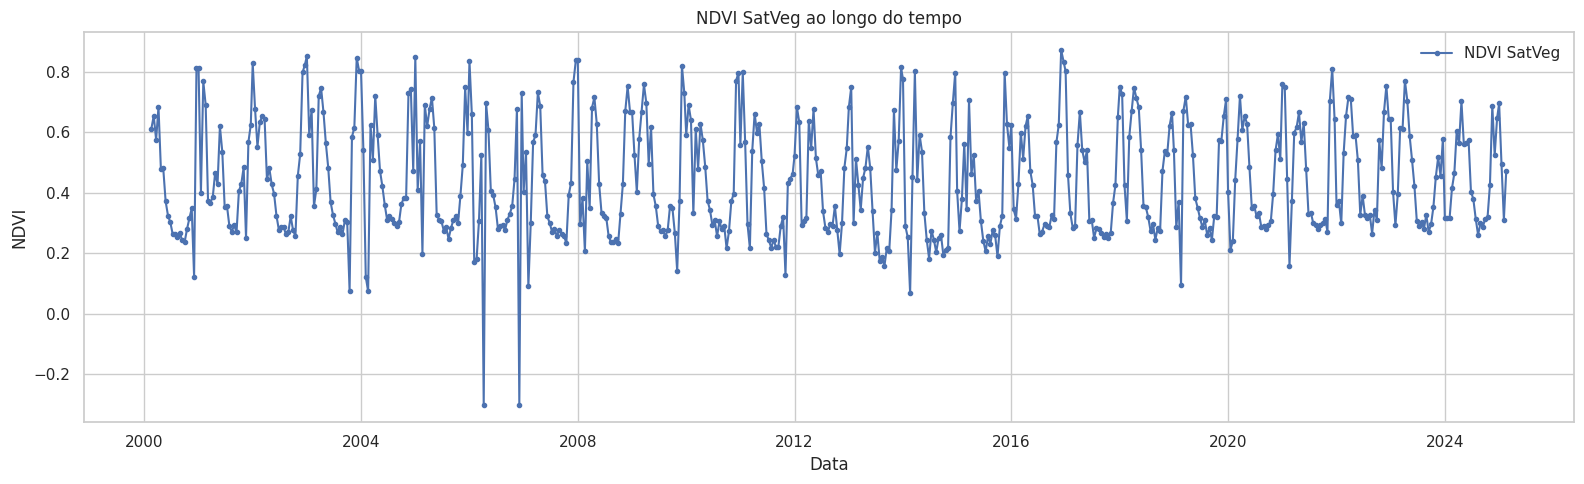


  Perfil Sazonal Médio - NDVI Original:


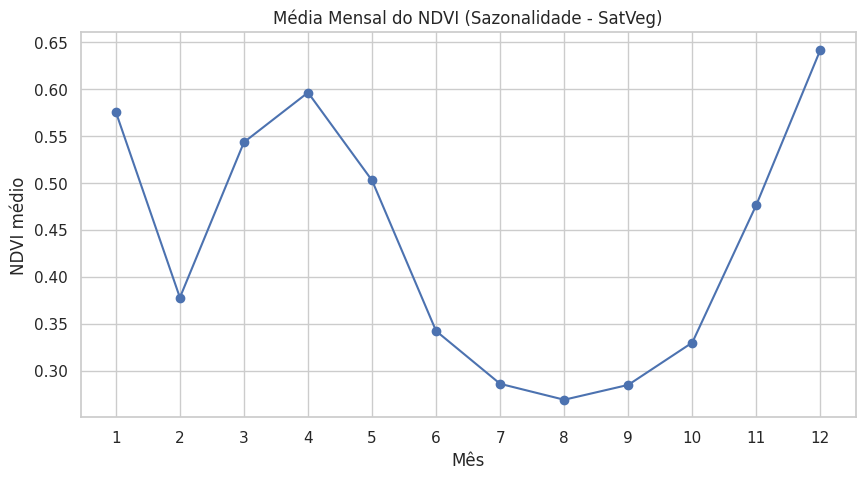


  Decomposição da Série Temporal (NDVI Médio Mensal):


<ipython-input-2-1e93f49fb89a>:281: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ndvi_monthly_decomp = df_satveg_proc.set_index('Data')['NDVI_media_mensal'].resample('M').mean().interpolate()


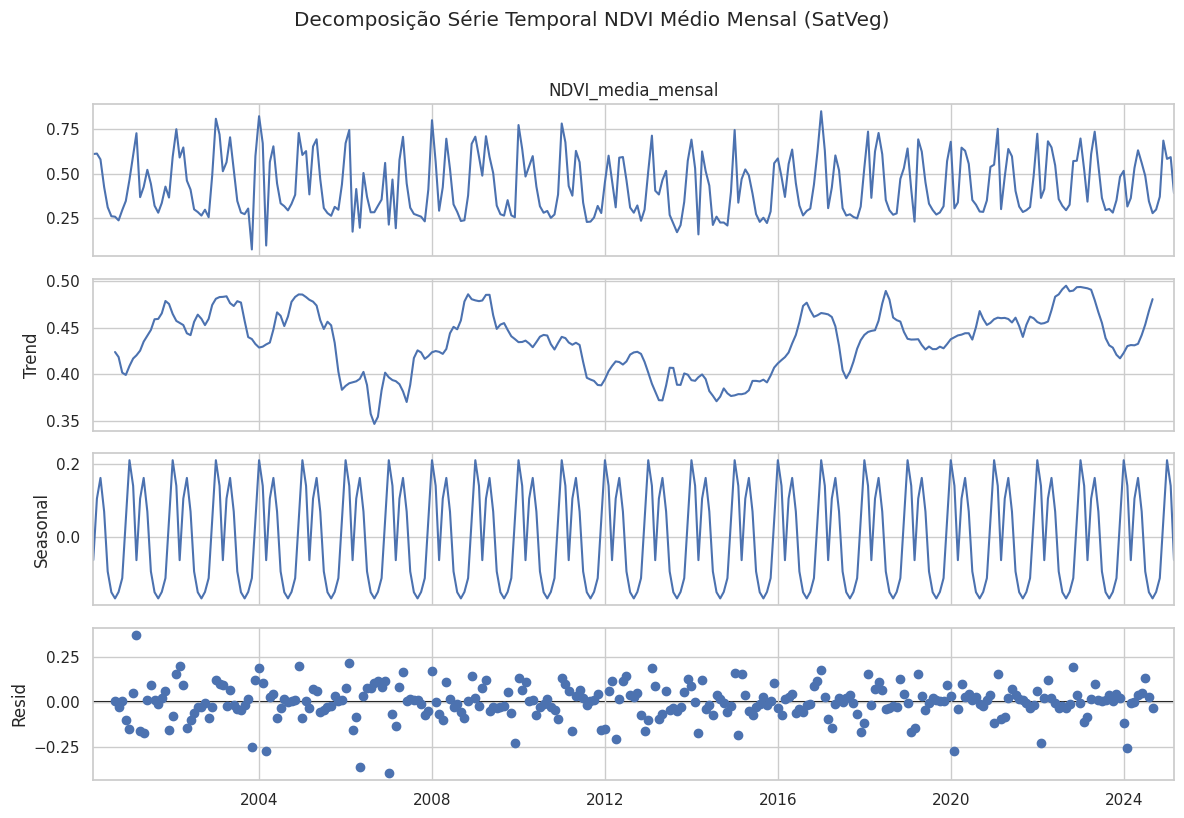


--- Fim do Bloco 4: Análise Exploratória ---

--- Bloco 5: Salvar Resultado Processado (SatVeg) ---
[OK] Dados SatVeg processados salvos em: dados_processados/satveg_processado.csv

  Informações do DataFrame Salvo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Data               576 non-null    datetime64[ns]
 1   ANO                576 non-null    Int64         
 2   MES                576 non-null    Int64         
 3   AnoMes             576 non-null    object        
 4   NDVI               576 non-null    float64       
 5   PreFiltro          576 non-null    float64       
 6   FlatBottom         576 non-null    float64       
 7   NDVI_media_mensal  576 non-null    float64       
dtypes: Int64(2), datetime64[ns](1), float64(4), object(1)
memory usage: 37.3+ KB

  Primeiras linhas do DataFrame Salvo:
       

In [2]:
# -*- coding: utf-8 -*-
# Etapa 1: Pré-processamento Dados SatVeg (Blocos Separados)

# --- Bloco 1: Configuração Inicial e Upload ---
# Objetivo: Importar bibliotecas, definir pastas, limpar arquivo antigo (se existir),
#           fazer upload (se Colab) e verificar se o arquivo está pronto.

print("--- Bloco 1: Configuração Inicial e Upload (SatVeg) ---")

# Importar Bibliotecas Essenciais
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import shutil
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

# Tentar importar do Colab para upload/download
try:
    from google.colab import files
    IN_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    IN_COLAB = False
    print("Executando localmente.")
    class DummyFiles:
        def upload(self):
            print("AVISO: files.upload() chamado, mas não disponível localmente.")
            print("       Coloque o arquivo CSV do SatVeg na pasta 'dados_originais'.")
            # Simula um upload bem-sucedido para testes locais
            dummy_path = os.path.join('dados_originais', 'satveg_original.csv') # Nome padrão
            if not os.path.exists(dummy_path):
                 os.makedirs('dados_originais', exist_ok=True)
                 with open(dummy_path, 'w', encoding='utf-8') as f:
                      # Cabeçalho mínimo baseado no processamento posterior
                      f.write("Data;NDVI;PreFiltro;FlatBottom\n")
                      f.write("01/01/2020;0,5;0,6;0,7\n") # Exemplo de linha
                 print(f"       Arquivo dummy '{dummy_path}' criado para execução local.")
            return {os.path.basename(dummy_path): None}

        def download(self, path):
             print(f"AVISO: files.download({path}) chamado, mas não disponível localmente.")
             print(f"       O arquivo processado está salvo em: {path}")
    files = DummyFiles()

# Configurações Gerais de Plotagem
try:
    plt.style.use('seaborn-v0_8-whitegrid')
    print("Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.")
except OSError:
    print("Estilo 'seaborn-v0_8-whitegrid' não encontrado, tentando 'seaborn-whitegrid'...")
    try:
        plt.style.use('seaborn-whitegrid')
        print("Estilo de plotagem 'seaborn-whitegrid' aplicado.")
    except OSError:
        print("Nenhum estilo seaborn encontrado. Usando estilo padrão do Matplotlib.")
sns.set(style="whitegrid")

# Definir Pastas
pasta_dados_originais = 'dados_originais'
pasta_dados_processados = 'dados_processados'
os.makedirs(pasta_dados_originais, exist_ok=True)
os.makedirs(pasta_dados_processados, exist_ok=True)
print(f"Diretórios '{pasta_dados_originais}' e '{pasta_dados_processados}' verificados/criados.")

# Nome esperado do arquivo SatVeg (ajuste se o nome for diferente)
nome_arquivo_satveg = "satveg_original.csv" # Assumindo um nome padrão
caminho_arquivo_satveg_orig = os.path.join(pasta_dados_originais, nome_arquivo_satveg)

# Limpeza de arquivo anterior
print(f"\n--- Limpando arquivo '{nome_arquivo_satveg}' antigo de '{pasta_dados_originais}' (se existir) ---")
if os.path.exists(caminho_arquivo_satveg_orig):
    try:
        os.remove(caminho_arquivo_satveg_orig)
        print(f"  Removido: {nome_arquivo_satveg}")
        print("--- Limpeza concluída ---")
    except OSError as e:
        print(f"  Erro ao remover {nome_arquivo_satveg}: {e}")
else:
    print(f"--- Arquivo '{nome_arquivo_satveg}' não encontrado para limpar ---")

# Upload do arquivo SatVeg (se estiver no Colab)
if IN_COLAB:
    print("\n--- Upload Arquivo SatVeg ---")
    print(f"Faça o upload do seu arquivo CSV do SatVeg (separador ';', encoding latin1)")
    uploaded_satveg = files.upload()
    print(f"\nMovendo arquivo carregado para '{pasta_dados_originais}'...")
    if uploaded_satveg:
        uploaded_filename = list(uploaded_satveg.keys())[0]
        print(f"  Arquivo carregado detectado: '{uploaded_filename}'")
        try:
            source_path = uploaded_filename
            # Salva com o nome padrão esperado
            destination_path = os.path.join(pasta_dados_originais, nome_arquivo_satveg)
            shutil.move(source_path, destination_path)
            print(f"  Movido e Renomeado: '{uploaded_filename}' -> '{destination_path}'")
        except Exception as e:
            print(f"Erro ao mover/renomear {uploaded_filename}: {e}.")
    else:
        print("  Nenhum arquivo foi carregado.")

# Verifica se o arquivo existe no local esperado
if os.path.exists(caminho_arquivo_satveg_orig):
    print(f"\n[OK] Arquivo '{nome_arquivo_satveg}' encontrado em '{pasta_dados_originais}'.")
else:
    print(f"\n[ERRO] Arquivo '{nome_arquivo_satveg}' NÃO encontrado em '{pasta_dados_originais}'.")
    print("       Certifique-se de que o upload foi feito ou o arquivo está no local correto.")

print("\n--- Fim do Bloco 1: Configuração e Upload (SatVeg) ---")
# >>> Execute esta célula <<<



# --- Bloco 2: Carregamento e Verificação Inicial (SatVeg) ---
# Objetivo: Carregar o arquivo CSV do SatVeg em um DataFrame (df_satveg_raw)
#           e realizar verificações básicas.

print("\n--- Bloco 2: Carregamento e Verificação Inicial (SatVeg) ---")

df_satveg_raw = None # Inicializa

# Verifica se o caminho do arquivo foi definido e existe
if 'caminho_arquivo_satveg_orig' in locals() and os.path.exists(caminho_arquivo_satveg_orig):
    try:
        # Tenta ler com latin1 e separador ';'
        try:
            df_satveg_raw = pd.read_csv(caminho_arquivo_satveg_orig, sep=";", encoding='latin1')
        except UnicodeDecodeError:
            print("  Falha com latin1, tentando utf-8...")
            df_satveg_raw = pd.read_csv(caminho_arquivo_satveg_orig, sep=";", encoding='utf-8')
        print(f"[OK] Arquivo SatVeg carregado: {caminho_arquivo_satveg_orig}")
        print(f"     Dimensões: {df_satveg_raw.shape}")
        print("     Primeiras 5 linhas:")
        from IPython.display import display
        display(df_satveg_raw.head())
        print("\n     Informações do DataFrame:")
        df_satveg_raw.info()

    except FileNotFoundError:
        print(f"[ERRO] Arquivo SatVeg não encontrado em: {caminho_arquivo_satveg_orig}")
    except Exception as e:
        print(f"[ERRO] Falha ao carregar o arquivo SatVeg: {e}")
else:
    print("[ERRO] Caminho do arquivo SatVeg não definido ou arquivo não existe. Execute o Bloco 1.")

print("\n--- Fim do Bloco 2: Carregamento e Verificação Inicial ---")
# >>> Execute esta célula APÓS o Bloco 1 <<<



# --- Bloco 3: Pré-processamento (SatVeg) ---
# Objetivo: Converter tipos de dados, criar colunas de data/tempo,
#           calcular NDVI médio mensal. Cria df_satveg_proc.

print("\n--- Bloco 3: Pré-processamento (SatVeg) ---")

df_satveg_proc = None # Inicializa

# Só executa se o Bloco 2 criou df_satveg_raw com sucesso
if 'df_satveg_raw' in locals() and isinstance(df_satveg_raw, pd.DataFrame):
    df_working = df_satveg_raw.copy() # Trabalha em uma cópia
    print(f"  Iniciando pré-processamento. Linhas iniciais: {len(df_working)}")

    # Converter 'Data' para datetime
    if 'Data' in df_working.columns:
        df_working['Data'] = pd.to_datetime(df_working['Data'], format='%d/%m/%Y', errors='coerce')
        linhas_antes = len(df_working)
        df_working.dropna(subset=['Data'], inplace=True)
        removidos = linhas_antes - len(df_working)
        if removidos > 0: print(f"    - {removidos} linhas removidas por data inválida.")
        print("    - Coluna 'Data' convertida para datetime.")
    else:
        print("[ERRO] Coluna 'Data' não encontrada. Processamento interrompido.")
        df_working = None # Invalida o dataframe

    # Prossegue apenas se a data foi convertida
    if df_working is not None and not df_working.empty:
        # Criar colunas ANO e MES (padronizado)
        df_working['ANO'] = df_working['Data'].dt.year.astype('Int64')
        df_working['MES'] = df_working['Data'].dt.month.astype('Int64')
        df_working['AnoMes'] = df_working['Data'].dt.strftime('%Y-%m') # Formato YYYY-MM string
        print("    - Colunas 'ANO', 'MES', 'AnoMes' criadas.")

        # Converter colunas numéricas (NDVI, PreFiltro, FlatBottom)
        colunas_numericas_satveg = ["NDVI", "PreFiltro", "FlatBottom"]
        print("    - Convertendo colunas numéricas:")
        for coluna in colunas_numericas_satveg:
            if coluna in df_working.columns:
                if df_working[coluna].dtype == 'object':
                    df_working[coluna] = df_working[coluna].str.replace(',', '.', regex=False).astype(float)
                    print(f"      Coluna '{coluna}' convertida para float.")
                # Garante que seja float mesmo se já for numérico (ex: int)
                elif pd.api.types.is_numeric_dtype(df_working[coluna]):
                     df_working[coluna] = df_working[coluna].astype(float)
                     print(f"      Coluna '{coluna}' já era numérica, garantido tipo float.")
            else:
                print(f"      Atenção: Coluna numérica '{coluna}' não encontrada.")
                df_working[coluna] = np.nan # Cria com NaN se não existir

        # Calcular NDVI médio mensal
        if 'NDVI' in df_working.columns and 'AnoMes' in df_working.columns:
            # Calcula a média para cada grupo AnoMes e associa de volta a cada linha
            df_working['NDVI_media_mensal'] = df_working.groupby('AnoMes')['NDVI'].transform('mean')
            print("    - Coluna 'NDVI_media_mensal' calculada.")
        else:
            print("    - Aviso: Não foi possível calcular 'NDVI_media_mensal'.")
            df_working['NDVI_media_mensal'] = np.nan # Cria com NaN

        # Verificar valores nulos após tratamento
        nulos_pos = df_working.isnull().sum()
        print("    - Verificação de nulos PÓS-processamento:")
        print(nulos_pos[nulos_pos > 0] if any(nulos_pos > 0) else "      Não há valores nulos.")

        # Atribui ao DataFrame final processado
        df_satveg_proc = df_working
        print("[OK] Pré-processamento SatVeg concluído.")
        print("     Informações do DataFrame processado:")
        df_satveg_proc.info()

    else:
        print("[ERRO] Processamento interrompido devido a erro na coluna 'Data'.")

else:
    print("[ERRO] DataFrame bruto 'df_satveg_raw' não foi criado na etapa anterior.")

print("\n--- Fim do Bloco 3: Pré-processamento (SatVeg) ---")
# >>> Execute esta célula APÓS o Bloco 2 <<<



# --- Bloco 4: Análise Exploratória (SatVeg - Opcional) ---
# Objetivo: Gerar gráficos para entender a distribuição e evolução
#           dos dados de NDVI do SatVeg processados.

print("\n--- Bloco 4: Análise Exploratória (SatVeg) ---")

# Só executa se o Bloco 3 criou df_satveg_proc com sucesso
if 'df_satveg_proc' in locals() and isinstance(df_satveg_proc, pd.DataFrame) and not df_satveg_proc.empty:

    colunas_numericas_plot = ['NDVI', 'PreFiltro', 'FlatBottom', 'NDVI_media_mensal']
    colunas_numericas_plot = [col for col in colunas_numericas_plot if col in df_satveg_proc.columns] # Garante que existem

    if colunas_numericas_plot:
        # Distribuições (histogramas)
        print("\n  Histogramas - Distribuição das variáveis:")
        n_cols_plot = len(colunas_numericas_plot)
        plt.figure(figsize=(4 * n_cols_plot, 4)) # Ajusta tamanho
        for i, coluna in enumerate(colunas_numericas_plot):
            plt.subplot(1, n_cols_plot, i + 1)
            sns.histplot(df_satveg_proc[coluna].dropna(), kde=True) # dropna() para hist
            plt.title(f'Distribuição {coluna}')
        plt.tight_layout()
        plt.show()

        # Serie temporal completa (NDVI original)
        if 'Data' in df_satveg_proc.columns and 'NDVI' in df_satveg_proc.columns:
            print("\n  Série Temporal - NDVI Original:")
            plt.figure(figsize=(16,5))
            plt.plot(df_satveg_proc['Data'], df_satveg_proc['NDVI'], marker='.', linestyle='-', label='NDVI SatVeg')
            plt.title('NDVI SatVeg ao longo do tempo')
            plt.xlabel('Data'); plt.ylabel('NDVI')
            plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

        # Gráfico da média mensal (sazonalidade típica)
        if 'MES' in df_satveg_proc.columns and 'NDVI' in df_satveg_proc.columns:
            print("\n  Perfil Sazonal Médio - NDVI Original:")
            ndvi_media_mensal_plot = df_satveg_proc.groupby('MES')['NDVI'].mean()
            plt.figure(figsize=(10,5))
            plt.plot(ndvi_media_mensal_plot.index, ndvi_media_mensal_plot.values, marker='o')
            plt.title('Média Mensal do NDVI (Sazonalidade - SatVeg)')
            plt.xlabel('Mês'); plt.ylabel('NDVI médio')
            plt.xticks(range(1,13)); plt.grid(True); plt.show()

        # Decomposição da série temporal (NDVI Médio Mensal)
        if 'Data' in df_satveg_proc.columns and 'NDVI_media_mensal' in df_satveg_proc.columns:
             print("\n  Decomposição da Série Temporal (NDVI Médio Mensal):")
             # Prepara série mensal para decomposição (resample e interpola)
             ndvi_monthly_decomp = df_satveg_proc.set_index('Data')['NDVI_media_mensal'].resample('M').mean().interpolate()
             if len(ndvi_monthly_decomp) >= 24: # Precisa de pelo menos 2 ciclos para decompor
                  decomp = sm.tsa.seasonal_decompose(ndvi_monthly_decomp, model='additive', period=12)
                  fig = decomp.plot()
                  fig.set_size_inches(12, 8)
                  plt.suptitle('Decomposição Série Temporal NDVI Médio Mensal (SatVeg)', y=1.02)
                  plt.tight_layout()
                  plt.show()
             else:
                  print("     Dados insuficientes (< 24 meses) para realizar a decomposição temporal.")

    else:
        print("  Nenhuma coluna numérica encontrada para plotar.")
else:
    print("  DataFrame processado 'df_satveg_proc' não disponível ou vazio. Análise exploratória pulada.")

print("\n--- Fim do Bloco 4: Análise Exploratória ---")
# >>> Execute esta célula APÓS o Bloco 3 <<<



# --- Bloco 5: Salvar Resultado Processado ---
# Objetivo: Salvar o DataFrame processado (df_satveg_proc) em um arquivo CSV.

print("\n--- Bloco 5: Salvar Resultado Processado (SatVeg) ---")

# Só salva se o Bloco 3 criou df_satveg_proc com sucesso
if 'df_satveg_proc' in locals() and isinstance(df_satveg_proc, pd.DataFrame) and not df_satveg_proc.empty:
    # Define as colunas FINAIS desejadas
    colunas_finais_satveg = [
        'Data', 'ANO', 'MES', 'AnoMes', 'NDVI', 'PreFiltro',
        'FlatBottom', 'NDVI_media_mensal'
    ]
    # Seleciona apenas as colunas que existem
    colunas_presentes_satveg = [col for col in colunas_finais_satveg if col in df_satveg_proc.columns]
    df_final_satveg = df_satveg_proc[colunas_presentes_satveg].copy()

    # Define o caminho de saída
    caminho_saida_satveg = os.path.join(pasta_dados_processados, 'satveg_processado.csv')
    try:
        # Salva o DataFrame final
        df_final_satveg.to_csv(caminho_saida_satveg, index=False, encoding='utf-8', date_format='%Y-%m-%d')
        print(f"[OK] Dados SatVeg processados salvos em: {caminho_saida_satveg}")
        print("\n  Informações do DataFrame Salvo:")
        df_final_satveg.info()
        print("\n  Primeiras linhas do DataFrame Salvo:")
        print(df_final_satveg.head())
    except Exception as e:
        print(f"[ERRO] Falha ao salvar o arquivo processado: {e}")
else:
    print("[ERRO] DataFrame processado 'df_satveg_proc' não disponível ou vazio. Nenhum arquivo salvo.")

print("\n--- Fim do Bloco 5: Salvar Resultado ---")
print("\n=== FIM DA ETAPA 1 (Processamento SatVeg) ===")
# >>> Execute esta célula APÓS o Bloco 3 (e opcionalmente Bloco 4) <<<


# Dados metereológicos INMET
Optamos por fazer download dos arquivos, pois via API ia ficar muito lento

Fonte de dados https://portal.inmet.gov.br/dadoshistoricos

(Período: 2002 - 2025 (GAP anos 2021 e 2022, começa em 21/10/2022)


--- Bloco 1: Configuração Inicial e Upload (Clima INMET) ---
Executando no Google Colab.
Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.
Diretórios 'dados_originais' e 'dados_processados' verificados/criados.

--- Limpando arquivos 'sorriso_*.csv' antigos de 'dados_originais' ---
--- Nenhum arquivo com padrão 'sorriso_*.csv' encontrado para limpar ---

--- Upload Arquivos INMET ---
Faça o upload dos seus arquivos CSV do INMET (ex: sorriso_YYYY.csv)


Saving sorriso_2002.csv to sorriso_2002.csv
Saving sorriso_2003.csv to sorriso_2003.csv
Saving sorriso_2004.csv to sorriso_2004.csv
Saving sorriso_2005.csv to sorriso_2005.csv
Saving sorriso_2006.csv to sorriso_2006.csv
Saving sorriso_2007.csv to sorriso_2007.csv
Saving sorriso_2008.csv to sorriso_2008.csv
Saving sorriso_2009.csv to sorriso_2009.csv
Saving sorriso_2010.csv to sorriso_2010.csv
Saving sorriso_2011.csv to sorriso_2011.csv
Saving sorriso_2012.csv to sorriso_2012.csv
Saving sorriso_2013.csv to sorriso_2013.csv
Saving sorriso_2014.csv to sorriso_2014.csv
Saving sorriso_2015.csv to sorriso_2015.csv
Saving sorriso_2016.csv to sorriso_2016.csv
Saving sorriso_2017.csv to sorriso_2017.csv
Saving sorriso_2018.csv to sorriso_2018.csv
Saving sorriso_2019.csv to sorriso_2019.csv
Saving sorriso_2020.csv to sorriso_2020.csv
Saving sorriso_2022.csv to sorriso_2022.csv
Saving sorriso_2023.csv to sorriso_2023.csv
Saving sorriso_2024.csv to sorriso_2024.csv
Saving sorriso_2025.csv to sorri

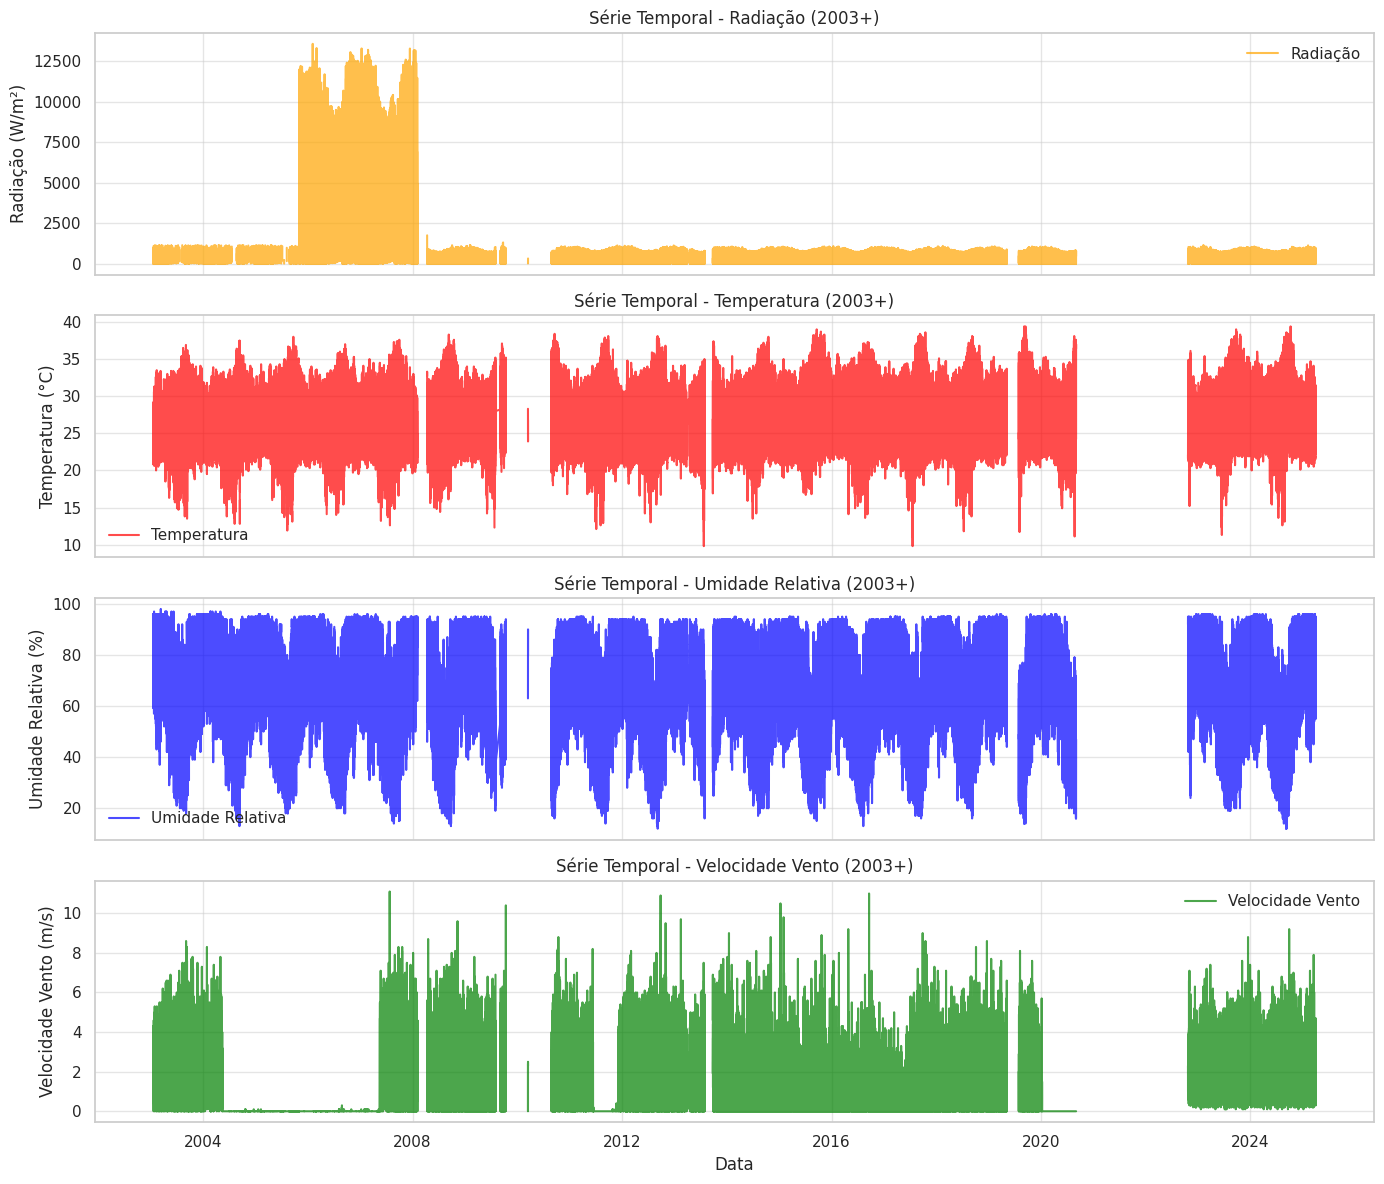


--- Fim do Bloco 4: Análise Exploratória ---

--- Bloco 5: Salvar Resultado Final ---
[OK] Clima consolidado (2002+) salvo em: dados_processados/clima_consolidado.csv

  Informações do DataFrame Climático Salvo:
<class 'pandas.core.frame.DataFrame'>
Index: 161313 entries, 754 to 179435
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   DATA                      161313 non-null  datetime64[ns]
 1   ANO                       161313 non-null  Int64         
 2   MES                       161313 non-null  Int64         
 3   ANO_MES                   161313 non-null  object        
 4   RADIACAO                  77055 non-null   float64       
 5   TEMPERATURA               158464 non-null  float64       
 6   PRECIPITACAO_mm           140848 non-null  float64       
 7   UMIDADE_RELATIVA          158464 non-null  float64       
 8   VENTO_VELOCIDADE          158252 non-null  f

In [3]:
# -*- coding: utf-8 -*-
# Etapa 1: Pré-processamento Clima INMET (Blocos Separados - Diagnóstico Final)

# --- Bloco 1: Configuração Inicial e Upload ---
# Objetivo: Importar bibliotecas, definir pastas, limpar arquivos antigos,
#           fazer upload (se Colab) e listar arquivos a serem processados.

print("--- Bloco 1: Configuração Inicial e Upload (Clima INMET) ---")

# Importar Bibliotecas Essenciais
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns
import sys # Para controle de erro opcional
import shutil # Para remover arquivos/pastas

# Tentar importar do Colab para upload/download
try:
    from google.colab import files
    IN_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    IN_COLAB = False
    print("Executando localmente.")
    # <<< CORREÇÃO DE INDENTAÇÃO AQUI >>>
    class DummyFiles: # Classe para simular 'files' localmente
        def upload(self):
            print("AVISO: upload não disponível localmente.")
            # Simula um upload bem-sucedido para testes locais
            dummy_path = os.path.join('dados_originais', 'sorriso_dummy.csv') # Nome genérico
            if not os.path.exists(dummy_path):
                 os.makedirs('dados_originais', exist_ok=True)
                 with open(dummy_path, 'w', encoding='utf-8') as f:
                      # Cabeçalho mínimo para evitar erros posteriores, ajuste se necessário
                      f.write("DATA_ORIGINAL;HORA_ORIGINAL;PRECIPITACAO_TOTAL_HORARIO(mm);PRESSAO_ATM_NIVEL_ESTACAO_HORARIA(mB);PRESSAO_ATM_MAX_HORA_ANT(mB);PRESSAO_ATM_MIN_HORA_ANT(mB);RADIACAO_GLOBAL(KJ/m²);TEMP_AR_BULBO_SECO_HORARIA(°C);TEMP_PONTO_ORVALHO(°C);TEMP_MAX_HORA_ANT(°C);TEMP_MIN_HORA_ANT(°C);TEMP_ORVALHO_MAX_HORA_ANT(°C);TEMP_ORVALHO_MIN_HORA_ANT(°C);UMID_REL_MAX_HORA_ANT(%);UMID_REL_MIN_HORA_ANT(%);UMID_REL_AR_HORARIA(%);VENTO_DIRECAO_HORARIA(gr);VENTO_RAJADA_MAXIMA(m/s);VENTO_VELOCIDADE_HORARIA(m/s)\n")
                 print(f"       Arquivo dummy '{dummy_path}' criado para execução local.")
            return {} # Simula retorno vazio do Colab

        def download(self, path):
            print(f"AVISO: download não disponível localmente. Arquivo em: {path}")
    files = DummyFiles() # Atribui a instância da classe dummy

# Configurações Gerais de Plotagem
try:
    plt.style.use('seaborn-v0_8-whitegrid')
    print("Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.")
except OSError:
    print("Estilo 'seaborn-v0_8-whitegrid' não encontrado, tentando 'seaborn-whitegrid'...")
    try:
        plt.style.use('seaborn-whitegrid')
        print("Estilo de plotagem 'seaborn-whitegrid' aplicado.")
    except OSError:
        print("Nenhum estilo seaborn encontrado. Usando estilo padrão do Matplotlib.")
sns.set(style="whitegrid")

# Definir Pastas
pasta_dados_originais = 'dados_originais'
pasta_dados_processados = 'dados_processados'
os.makedirs(pasta_dados_originais, exist_ok=True); os.makedirs(pasta_dados_processados, exist_ok=True)
print(f"Diretórios '{pasta_dados_originais}' e '{pasta_dados_processados}' verificados/criados.")
padrao_limpeza = 'sorriso_*.csv'; print(f"\n--- Limpando arquivos '{padrao_limpeza}' antigos de '{pasta_dados_originais}' ---")
arquivos_antigos = glob.glob(os.path.join(pasta_dados_originais, padrao_limpeza))
if arquivos_antigos:
    for f_antigo in arquivos_antigos:
        try: os.remove(f_antigo); print(f"  Removido: {os.path.basename(f_antigo)}")
        except OSError as e: print(f"  Erro ao remover {os.path.basename(f_antigo)}: {e}")
    print("--- Limpeza concluída ---")
else: print(f"--- Nenhum arquivo com padrão '{padrao_limpeza}' encontrado para limpar ---")
if IN_COLAB:
    print("\n--- Upload Arquivos INMET ---"); print(f"Faça o upload dos seus arquivos CSV do INMET (ex: sorriso_YYYY.csv)")
    uploaded_clima = files.upload(); print(f"\nMovendo arquivos carregados para '{pasta_dados_originais}'...")
    for filename in uploaded_clima.keys():
        try: source_path = filename; destination_path = os.path.join(pasta_dados_originais, filename); shutil.move(source_path, destination_path); print(f"  Movido: {filename} -> {pasta_dados_originais}/")
        except Exception as e: print(f"Erro ao mover {filename}: {e}.")
padrao_busca = 'sorriso_*.csv'; clima_brutos_paths = sorted(glob.glob(os.path.join(pasta_dados_originais, padrao_busca)))
print(f"\nArquivos encontrados em '{pasta_dados_originais}' com padrão '{padrao_busca}': {len(clima_brutos_paths)}")
print("\n--- Fim do Bloco 1: Configuração e Upload ---")
# >>> Execute esta célula <<<



# --- Bloco 2: Carregamento e Concatenação ---
# Objetivo: Ler os arquivos CSV listados no bloco anterior e juntá-los
#           em um único DataFrame bruto (df_clima_raw).
print("\n--- Bloco 2: Carregamento e Concatenação (Clima INMET) ---")
dfs_lidos = []
nomes_colunas_inmet = [
    'DATA_ORIGINAL', 'HORA_ORIGINAL', 'PRECIPITACAO_TOTAL_HORARIO(mm)',
    'PRESSAO_ATM_NIVEL_ESTACAO_HORARIA(mB)', 'PRESSAO_ATM_MAX_HORA_ANT(mB)',
    'PRESSAO_ATM_MIN_HORA_ANT(mB)', 'RADIACAO_GLOBAL(KJ/m²)',
    'TEMP_AR_BULBO_SECO_HORARIA(°C)', 'TEMP_PONTO_ORVALHO(°C)',
    'TEMP_MAX_HORA_ANT(°C)', 'TEMP_MIN_HORA_ANT(°C)',
    'TEMP_ORVALHO_MAX_HORA_ANT(°C)', 'TEMP_ORVALHO_MIN_HORA_ANT(°C)',
    'UMID_REL_MAX_HORA_ANT(%)', 'UMID_REL_MIN_HORA_ANT(%)',
    'UMID_REL_AR_HORARIA(%)', 'VENTO_DIRECAO_HORARIA(gr)',
    'VENTO_RAJADA_MAXIMA(m/s)', 'VENTO_VELOCIDADE_HORARIA(m/s)'
]
n_cols_esperadas = len(nomes_colunas_inmet)
print(f"  Esperando {n_cols_esperadas} colunas nos arquivos CSV.")
if 'clima_brutos_paths' not in locals() or not clima_brutos_paths:
    print(f"[ERRO] Nenhum arquivo CSV encontrado ou lista 'clima_brutos_paths' não definida. Execute o Bloco 1.")
    df_clima_raw = None
else:
    for arq in clima_brutos_paths:
        print(f"  Processando: {os.path.basename(arq)}")
        df_temp = None; separador_usado = None; read_success = False
        try:
            try: # Tentativa 1: sep=';', dec=','
                df_temp = pd.read_csv(arq, sep=";", encoding='latin1', skiprows=8, header=None, names=nomes_colunas_inmet, usecols=range(n_cols_esperadas), on_bad_lines='warn', decimal=',')
                if df_temp.shape[1] == n_cols_esperadas: separador_usado = ';'; read_success = True
                else: raise ValueError(f"Cols={df_temp.shape[1]} com sep=';'.")
            except Exception as e1:
                try: # Tentativa 2: sep=',', dec='.'
                    print(f"      Falha com ';'. Tentando sep=','...");
                    df_temp = pd.read_csv(arq, sep=",", encoding='latin1', skiprows=8, header=None, names=nomes_colunas_inmet, usecols=range(n_cols_esperadas), on_bad_lines='warn', decimal='.')
                    if df_temp.shape[1] == n_cols_esperadas: separador_usado = ','; read_success = True; print("      [OK] Lido com sep=','.")
                    else: raise ValueError(f"Cols={df_temp.shape[1]} com sep=','. ")
                except Exception as e2: print(f"    [ERRO] Falha final ao ler {arq}: {e2}. Pulando."); continue
            if read_success and df_temp is not None: dfs_lidos.append(df_temp)
        except Exception as e: print(f"    [ERRO] Falha inesperada ao processar {arq}: {e}")
    if dfs_lidos:
        df_clima_raw = pd.concat(dfs_lidos, ignore_index=True); print(f"\n[OK] Dados brutos concatenados. Total de linhas: {df_clima_raw.shape[0]}")
    else: print("[ERRO] Nenhum arquivo de clima lido com sucesso."); df_clima_raw = None
print("\n--- Fim do Bloco 2: Carregamento e Concatenação ---")
# >>> Execute esta célula APÓS o Bloco 1 <<<



print("\n--- Bloco 3: Processamento Principal (com Diagnóstico Detalhado) ---")

df_clima_proc = None # Inicializa DataFrame processado

# Só executa se a etapa anterior criou df_clima_raw
if 'df_clima_raw' in locals() and isinstance(df_clima_raw, pd.DataFrame):
    df_clima_renomeado = df_clima_raw.copy() # Trabalha em uma cópia

    # --- Renomeação (usando os nomes definidos em nomes_colunas_inmet) ---
    print("  Renomeando colunas para nomes padronizados...")
    rename_map_clima = {
        'DATA_ORIGINAL': 'DATA_STR', 'HORA_ORIGINAL': 'HORA_UTC',
        'PRECIPITACAO_TOTAL_HORARIO(mm)': 'PRECIPITACAO_mm',
        'PRESSAO_ATM_NIVEL_ESTACAO_HORARIA(mB)': 'PRESSAO_ATMO_ESTACAO',
        'PRESSAO_ATM_MAX_HORA_ANT(mB)': 'PRESSAO_ATMO_MAX',
        'PRESSAO_ATM_MIN_HORA_ANT(mB)': 'PRESSAO_ATMO_MIN',
        'RADIACAO_GLOBAL(KJ/m²)': 'RADIACAO_kJ_m2',
        'TEMP_AR_BULBO_SECO_HORARIA(°C)': 'TEMPERATURA_C',
        'TEMP_PONTO_ORVALHO(°C)': 'TEMPERATURA_ORVALHO',
        'TEMP_MAX_HORA_ANT(°C)': 'TEMP_MAX_ANT_C', 'TEMP_MIN_HORA_ANT(°C)': 'TEMP_MIN_ANT_C',
        'TEMP_ORVALHO_MAX_HORA_ANT(°C)': 'TEMP_ORVALHO_MAX', 'TEMP_ORVALHO_MIN_HORA_ANT(°C)': 'TEMP_ORVALHO_MIN',
        'UMID_REL_MAX_HORA_ANT(%)': 'UMID_REL_MAX_ANT_perc', 'UMID_REL_MIN_HORA_ANT(%)': 'UMID_REL_MIN_ANT_perc',
        'UMID_REL_AR_HORARIA(%)': 'UMID_REL_perc', 'VENTO_DIRECAO_HORARIA(gr)': 'VENTO_DIR_graus',
        'VENTO_RAJADA_MAXIMA(m/s)': 'VENTO_RAJADA_MAX_ms', 'VENTO_VELOCIDADE_HORARIA(m/s)': 'VENTO_VEL_ms'
    }
    cols_a_renomear_clima = {k: v for k, v in rename_map_clima.items() if k in df_clima_renomeado.columns}
    df_clima_renomeado.rename(columns=cols_a_renomear_clima, inplace=True)
    print(f"  Colunas renomeadas para nomes internos (exemplo): {list(cols_a_renomear_clima.values())[:7]}...")

    # --- Pré-processamento usando Nomes Internos ---
    print("  Iniciando pré-processamento do clima...")

    # <<< DIAGNÓSTICO DETALHADO ANTES DA CONVERSÃO DE DATA >>>
    print("\n    --- DIAGNÓSTICO PRÉ-CONVERSÃO DATA/HORA ---")
    if 'DATA_STR' in df_clima_renomeado.columns and 'HORA_UTC' in df_clima_renomeado.columns:
        print("    Conteúdo das colunas DATA_STR e HORA_UTC (primeiras 10 linhas):")
        print(df_clima_renomeado[['DATA_STR', 'HORA_UTC']].head(10))
        print("\n    Conteúdo das colunas DATA_STR e HORA_UTC (últimas 10 linhas):")
        print(df_clima_renomeado[['DATA_STR', 'HORA_UTC']].tail(10))
        print("\n    Valores Nulos ANTES da conversão:")
        print(f"      DATA_STR: {df_clima_renomeado['DATA_STR'].isnull().sum()}")
        print(f"      HORA_UTC: {df_clima_renomeado['HORA_UTC'].isnull().sum()}")
        print("\n    Formatos únicos (amostra) em DATA_STR:")
        try: print(df_clima_renomeado['DATA_STR'].astype(str).str.strip().unique()[:20])
        except: print("      Erro ao obter formatos únicos de DATA_STR.")
        print("\n    Formatos únicos (amostra) em HORA_UTC:")
        try: print(df_clima_renomeado['HORA_UTC'].astype(str).str.strip().unique()[:20])
        except: print("      Erro ao obter formatos únicos de HORA_UTC.")
    else:
        print("    [ERRO] Colunas DATA_STR ou HORA_UTC não encontradas para diagnóstico.")
    print("    --------------------------------------------")
    # <<< FIM DO DIAGNÓSTICO DETALHADO >>>

    # Combinar Data e Hora
    try:
        if 'DATA_STR' in df_clima_renomeado.columns and 'HORA_UTC' in df_clima_renomeado.columns:
            # Garante que as colunas são strings e remove espaços extras
            data_str_col = df_clima_renomeado['DATA_STR'].astype(str).str.strip()
            hora_utc_col = df_clima_renomeado['HORA_UTC'].astype(str).str.strip()

            # <<< AJUSTE NA LÓGICA DE CONVERSÃO >>>
            # Tenta o formato DD/MM/YYYY HH:MM:SS primeiro (confirmado para arquivos antigos)
            print("\n    Tentando formato DD/MM/YYYY HH:MM:SS...")
            df_clima_renomeado['DATA'] = pd.to_datetime(data_str_col + ' ' + hora_utc_col,
                                                       format='%d/%m/%Y %H:%M:%S', errors='coerce')

            # Verifica quantas falharam e tenta outros formatos para as linhas que falharam
            mask_failed = df_clima_renomeado['DATA'].isnull()
            if mask_failed.any():
                print(f"    Formato DD/MM/YYYY HH:MM:SS falhou para {mask_failed.sum()} linhas.")
                # Tenta YYYY/MM/DD HH:MM:SS
                print("    Tentando formato YYYY/MM/DD HH:MM:SS...")
                df_clima_renomeado.loc[mask_failed, 'DATA'] = pd.to_datetime(df_clima_renomeado.loc[mask_failed, 'DATA_STR'] + ' ' + df_clima_renomeado.loc[mask_failed, 'HORA_UTC'],
                                                                               format='%Y/%m/%d %H:%M:%S', errors='coerce')
                mask_failed = df_clima_renomeado['DATA'].isnull() # Atualiza a máscara
                if mask_failed.any():
                    print(f"    Formato YYYY/MM/DD HH:MM:SS falhou para {mask_failed.sum()} linhas.")
                    # Tenta DD/MM/YYYY HHMM (formatando a hora)
                    print("    Tentando formato DD/MM/YYYY HHMM...")
                    hora_hhmm = hora_utc_col.str.replace(':', '', regex=False).str.slice(0, 4)
                    df_clima_renomeado.loc[mask_failed, 'DATA'] = pd.to_datetime(df_clima_renomeado.loc[mask_failed, 'DATA_STR'] + ' ' + hora_hhmm[mask_failed],
                                                                                format='%d/%m/%Y %H%M', errors='coerce')
                    mask_failed = df_clima_renomeado['DATA'].isnull() # Atualiza a máscara
                    if mask_failed.any():
                        print(f"    Formato DD/MM/YYYY HHMM falhou para {mask_failed.sum()} linhas.")
                        # Tenta YYYY/MM/DD HHMM
                        print("    Tentando formato YYYY/MM/DD HHMM...")
                        df_clima_renomeado.loc[mask_failed, 'DATA'] = pd.to_datetime(df_clima_renomeado.loc[mask_failed, 'DATA_STR'] + ' ' + hora_hhmm[mask_failed],
                                                                                    format='%Y/%m/%d %H%M', errors='coerce')
                        mask_failed = df_clima_renomeado['DATA'].isnull() # Atualiza a máscara
                        if mask_failed.any():
                             print(f"    [AVISO FINAL] {mask_failed.sum()} linhas não puderam ser convertidas para datetime com os formatos testados.")

            # Remove linhas onde a conversão falhou completamente
            linhas_antes = len(df_clima_renomeado)
            df_clima_renomeado.dropna(subset=['DATA'], inplace=True)
            removidos = linhas_antes - len(df_clima_renomeado)
            if removidos > 0: print(f"    - {removidos} linhas removidas por data/hora inválida final.")
            print("    - Coluna 'DATA' (datetime) criada/atualizada.")
            # <<< VERIFICAÇÃO 1: Após criar DATA >>>
            if not df_clima_renomeado.empty: print(f"    >>> CHECK 1 - Min Data: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}")
            else: print("    >>> CHECK 1 - DataFrame vazio após dropna de DATA.")
        else: raise ValueError("Colunas de Data/Hora não encontradas.")

    except Exception as e_dt:
        print(f"[ERRO CRÍTICO] Falha ao criar coluna DATA datetime: {e_dt}")
        df_clima_renomeado = None

    # Prossegue apenas se a data foi criada com sucesso
    if df_clima_renomeado is not None:
        # --- Filtrar por Ano ---
        ano_inicio_filtro = 2002; linhas_antes_filtro = len(df_clima_renomeado)
        if pd.api.types.is_datetime64_any_dtype(df_clima_renomeado['DATA']):
             df_clima_renomeado = df_clima_renomeado[df_clima_renomeado['DATA'].dt.year >= ano_inicio_filtro].copy()
             removidos_filtro = linhas_antes_filtro - len(df_clima_renomeado)
             if removidos_filtro > 0: print(f"  [FILTRO] Removidas {removidos_filtro} linhas com ano anterior a {ano_inicio_filtro}.")
             print(f"  Dados filtrados a partir de {ano_inicio_filtro}. Linhas restantes: {len(df_clima_renomeado)}")
             if df_clima_renomeado.empty: raise ValueError(f"Nenhum dado encontrado a partir do ano {ano_inicio_filtro}.")
             else: print(f"    >>> CHECK 2 - Min Data: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}")
        else: raise TypeError("Coluna DATA não é datetime. Filtro por ano falhou.")

    # Prossegue apenas se ainda houver dados
    if df_clima_renomeado is not None and not df_clima_renomeado.empty:
        # Criar colunas ANO, MES, ANO_MES
        df_clima_renomeado['ANO'] = df_clima_renomeado['DATA'].dt.year.astype('Int64'); df_clima_renomeado['MES'] = df_clima_renomeado['DATA'].dt.month.astype('Int64'); df_clima_renomeado['ANO_MES'] = df_clima_renomeado['DATA'].dt.strftime('%Y-%m')
        print("    - Colunas 'ANO', 'MES', 'ANO_MES' criadas/atualizadas.")

        # Tratar colunas numéricas principais
        print("    - Convertendo e tratando colunas numéricas principais:")
        colunas_principais = {'RADIACAO_kJ_m2': 'Radiação', 'TEMPERATURA_C': 'Temperatura', 'PRECIPITACAO_mm': 'Precipitação', 'UMID_REL_perc': 'Umidade Relativa', 'VENTO_VEL_ms': 'Velocidade Vento'}
        for col_interno, nome_legivel in colunas_principais.items():
            if col_interno in df_clima_renomeado.columns:
                df_clima_renomeado[col_interno] = pd.to_numeric(df_clima_renomeado[col_interno], errors='coerce')
                df_clima_renomeado[col_interno] = df_clima_renomeado[col_interno].replace(-9999, np.nan)
                if col_interno == 'RADIACAO_kJ_m2':
                     df_clima_renomeado.loc[df_clima_renomeado[col_interno] < 0, col_interno] = np.nan; print("      [AVISO] Convertendo Radiação..."); df_clima_renomeado['RADIACAO'] = df_clima_renomeado[col_interno] / 3.6
                elif col_interno == 'TEMPERATURA_C': df_clima_renomeado['TEMPERATURA'] = df_clima_renomeado[col_interno]
                elif col_interno == 'PRECIPITACAO_mm': df_clima_renomeado.loc[df_clima_renomeado[col_interno] < 0, col_interno] = 0
                elif col_interno == 'UMID_REL_perc': df_clima_renomeado.loc[~df_clima_renomeado[col_interno].between(0, 100), col_interno] = np.nan; df_clima_renomeado['UMIDADE_RELATIVA'] = df_clima_renomeado[col_interno]
                elif col_interno == 'VENTO_VEL_ms': df_clima_renomeado.loc[df_clima_renomeado[col_interno] < 0, col_interno] = np.nan; df_clima_renomeado['VENTO_VELOCIDADE'] = df_clima_renomeado[col_interno]
                print(f"      Coluna '{nome_legivel}' ({col_interno}) tratada.")
            else:
                print(f"      Atenção: Coluna '{nome_legivel}' ({col_interno}) não encontrada."); # Cria coluna padrão com NaN
                if col_interno == 'RADIACAO_kJ_m2': df_clima_renomeado['RADIACAO'] = np.nan
                if col_interno == 'TEMPERATURA_C': df_clima_renomeado['TEMPERATURA'] = np.nan
                if col_interno == 'PRECIPITACAO_mm': df_clima_renomeado['PRECIPITACAO_mm'] = np.nan
                if col_interno == 'UMID_REL_perc': df_clima_renomeado['UMIDADE_RELATIVA'] = np.nan
                if col_interno == 'VENTO_VEL_ms': df_clima_renomeado['VENTO_VELOCIDADE'] = np.nan

        # Calcular médias diárias usando nomes PADRÃO
        colunas_para_media = [c for c in ['RADIACAO', 'TEMPERATURA', 'UMIDADE_RELATIVA', 'VENTO_VELOCIDADE'] if c in df_clima_renomeado.columns]
        if colunas_para_media:
            df_clima_renomeado['date_only'] = df_clima_renomeado['DATA'].dt.date
            daily_averages = df_clima_renomeado.groupby('date_only')[colunas_para_media].mean()
            rename_avg = {'RADIACAO': 'RADIACAO_media_diaria', 'TEMPERATURA': 'TEMPERATURA_media_diaria', 'UMIDADE_RELATIVA': 'UMIDADE_media_diaria', 'VENTO_VELOCIDADE': 'VENTO_VEL_media_diaria'}
            rename_avg_presentes = {k: v for k, v in rename_avg.items() if k in daily_averages.columns}
            daily_averages = daily_averages.rename(columns=rename_avg_presentes)
            df_clima_renomeado = pd.merge(df_clima_renomeado, daily_averages.reset_index(), on='date_only', how='left')
            df_clima_renomeado = df_clima_renomeado.drop(columns=['date_only'])
            print("    - Médias diárias calculadas.")
            colunas_avg_criadas = list(rename_avg_presentes.values())
            # <<< VERIFICAÇÃO 3: ANTES de remover NaNs das médias diárias >>>
            if not df_clima_renomeado.empty: print(f"    >>> CHECK 3 - Min Data ANTES do dropna final: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}"); print(f"        NaNs em médias diárias ({colunas_avg_criadas}): {df_clima_renomeado[colunas_avg_criadas].isnull().sum().to_dict()}")
            else: print("    >>> CHECK 3 - DataFrame vazio ANTES do dropna final.")
            linhas_antes_nan_avg = len(df_clima_renomeado); df_clima_renomeado.dropna(subset=colunas_avg_criadas, inplace=True); removidos_nan_avg = linhas_antes_nan_avg - len(df_clima_renomeado)
            if removidos_nan_avg > 0: print(f"    - {removidos_nan_avg} linhas removidas por NaNs nas médias diárias.")
            # <<< VERIFICAÇÃO 4: DEPOIS de remover NaNs das médias diárias >>>
            if not df_clima_renomeado.empty: print(f"    >>> CHECK 4 - Min Data DEPOIS do dropna final: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}")
            else: print("    >>> CHECK 4 - DataFrame vazio DEPOIS do dropna final.")
        else: print("    - Aviso: Não foi possível calcular médias diárias.")

        df_clima_proc = df_clima_renomeado # Atribui resultado final
        print("[OK] Processamento principal concluído.")

    else:
        print("[ERRO] Processamento interrompido devido a erros anteriores.")

else:
    print("[ERRO] DataFrame bruto 'df_clima_raw' não foi criado na etapa anterior.")

print("\n--- Fim do Bloco 3: Processamento Principal ---")
#



# --- Bloco 4: Análise Exploratória (Opcional) ---
# Objetivo: Visualizar as séries temporais processadas (incluindo Umid/Vento).
print("\n--- Bloco 4: Análise Exploratória (Opcional) ---")
if 'df_clima_proc' in locals() and isinstance(df_clima_proc, pd.DataFrame) and not df_clima_proc.empty:
    print("  Gerando gráficos de série temporal...")
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    plot_ok_count = 0
    plot_vars = {'RADIACAO': ('Radiação (W/m²)', 'orange', axes[0]),
                 'TEMPERATURA': ('Temperatura (°C)', 'red', axes[1]),
                 'UMIDADE_RELATIVA': ('Umidade Relativa (%)', 'blue', axes[2]),
                 'VENTO_VELOCIDADE': ('Velocidade Vento (m/s)', 'green', axes[3])}
    for col, (label, color, ax) in plot_vars.items():
        if col in df_clima_proc.columns and not df_clima_proc[col].isnull().all():
            ax.plot(df_clima_proc['DATA'], df_clima_proc[col], label=label.split('(')[0].strip(), alpha=0.7, color=color)
            ax.set_ylabel(label)
            try: ano_min_plot = df_clima_proc["ANO"].min()
            except: ano_min_plot = "Início"
            ax.set_title(f'Série Temporal - {label.split("(")[0].strip()} ({ano_min_plot}+)')
            ax.grid(True, alpha=0.5); ax.legend()
            plot_ok_count += 1
        else: print(f"    - Aviso: Coluna '{col}' não encontrada ou vazia para plot.")
    if plot_ok_count > 0: axes[-1].set_xlabel('Data'); plt.tight_layout(); plt.show()
    else: print("    - Não foi possível gerar gráficos de série temporal.")
else: print("  DataFrame processado 'df_clima_proc' não disponível ou vazio.")
print("\n--- Fim do Bloco 4: Análise Exploratória ---")
# >>> Execute esta célula APÓS o Bloco 3 <<<



# --- Bloco 5: Salvar Resultado Final ---
# Objetivo: Salvar o DataFrame processado (df_clima_proc) em um arquivo CSV.
print("\n--- Bloco 5: Salvar Resultado Final ---")
if 'df_clima_proc' in locals() and isinstance(df_clima_proc, pd.DataFrame) and not df_clima_proc.empty:
    colunas_finais_clima = [
        'DATA', 'ANO', 'MES', 'ANO_MES',
        'RADIACAO', 'TEMPERATURA', 'PRECIPITACAO_mm', 'UMIDADE_RELATIVA', 'VENTO_VELOCIDADE',
        'RADIACAO_media_diaria', 'TEMPERATURA_media_diaria',
        'UMIDADE_media_diaria', 'VENTO_VEL_media_diaria'
    ]
    colunas_presentes_clima = [col for col in colunas_finais_clima if col in df_clima_proc.columns]
    df_final_clima = df_clima_proc[colunas_presentes_clima].copy()
    caminho_saida = os.path.join(pasta_dados_processados, 'clima_consolidado.csv')
    try:
        df_final_clima.to_csv(caminho_saida, index=False, encoding='utf-8', date_format='%Y-%m-%d %H:%M:%S')
        print(f"[OK] Clima consolidado (2002+) salvo em: {caminho_saida}")
        print("\n  Informações do DataFrame Climático Salvo:")
        df_final_clima.info()
        print("\n  Primeiras linhas do DataFrame Climático Salvo:")
        print(df_final_clima.head())
        if 'DATA' in df_final_clima.columns and pd.api.types.is_datetime64_any_dtype(df_final_clima['DATA']):
            data_minima = df_final_clima['DATA'].min(); data_maxima = df_final_clima['DATA'].max()
            print("\n--- Intervalo de Datas no DataFrame Final ---"); print(f"Data Mínima: {data_minima}"); print(f"Data Máxima: {data_maxima}")
        else: print("\n[AVISO] Não foi possível verificar o intervalo de datas.")
    except Exception as e: print(f"[ERRO] Falha ao salvar o arquivo processado: {e}")
else: print("[ERRO] DataFrame processado 'df_clima_proc' não disponível ou vazio. Nenhum arquivo salvo.")
print("\n--- Fim do Bloco 5: Salvar Resultado ---")
print("\n=== FIM DA ETAPA 1 (Processamento Climático) ===")
# >>> Execute esta célula APÓS o Bloco 3 (e opcionalmente Bloco 4) <<<


# Dados Google Earth

In [55]:
# Acessas as imagens no Google Earth
# Instalar pacotes necessários
!pip install earthengine-api geemap

# Importar bibliotecas
import ee
import geemap
import os
from google.colab import files
import pandas as pd
import time


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.6 MB/s eta 0:00:00


In [115]:
# Autenticar e inicializar o Earth Engine
ee.Authenticate()

# Defina seu projeto GEE
try:
    # Tenta inicializar no projeto específico primeiro
    ee.Initialize(project="pipoca-452815", quiet=True) # <<< SEU PROJETO AQUI
    print("[OK] GEE inicializado no projeto 'pipoca-452815'.")
except Exception as e_proj:
    print(f"[AVISO] Não foi possível inicializar no projeto GEE especificado: {e_proj}.")
    # Se falhar no projeto específico, tenta inicializar sem projeto (usando padrão)
    try:
        ee.Initialize(quiet=True)
        print("[OK] GEE inicializado (usando projeto padrão).")
    except Exception as e_init:
         print(f"[ERRO] Falha geral na inicialização do GEE: {e_init}")
         # Considerar parar a execução se a inicialização falhar

# Definir área de interesse: Sorriso-MT
sorriso = ee.Geometry.Point(-55.71, -12.55).buffer(30000)  # 30km de buffer

# Definir período de uma safra completa
start_date = '2023-10-01'
end_date = '2025-03-31'

# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Definir pasta no Drive
drive_folder = "EarthEngine_Exports_Mensal"  # Nome da pasta para imagens mensais

# Função para calcular o NDVI
def calculate_ndvi(image):
    nir = image.select('B8')
    red = image.select('B4')
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    return image.addBands(ndvi)

# Função para exportar para o Drive (modificada para incluir ano e mês)
def export_monthly_to_drive(image, name_prefix, year, month, region, scale=30):
    month_str = f"{month:02d}"
    file_name = f"{name_prefix}_{year}_{month_str}"
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=file_name,
        folder=drive_folder,
        fileNamePrefix=file_name,
        region=region.getInfo()['coordinates'],
        scale=scale,
        maxPixels=1e9
    )
    task.start()
    print(f"Exportando {file_name} para o Google Drive...")
    return task

# Criar lista de períodos mensais
date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Iterar sobre os meses e exportar as imagens
for date in date_range:
    year = date.year
    month = date.month
    start_month = f'{year}-{month:02d}-01'
    end_month = pd.to_datetime(start_month) + pd.offsets.MonthEnd(0)
    end_month_str = end_month.strftime('%Y-%m-%d')

    # Obter coleção Sentinel-2 para o mês atual
    s2_monthly = ee.ImageCollection('COPERNICUS/S2_SR') \
        .filterDate(start_month, end_month_str) \
        .filterBounds(sorriso) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .select(['B2', 'B3', 'B4', 'B8']) \
        .median()  # Mediana para remover nuvens

    # Calcular NDVI para o mês atual
    ndvi_monthly = s2_monthly.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # Exportar RGB para o mês atual
    export_monthly_to_drive(
        s2_monthly.select(['B4', 'B3', 'B2']).divide(3000).multiply(255).byte(),
        "sorriso_rgb",
        year,
        month,
        sorriso,
        scale=30
    )

    # Exportar NDVI para o mês atual
    export_monthly_to_drive(
        ndvi_monthly,
        "sorriso_ndvi",
        year,
        month,
        sorriso,
        scale=30
    )

print("\nImagens mensais estão sendo exportadas para seu Google Drive.")
print("Este processo pode levar um tempo considerável, dependendo do número de meses e da área.")
print("As imagens estarão na pasta", drive_folder)
print("Você pode verificar o progresso em: https://code.earthengine.google.com/tasks")
print("Quando as tarefas estiverem concluídas, você poderá acessar os arquivos no seu Google Drive")

[AVISO] Não foi possível inicializar no projeto GEE especificado: Initialize() got an unexpected keyword argument 'quiet'.
[ERRO] Falha geral na inicialização do GEE: Initialize() got an unexpected keyword argument 'quiet'
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exportando sorriso_rgb_2023_10 para o Google Drive...
Exportando sorriso_ndvi_2023_10 para o Google Drive...
Exportando sorriso_rgb_2023_11 para o Google Drive...
Exportando sorriso_ndvi_2023_11 para o Google Drive...
Exportando sorriso_rgb_2023_12 para o Google Drive...
Exportando sorriso_ndvi_2023_12 para o Google Drive...
Exportando sorriso_rgb_2024_01 para o Google Drive...
Exportando sorriso_ndvi_2024_01 para o Google Drive...
Exportando sorriso_rgb_2024_02 para o Google Drive...
Exportando sorriso_ndvi_2024_02 para o Google Drive...
Exportando sorriso_rgb_2024_03 para o Google Drive...
Exportando sorriso_ndvi_2024_03 para o Google Dri

In [60]:
# Google Earth - Transformar as imagens em numeros
# Autenticar e inicializar o Earth Engine
ee.Authenticate()
ee.Initialize(project="pipoca-452815")

# Definir região de interesse (Sorriso, Mato Grosso)
sorriso = ee.Geometry.Point([-55.71, -12.55])  # Coordenadas aproximadas

# Definir o período de tempo
start_date = '2002-01-01'
end_date = '2025-03-31'

# Criar uma lista de todos os meses no período
def generate_monthly_dates(start, end):
    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)
    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    # Removed getInfo() call and directly create ee.Date objects
    ee_dates = ee.List(dates.strftime('%Y-%m-%d').tolist()).map(lambda date_str: ee.Date(date_str))
    # Use get('year') and get('month') within a server-side function
    # Corrected to directly create FeatureCollection from the mapped list
    return ee.FeatureCollection(ee_dates.map(lambda date: ee.Feature(None, {'year': ee.Date(date).get('year'), 'month': ee.Date(date).get('month')})))


# Coleção de imagens Landsat (exemplo, escolha a coleção que melhor se adapta à sua necessidade)
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(sorriso) \
    .filterDate(start_date, end_date)

# Função para calcular o NDVI
def calculate_ndvi(image):
    nir = image.select('SR_B5')  # Banda NIR para Landsat 8
    red = image.select('SR_B4')  # Banda Vermelha para Landsat 8
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    return image.addBands(ndvi)

# Aplica a função para calcular o NDVI em toda a coleção
ndvi_collection = landsat.map(calculate_ndvi)

# Função para reduzir a imagem para a média do NDVI na região
def reduce_monthly_ndvi(year_month):
    year = ee.Number(year_month.get('year'))
    month = ee.Number(year_month.get('month'))
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')

    monthly_image = ndvi_collection.filterDate(start, end).mean()

    if monthly_image:
        mean_ndvi = monthly_image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=sorriso,
            scale=30,  # Ajuste a escala conforme a resolução da imagem
            maxPixels=1e9
        ).get('NDVI')
        return ee.Feature(None, {'year': year, 'month': month, 'mean_ndvi': mean_ndvi})
    else:
        return ee.Feature(None, {'year': year, 'month': month, 'mean_ndvi': None})

monthly_dates = generate_monthly_dates(start_date, end_date)

# Mapeamento da função de redução sobre a lista de meses
monthly_ndvi_features = monthly_dates.map(reduce_monthly_ndvi) # Modified: monthly_dates is already a FeatureCollection

# Converter os resultados do Earth Engine para um DataFrame pandas
def ee_to_pandas(data):
    features = data.getInfo()['features']
    dict_list = []
    for f in features:
        dict_list.append(f['properties'])
    return pd.DataFrame(dict_list)

# Obter os resultados e converção para pandas
monthly_ndvi_df = ee_to_pandas(monthly_ndvi_features)

# Calcular média anual de NDVI
annual_ndvi_df = monthly_ndvi_df.groupby('year')['mean_ndvi'].mean().reset_index()
annual_ndvi_df = annual_ndvi_df.rename(columns={'mean_ndvi': 'annual_mean_ndvi'})

# Merge da médiaanual
monthly_ndvi_df = pd.merge(monthly_ndvi_df, annual_ndvi_df, on='year', how='left')


# Imprimit o dataframe resultante
print(monthly_ndvi_df)

# Salvar dados processados
processed_path = os.path.join('dados_processados', 'ndvi_mensalGoogle.csv') # Changed this line to save in 'dados_processados'
monthly_ndvi_df.to_csv(processed_path, index=False)
print(f"DataFrame NDVI mensal Google Earth em: {processed_path}")

EEException: Error in map(ID=9):
Dictionary.get: Dictionary does not contain key: 'NDVI'.

# Etapa 2 – Extração de Informações Relevantes:

*   Definir variáveis-chave a serem utilizadas no modelo, a partir da análise
exploratória dos dados.
*   Analisar a relação entre NDVI e produtividade agrícola, identificando os períodos críticos de crescimento da cultura.
*   Aplicar técnicas de segmentação para destacar áreas específicas de cultivo na imagem de satélite.

--- Iniciando Etapa 2: Consolidação e Análise Focada (Incluindo Umid/Vento) ---
[OK] Arquivos CSV processados (Clima, SatVeg, Milho) carregados.
  Verificando DataFrames carregados:
    - Clima: Carregado (161313 linhas)
      -> Clima Min Data: 2003-01-17 00:00:00, Max Data: 2025-03-31 23:00:00
    - SatVeg: Carregado (576 linhas)
    - Milho: Carregado (52 linhas)

--- Preparando DataFrames para Merge ---
[OK] df_clima preparado.
[OK] df_satveg_mensal preparado.
    >>> CHECK SatVeg - Min Ano: 2000, Max Ano: 2025
[OK] df_prod_anual preparado.
    >>> CHECK Prod - Min Ano: 2002, Max Ano: 2024

--- Realizando Merges para Consolidar (Base Mensal) ---
  * Agregando clima mensalmente...
    -> Clima agregado.
    >>> CHECK Clima Agg - Min Ano: 2003, Max Ano: 2025
  + Merge com SatVeg Mensal realizado.
  + Merge com Produtividade Anual realizado.

[OK] Base Consolidada Mensal criada.
    >>> CHECK Consolidado - Min Ano: 2003, Max Ano: 2025
        Contagem de NaNs por coluna na base consol

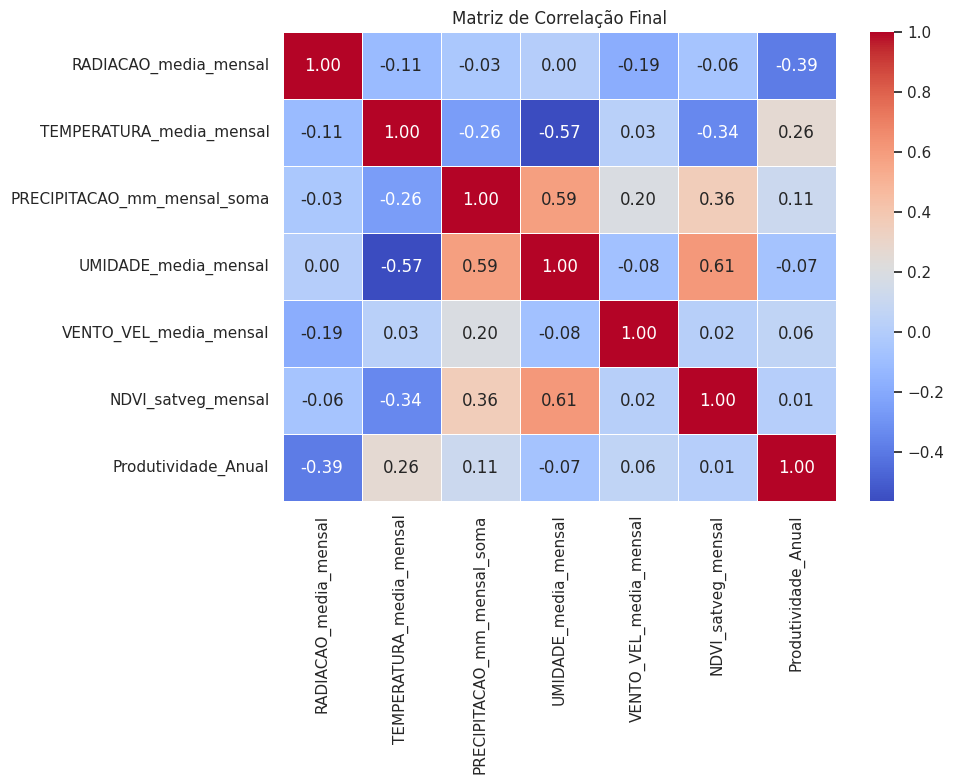

Produtividade_Anual            1.000000
TEMPERATURA_media_mensal       0.263549
PRECIPITACAO_mm_mensal_soma    0.114480
VENTO_VEL_media_mensal         0.061347
NDVI_satveg_mensal             0.009863
UMIDADE_media_mensal          -0.068961
RADIACAO_media_mensal         -0.390487
Name: Produtividade_Anual, dtype: float64

**Variáveis-Chave Sugeridas:**
  - Produtividade_Anual (Alvo)
  - NDVI_satveg_mensal (ou métrica agregada)
  - TEMPERATURA_media_mensal (ou métrica agregada)
  - RADIACAO_media_mensal (ou métrica agregada)
  - PRECIPITACAO_mm_mensal_soma (ou métrica agregada)
  - UMIDADE_media_mensal (ou métrica agregada)
  - VENTO_VEL_media_mensal (ou métrica agregada)
  - ANO (para tendências)

5.2. Relação NDVI-Produtividade e Períodos Críticos...


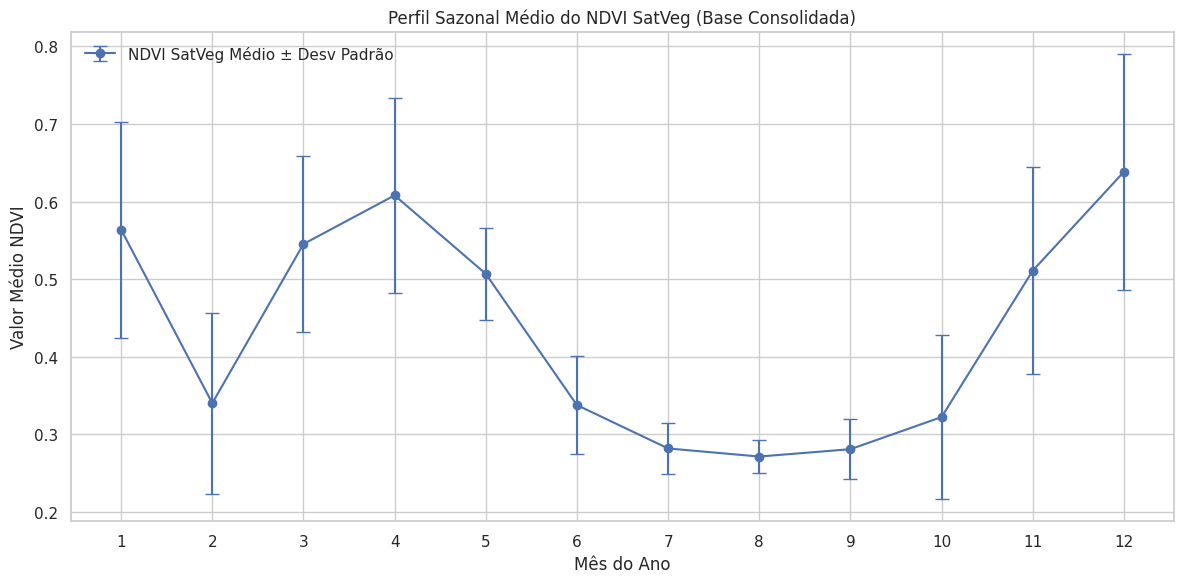

  - Pico médio do NDVI SatVeg ocorre no Mês: 12 (Valor médio: 0.638)
  - Meses próximos a este pico são considerados críticos.


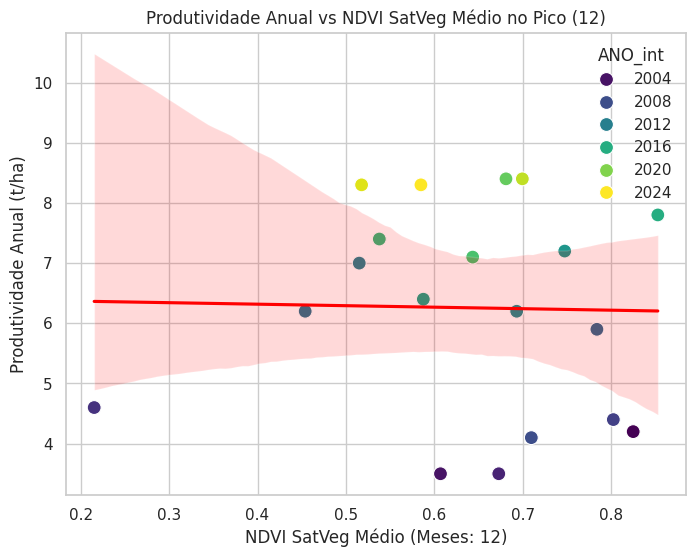


  -> Correlação entre Produtividade Anual e NDVI SatVeg Médio no Pico: -0.022

5.3. Segmentação (Identificação de Fases Fenológicas)...
  A 'segmentação' neste contexto refere-se à identificação das fases de crescimento:
    - Fase 1: Início/Emergência (NDVI subindo)
    - Fase 2: Pico Vegetativo (NDVI máximo)
    - Fase 3: Maturação/Senescência (NDVI caindo)
    - Fase 4: Entressafra/Repouso (NDVI baixo)
  -> Identifique visualmente no gráfico 'Perfil Sazonal Médio do NDVI SatVeg'.
  (Segmentação espacial de imagem não abordada aqui).

--- Fim da Análise Focada ---

=== FIM DA ETAPA 2 ===


In [4]:
# -*- coding: utf-8 -*-
# Etapa 2: Consolidação dos Dados e Extração de Informações Relevantes (Incluindo Umid/Vento e Diagnósticos)

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys # Para controle de erro opcional

print("--- Iniciando Etapa 2: Consolidação e Análise Focada (Incluindo Umid/Vento) ---")

# --- 1. Carregar os Arquivos Processados da Etapa 1 ---
processed_folder = 'dados_processados'
all_files_loaded = True # Flag para verificar se todos os arquivos foram carregados
try:
    df_clima = pd.read_csv(os.path.join(processed_folder, 'clima_consolidado.csv'))
    df_satveg = pd.read_csv(os.path.join(processed_folder, 'satveg_processado.csv'))
    df_milho = pd.read_csv(os.path.join(processed_folder, 'milho.csv'))
    print("[OK] Arquivos CSV processados (Clima, SatVeg, Milho) carregados.")

    print("  Verificando DataFrames carregados:")
    for name, df_check in [('Clima', df_clima), ('SatVeg', df_satveg), ('Milho', df_milho)]:
        if isinstance(df_check, pd.DataFrame) and not df_check.empty:
            print(f"    - {name}: Carregado ({df_check.shape[0]} linhas)")
            # <<< DIAGNÓSTICO: Verificar datas iniciais do Clima >>>
            if name == 'Clima' and 'DATA' in df_check.columns:
                 df_check['DATA'] = pd.to_datetime(df_check['DATA'], errors='coerce') # Garante datetime
                 if not df_check['DATA'].isnull().all():
                      print(f"      -> Clima Min Data: {df_check['DATA'].min()}, Max Data: {df_check['DATA'].max()}")
                 else:
                      print("      -> [AVISO] Coluna DATA do Clima vazia ou inválida após leitura.")
        else:
            print(f"    - [ERRO] {name}: Não carregado ou vazio. Verifique a Etapa 1.")
            all_files_loaded = False

except FileNotFoundError as e:
    print(f"[ERRO CRÍTICO] Arquivo CSV processado não encontrado: {e}.")
    all_files_loaded = False
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar arquivos CSV processados: {e}")
    all_files_loaded = False

# --- 2. Preparar DataFrames para Merge ---
print("\n--- Preparando DataFrames para Merge ---")

# Preparar Clima
try:
    if 'df_clima' in locals() and isinstance(df_clima, pd.DataFrame):
        if 'DATA' in df_clima.columns: df_clima['DATA'] = pd.to_datetime(df_clima['DATA'], errors='coerce')
        if 'ANO' in df_clima.columns: df_clima['ANO'] = pd.to_numeric(df_clima['ANO'], errors='coerce').astype('Int64')
        if 'MES' in df_clima.columns: df_clima['MES'] = pd.to_numeric(df_clima['MES'], errors='coerce').astype('Int64')
        if 'UMIDADE_RELATIVA' in df_clima.columns: df_clima['UMIDADE_RELATIVA'] = pd.to_numeric(df_clima['UMIDADE_RELATIVA'], errors='coerce')
        if 'VENTO_VELOCIDADE' in df_clima.columns: df_clima['VENTO_VELOCIDADE'] = pd.to_numeric(df_clima['VENTO_VELOCIDADE'], errors='coerce')
        if 'PRECIPITACAO_mm' in df_clima.columns: df_clima['PRECIPITACAO_mm'] = pd.to_numeric(df_clima['PRECIPITACAO_mm'], errors='coerce')

        if 'ANO' in df_clima.columns and 'MES' in df_clima.columns: print("[OK] df_clima preparado.")
        else: print("[ERRO] Colunas ANO ou MES ausentes em df_clima."); df_clima = None
    else: print("[ERRO] df_clima não disponível."); df_clima = None
except Exception as e: print(f"[ERRO] Falha ao preparar df_clima: {e}"); df_clima = None

# Preparar SatVeg Mensal
df_satveg_mensal = None
try:
    if 'df_satveg' in locals() and isinstance(df_satveg, pd.DataFrame):
        if 'ANO' in df_satveg.columns and 'MES' in df_satveg.columns and 'NDVI_media_mensal' in df_satveg.columns:
            df_satveg_mensal = df_satveg[['ANO', 'MES', 'NDVI_media_mensal']].copy()
            df_satveg_mensal = df_satveg_mensal.rename(columns={'NDVI_media_mensal': 'NDVI_satveg_mensal'})
            df_satveg_mensal['ANO'] = pd.to_numeric(df_satveg_mensal['ANO'], errors='coerce').astype('Int64')
            df_satveg_mensal['MES'] = pd.to_numeric(df_satveg_mensal['MES'], errors='coerce').astype('Int64')
            df_satveg_mensal['NDVI_satveg_mensal'] = pd.to_numeric(df_satveg_mensal['NDVI_satveg_mensal'], errors='coerce')
            df_satveg_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
            df_satveg_mensal = df_satveg_mensal.drop_duplicates(subset=['ANO', 'MES'], keep='first')
            # <<< DIAGNÓSTICO: Verificar datas SatVeg >>>
            if not df_satveg_mensal.empty:
                 print("[OK] df_satveg_mensal preparado.")
                 print(f"    >>> CHECK SatVeg - Min Ano: {df_satveg_mensal['ANO'].min()}, Max Ano: {df_satveg_mensal['ANO'].max()}")
            else:
                 print("[AVISO] df_satveg_mensal vazio após preparação.")
        else: print("[ERRO] Colunas necessárias não encontradas em df_satveg.")
    else: print("[ERRO] df_satveg não disponível.");
except Exception as e: print(f"[ERRO] Falha ao preparar df_satveg_mensal: {e}"); df_satveg_mensal = None

# Preparar Produtividade Anual
df_prod_anual = None
try:
    if 'df_milho' in locals() and isinstance(df_milho, pd.DataFrame):
        if 'ANO' in df_milho.columns and 'Produtividade_Anual' in df_milho.columns:
            df_prod_anual = df_milho[['ANO', 'Produtividade_Anual']].copy()
            df_prod_anual['ANO'] = pd.to_numeric(df_prod_anual['ANO'], errors='coerce').astype('Int64')
            df_prod_anual['Produtividade_Anual'] = pd.to_numeric(df_prod_anual['Produtividade_Anual'], errors='coerce')
            df_prod_anual.dropna(subset=['ANO', 'Produtividade_Anual'], inplace=True)
            df_prod_anual = df_prod_anual.drop_duplicates(subset=['ANO'], keep='first')
            if not df_prod_anual.empty:
                print("[OK] df_prod_anual preparado.")
                # <<< DIAGNÓSTICO: Verificar datas Produtividade >>>
                print(f"    >>> CHECK Prod - Min Ano: {df_prod_anual['ANO'].min()}, Max Ano: {df_prod_anual['ANO'].max()}")
            else: print("[AVISO] df_prod_anual ficou vazio."); df_prod_anual = None
        else: print("[ERRO] Colunas necessárias não encontradas em df_milho.")
    else: print("[ERRO] df_milho não disponível.");
except Exception as e: print(f"[ERRO] Falha ao preparar df_prod_anual: {e}"); df_prod_anual = None

# --- 3. Realizar Merges para Consolidação (Base Mensal com Novas Vars) ---
print("\n--- Realizando Merges para Consolidar (Base Mensal) ---")
df_consolidado_mensal = None

try:
    if 'df_clima' in locals() and isinstance(df_clima, pd.DataFrame) and 'ANO' in df_clima.columns and 'MES' in df_clima.columns:
        print("  * Agregando clima mensalmente...")
        agg_clima_funcs = {}
        if 'RADIACAO' in df_clima.columns: agg_clima_funcs['RADIACAO_media_mensal'] = ('RADIACAO', 'mean')
        if 'TEMPERATURA' in df_clima.columns: agg_clima_funcs['TEMPERATURA_media_mensal'] = ('TEMPERATURA', 'mean')
        if 'PRECIPITACAO_mm' in df_clima.columns: agg_clima_funcs['PRECIPITACAO_mm_mensal_soma'] = ('PRECIPITACAO_mm', 'sum')
        if 'UMIDADE_RELATIVA' in df_clima.columns: agg_clima_funcs['UMIDADE_media_mensal'] = ('UMIDADE_RELATIVA', 'mean')
        if 'VENTO_VELOCIDADE' in df_clima.columns: agg_clima_funcs['VENTO_VEL_media_mensal'] = ('VENTO_VELOCIDADE', 'mean')

        if agg_clima_funcs:
            df_clima_mensal_agg = df_clima.groupby(['ANO', 'MES']).agg(**agg_clima_funcs).reset_index()
            # <<< DIAGNÓSTICO: Verificar datas Clima Agregado >>>
            if not df_clima_mensal_agg.empty:
                 print("    -> Clima agregado.")
                 print(f"    >>> CHECK Clima Agg - Min Ano: {df_clima_mensal_agg['ANO'].min()}, Max Ano: {df_clima_mensal_agg['ANO'].max()}")
            else:
                 print("    -> [ERRO] Clima agregado resultou vazio.")
                 raise ValueError("Agregação mensal do clima falhou.")

            df_consolidado_mensal = df_clima_mensal_agg.copy()

            # Merge com SatVeg Mensal
            if df_satveg_mensal is not None:
                 df_consolidado_mensal = pd.merge(df_consolidado_mensal, df_satveg_mensal, on=['ANO', 'MES'], how='left')
                 print("  + Merge com SatVeg Mensal realizado.")
            else: print("  - Pular Merge com SatVeg (inválido/ausente).")

            # Merge com Produtividade Anual
            if df_prod_anual is not None:
                 df_consolidado_mensal = pd.merge(df_consolidado_mensal, df_prod_anual, on='ANO', how='left')
                 print("  + Merge com Produtividade Anual realizado.")
            else: print("  - Pular Merge com Produtividade (inválido/ausente).")

            df_consolidado_mensal = df_consolidado_mensal.sort_values(by=['ANO', 'MES']).reset_index(drop=True)

            print("\n[OK] Base Consolidada Mensal criada.")
            # <<< DIAGNÓSTICO: Verificar datas Base Consolidada e NaNs >>>
            if not df_consolidado_mensal.empty:
                 print(f"    >>> CHECK Consolidado - Min Ano: {df_consolidado_mensal['ANO'].min()}, Max Ano: {df_consolidado_mensal['ANO'].max()}")
                 print("        Contagem de NaNs por coluna na base consolidada (antes do dropna da análise):")
                 print(df_consolidado_mensal.isnull().sum())
                 # Verifica NaNs no NDVI SatVeg para anos específicos
                 if 'NDVI_satveg_mensal' in df_consolidado_mensal.columns:
                      nan_ndvi_2002_2018 = df_consolidado_mensal.loc[df_consolidado_mensal['ANO'] < 2019, 'NDVI_satveg_mensal'].isnull().sum()
                      total_2002_2018 = len(df_consolidado_mensal.loc[df_consolidado_mensal['ANO'] < 2019])
                      print(f"        NaNs em NDVI_satveg_mensal (Anos < 2019): {nan_ndvi_2002_2018} / {total_2002_2018}")
            else:
                 print("    >>> CHECK Consolidado - DataFrame vazio.")

            print("\n[INFO] DataFrame Consolidado Mensal - Estrutura:")
            df_consolidado_mensal.info()
            print("\n[INFO] Primeiras linhas do DataFrame Consolidado Mensal:")
            print(df_consolidado_mensal.head())
        else:
            print("[ERRO] Nenhuma coluna climática encontrada para agregação mensal.")
    else:
        print("[ERRO] df_clima inválido ou sem colunas ANO/MES. Base mensal não pode ser criada.")

except Exception as e:
    print(f"[ERRO CRÍTICO] Falha durante a agregação ou merge mensal: {e}")
    df_consolidado_mensal = None

# --- 4. Salvar a Base Consolidada Mensal ---
# (Código de salvar permanece o mesmo)
print("\n--- Salvando Base Consolidada Mensal ---")
output_filename_mensal = 'base_consolidada_mensal.csv'
output_path_mensal = os.path.join(processed_folder, output_filename_mensal)
if 'df_consolidado_mensal' in locals() and isinstance(df_consolidado_mensal, pd.DataFrame) and not df_consolidado_mensal.empty:
    try:
        df_consolidado_mensal.to_csv(output_path_mensal, index=False, encoding='utf-8')
        print(f"[OK] Base consolidada MENSAL salva em: {output_path_mensal}")
    except Exception as e: print(f"[ERRO] Falha ao salvar base consolidada mensal: {e}")
else: print(f"[AVISO] df_consolidado_mensal não definido ou vazio. Arquivo '{output_filename_mensal}' não salvo.")


# --- 5. Análise Focada para Responder Perguntas da Etapa 2 ---
print("\n--- Respondendo Perguntas da Etapa 2 (Análise da Base Consolidada Mensal) ---")

if 'df_consolidado_mensal' not in locals() or not isinstance(df_consolidado_mensal, pd.DataFrame) or df_consolidado_mensal.empty:
    print("[ERRO] DataFrame 'df_consolidado_mensal' não está disponível ou está vazio. Análise da Etapa 2 não pode continuar.")
else:
    print("[INFO] Iniciando análise com 'df_consolidado_mensal'.")
    # --- 5.1. Definir Variáveis-Chave ---
    print("\n5.1. Identificando Variáveis-Chave...")
    colunas_corr_prod = [
        'RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'PRECIPITACAO_mm_mensal_soma',
        'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal',
        'NDVI_satveg_mensal',
        'Produtividade_Anual'
    ]
    colunas_corr_existentes = [col for col in colunas_corr_prod if col in df_consolidado_mensal.columns]

    if len(colunas_corr_existentes) > 1:
        # <<< DIAGNÓSTICO: Verificar antes e depois do dropna para correlação >>>
        print(f"    Colunas consideradas para correlação: {colunas_corr_existentes}")
        print(f"    Shape ANTES do dropna para correlação: {df_consolidado_mensal[colunas_corr_existentes].shape}")
        df_corr = df_consolidado_mensal[colunas_corr_existentes].dropna()
        print(f"    Shape DEPOIS do dropna para correlação: {df_corr.shape}")
        if not df_corr.empty and len(df_corr) > 1:
             # <<< DIAGNÓSTICO: Verificar datas APÓS dropna para correlação >>>
             anos_corr = df_consolidado_mensal.loc[df_corr.index, 'ANO'].unique()
             print(f"    Anos restantes para correlação: Min={anos_corr.min()}, Max={anos_corr.max()}")
             matriz_corr_final = df_corr.corr()
             plt.figure(figsize=(10, 8)); sns.heatmap(matriz_corr_final, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
             plt.title('Matriz de Correlação Final'); plt.tight_layout(); plt.show()
             if 'Produtividade_Anual' in matriz_corr_final.columns: print(matriz_corr_final['Produtividade_Anual'].sort_values(ascending=False))
             else: print("  -> Coluna 'Produtividade_Anual' não encontrada na matriz.")
        else: print("[AVISO] Não há dados suficientes após remover NaNs para calcular a matriz de correlação.")
    else: print("[AVISO] Não há colunas suficientes ou válidas para calcular a matriz de correlação final.")

    print("\n**Variáveis-Chave Sugeridas:**")
    print("  - Produtividade_Anual (Alvo)")
    print("  - NDVI_satveg_mensal (ou métrica agregada)")
    print("  - TEMPERATURA_media_mensal (ou métrica agregada)")
    print("  - RADIACAO_media_mensal (ou métrica agregada)")
    print("  - PRECIPITACAO_mm_mensal_soma (ou métrica agregada)")
    print("  - UMIDADE_media_mensal (ou métrica agregada)")
    print("  - VENTO_VEL_media_mensal (ou métrica agregada)")
    print("  - ANO (para tendências)")

    # --- Explicação sobre R² = NaN na Validação Cruzada Temporal ---
# A métrica R² (R-quadrado) requer pelo menos duas amostras no conjunto de teste
# para calcular a variância necessária em sua fórmula.
# Na validação cruzada temporal realizada aqui (TimeSeriesSplit com poucos anos),
# cada 'fold' de teste continha apenas UM ano (uma única amostra).
# Com apenas uma amostra, a variância é indefinida, tornando o cálculo do R²
# matematicamente impossível, resultando em 'NaN'.
# O Scikit-learn emite um 'UndefinedMetricWarning' para alertar sobre isso.
# Portanto, para esta validação específica, focamos nas métricas RMSE e MAE,
# que podem ser calculadas mesmo com uma única amostra de teste por fold.

    # --- 5.2. Relação NDVI-Produtividade e Períodos Críticos ---
    # (Código desta seção permanece o mesmo)
    print("\n5.2. Relação NDVI-Produtividade e Períodos Críticos...")
    mes_pico = None
    try:
        ndvi_col_perfil = 'NDVI_satveg_mensal'
        if 'MES' in df_consolidado_mensal.columns and ndvi_col_perfil in df_consolidado_mensal.columns:
            df_perfil = df_consolidado_mensal.dropna(subset=['MES', ndvi_col_perfil], how='any')
            if not df_perfil.empty:
                 perfil_ndvi_medio_final = df_perfil.groupby('MES').agg(NDVI_medio=(ndvi_col_perfil, 'mean'), NDVI_std=(ndvi_col_perfil, 'std'))
                 if not perfil_ndvi_medio_final.empty:
                      plt.figure(figsize=(12, 6))
                      plt.errorbar(perfil_ndvi_medio_final.index, perfil_ndvi_medio_final['NDVI_medio'],
                                   yerr=perfil_ndvi_medio_final.get('NDVI_std'), label='NDVI SatVeg Médio ± Desv Padrão', fmt='-o', capsize=5)
                      plt.title('Perfil Sazonal Médio do NDVI SatVeg (Base Consolidada)')
                      plt.xlabel('Mês do Ano'); plt.ylabel('Valor Médio NDVI')
                      plt.xticks(range(1, 13)); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
                      if not perfil_ndvi_medio_final['NDVI_medio'].isnull().all():
                          mes_pico = perfil_ndvi_medio_final['NDVI_medio'].idxmax()
                          valor_pico = perfil_ndvi_medio_final['NDVI_medio'].max()
                          print(f"  - Pico médio do NDVI SatVeg ocorre no Mês: {mes_pico} (Valor médio: {valor_pico:.3f})")
                          print("  - Meses próximos a este pico são considerados críticos.")
                      else: print("  - Não foi possível calcular o pico do NDVI SatVeg.")
                 else: print("[AVISO] Não foi possível calcular o perfil NDVI SatVeg médio.")
            else: print("[AVISO] Não foi possível calcular o perfil NDVI SatVeg médio.")
        else: print("[AVISO] Não foi possível calcular o perfil NDVI SatVeg médio.")
    except Exception as e: print(f"[ERRO] Falha ao gerar gráfico de perfil sazonal: {e}")

    # Relação Produtividade vs NDVI SatVeg no pico
    if mes_pico is not None and 'Produtividade_Anual' in df_consolidado_mensal.columns and 'NDVI_satveg_mensal' in df_consolidado_mensal.columns:
        try:
            meses_pico = [mes_pico]
            df_anual_pico = df_consolidado_mensal[df_consolidado_mensal['MES'].isin(meses_pico)].groupby('ANO').agg(
                NDVI_pico_medio = ('NDVI_satveg_mensal', 'mean'),
                Produtividade_Anual = ('Produtividade_Anual', 'first')
            ).dropna()
            if not df_anual_pico.empty and len(df_anual_pico) > 1:
                df_anual_pico['ANO_int'] = df_anual_pico.index.astype(int)
                plt.figure(figsize=(8, 6))
                sns.scatterplot(data=df_anual_pico, x='NDVI_pico_medio', y='Produtividade_Anual', hue='ANO_int', palette='viridis', s=100)
                sns.regplot(data=df_anual_pico, x='NDVI_pico_medio', y='Produtividade_Anual', scatter=False, color='red')
                plt.title(f'Produtividade Anual vs NDVI SatVeg Médio no Pico ({",".join(map(str, meses_pico))})')
                plt.xlabel(f'NDVI SatVeg Médio (Meses: {",".join(map(str, meses_pico))})')
                plt.ylabel('Produtividade Anual (t/ha)')
                plt.grid(True); plt.show()
                if df_anual_pico['NDVI_pico_medio'].nunique() > 1 and df_anual_pico['Produtividade_Anual'].nunique() > 1:
                    correlacao_pico = df_anual_pico['NDVI_pico_medio'].corr(df_anual_pico['Produtividade_Anual'])
                    print(f"\n  -> Correlação entre Produtividade Anual e NDVI SatVeg Médio no Pico: {correlacao_pico:.3f}")
                else: print("\n  -> Não foi possível calcular a correlação.")
            else: print("[AVISO] Não foi possível gerar o gráfico Produtividade vs NDVI SatVeg no pico.")
        except Exception as e: print(f"[ERRO] Falha ao analisar relação Produtividade vs NDVI SatVeg no pico: {e}")
    elif mes_pico is None: print("[AVISO] Mês de pico não identificado.")
    else: print("[AVISO] Colunas necessárias não encontradas para análise Produtividade vs NDVI SatVeg.")

    # --- 5.3. Segmentação (Identificação de Fases Fenológicas) ---
    # (Código desta seção permanece o mesmo)
    print("\n5.3. Segmentação (Identificação de Fases Fenológicas)...")
    print("  A 'segmentação' neste contexto refere-se à identificação das fases de crescimento:")
    print("    - Fase 1: Início/Emergência (NDVI subindo)")
    print("    - Fase 2: Pico Vegetativo (NDVI máximo)")
    print("    - Fase 3: Maturação/Senescência (NDVI caindo)")
    print("    - Fase 4: Entressafra/Repouso (NDVI baixo)")
    print("  -> Identifique visualmente no gráfico 'Perfil Sazonal Médio do NDVI SatVeg'.")
    print("  (Segmentação espacial de imagem não abordada aqui).")

print("\n--- Fim da Análise Focada ---")
print("\n=== FIM DA ETAPA 2 ===")


In [ ]:
# Aplicar técnicas de segmentação para destacar áreas específicas de cultivo na imagem de satélite.

# Etapa 3 – Construção do Modelo de IA 🤖

*   Selecionar um modelo de aprendizado de máquina ou redes neurais para previsão da produtividade.
*   Treinar o modelo utilizando os dados históricos e validar sua capacidade preditiva.
*   Ajustar hiperparâmetros e otimizar o desempenho do modelo.






--- Iniciando Etapa 3: Construção do Modelo (Linear/Ridge, Dados 2003+) ---
[OK] Base consolidada mensal carregada de: dados_processados/base_consolidada_mensal.csv
     Intervalo de Anos Carregado: 2003 - 2025

--- Agregando Features Mensais Anualmente (Modo Simplificado) ---
[OK] Agregação anual simplificada concluída.
     Dimensões da base anual: (21, 8)
     Colunas disponíveis: ['RADIACAO_media_mensal_mean', 'TEMPERATURA_media_mensal_mean', 'PRECIPITACAO_mm_mensal_soma_mean', 'UMIDADE_media_mensal_mean', 'VENTO_VEL_media_mensal_mean', 'NDVI_satveg_mensal_mean', 'NDVI_satveg_mensal_max', 'Produtividade_Anual']

--- Selecionando Features e Target ---
[OK] Target: 'Produtividade_Anual' (21 amostras)
[OK] Features: 7 colunas (21 amostras)
     Nomes das Features: ['RADIACAO_media_mensal_mean', 'TEMPERATURA_media_mensal_mean', 'PRECIPITACAO_mm_mensal_soma_mean', 'UMIDADE_media_mensal_mean', 'VENTO_VEL_media_mensal_mean', 'NDVI_satveg_mensal_mean', 'NDVI_satveg_mensal_max']

--- Implem

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


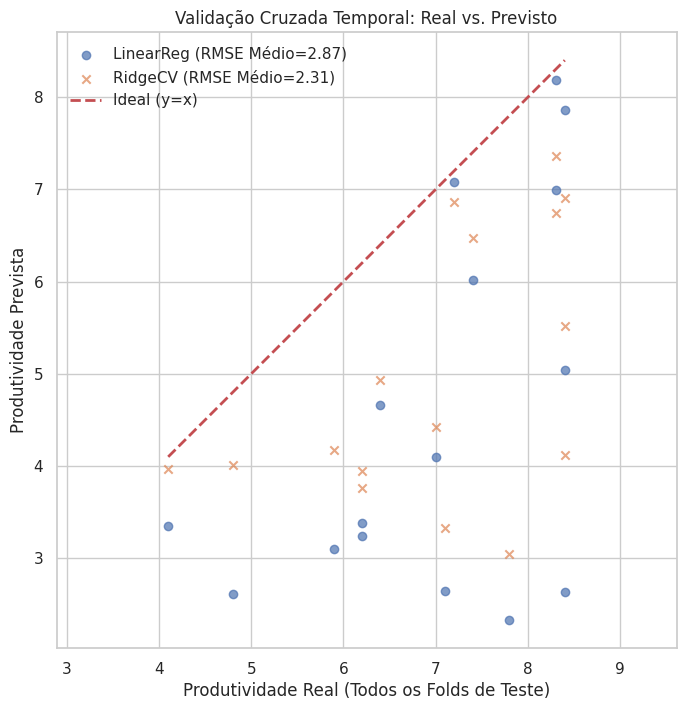


--- Treinamento do Modelo Final (Opcional) ---
  Treinando modelo RidgeCV final com todos os dados...
  Modelo Ridge final treinado com alpha=10.00
[ERRO] Falha ao treinar ou salvar o modelo final: name 'joblib' is not defined

--- Fim da Etapa 3 (Refinada com Features Críticas e Modelos Lineares) ---


In [5]:
__# Etapa 3: Construção do Modelo de IA (Linear/Ridge, Dados 2003+)

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
# import joblib # Não carregaremos modelo RF
from sklearn.model_selection import TimeSeriesSplit, LeaveOneOut # Opções de Validação Cruzada
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV # Modelos Lineares
from sklearn.preprocessing import StandardScaler # Para escalonar features
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 3: Construção do Modelo (Linear/Ridge, Dados 2003+) ---")

# --- 1. Carregar Dados Consolidados Mensais ---
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')

df_mensal = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    print(f"[OK] Base consolidada mensal carregada de: {consolidated_monthly_path}")
    if 'ANO' in df_mensal.columns:
        df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada.")
    if 'MES' in df_mensal.columns:
        df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    df_mensal = df_mensal.sort_values(by=['ANO', 'MES'])
    # Verifica o intervalo de anos carregado
    if not df_mensal.empty:
        print(f"     Intervalo de Anos Carregado: {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    else:
        raise ValueError("DataFrame mensal vazio após carregamento/limpeza inicial.")

except FileNotFoundError:
    print(f"[ERRO CRÍTICO] Arquivo '{consolidated_monthly_path}' não encontrado.")
    # sys.exit()
except ValueError as ve:
     print(f"[ERRO CRÍTICO] Problema ao processar colunas ANO/MES: {ve}")
     # sys.exit()
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar ou processar a base consolidada mensal: {e}")
    # sys.exit()

# --- 2. Engenharia de Atributos (Agregação Anual Simplificada) ---
print("\n--- Agregando Features Mensais Anualmente (Modo Simplificado) ---")
df_anual = None

if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame) and not df_mensal.empty:
    # Define as agregações ANUAIS simplificadas
    aggregations_anual_simplificada = {
        # Usar a MÉDIA ANUAL das médias mensais/somas
        'RADIACAO_media_mensal': ['mean'],
        'TEMPERATURA_media_mensal': ['mean'],
        'PRECIPITACAO_mm_mensal_soma': ['mean'], # Média das somas mensais = Precipitação média mensal no ano
        'UMIDADE_media_mensal': ['mean'],
        'VENTO_VEL_media_mensal': ['mean'],
        'NDVI_satveg_mensal': ['mean', 'max'], # Média e Máximo anual do NDVI SatVeg
        'Produtividade_Anual': ['first'] # Alvo
    }
    agg_funcs_existentes = {col: funcs for col, funcs in aggregations_anual_simplificada.items() if col in df_mensal.columns}

    if agg_funcs_existentes:
        try:
            df_anual = df_mensal.groupby('ANO', observed=False).agg(agg_funcs_existentes)
            df_anual.columns = ['_'.join(col).strip() for col in df_anual.columns.values]
            target_col_agg = 'Produtividade_Anual_first'
            if target_col_agg in df_anual.columns:
                df_anual = df_anual.rename(columns={target_col_agg: 'Produtividade_Anual'})
            else: raise ValueError("Coluna alvo não encontrada após agregação anual.")
            df_anual.dropna(subset=['Produtividade_Anual'], inplace=True)
            df_anual.dropna(axis=1, how='all', inplace=True)
            df_anual = df_anual.sort_index()

            if df_anual.empty: raise ValueError("DataFrame anual vazio após agregação/limpeza.")

            print("[OK] Agregação anual simplificada concluída.")
            print(f"     Dimensões da base anual: {df_anual.shape}")
            print("     Colunas disponíveis:", df_anual.columns.tolist())

        except Exception as e_agg:
             print(f"[ERRO] Falha durante a agregação anual simplificada: {e_agg}")
             df_anual = None
    else:
        print("[ERRO] Nenhuma coluna válida encontrada para realizar a agregação anual.")
        df_anual = None
else:
    print("[ERRO] DataFrame mensal ('df_mensal') não está definido ou vazio.")
    df_anual = None

# --- 3. Seleção de Atributos (Features) e Alvo (Target) ---
print("\n--- Selecionando Features e Target ---")
if 'df_anual' in locals() and isinstance(df_anual, pd.DataFrame) and 'Produtividade_Anual' in df_anual.columns:
    target = 'Produtividade_Anual'
    y = df_anual[target]
    # Seleciona TODAS as colunas agregadas como features (exceto o alvo)
    features_cols = [col for col in df_anual.columns if col != target]
    # Adiciona ANO como feature explícita (se não for o índice)
    # if 'ANO' not in features_cols and df_anual.index.name == 'ANO':
    #      X = df_anual[features_cols].reset_index() # Traz ANO para coluna
    #      features_cols.insert(0, 'ANO') # Adiciona ANO à lista de features
    # else:
    #      X = df_anual[features_cols]
    X = df_anual[features_cols] # Assume que ANO é o índice por enquanto

    # Preenchimento de NaNs nas features (com média)
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features com a média da coluna...")
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         X.fillna(means, inplace=True)
         if X.isnull().any().any():
              cols_com_nan_final = X.columns[X.isnull().any()].tolist()
              print(f"  [ERRO] NaNs persistentes nas features após preenchimento: {cols_com_nan_final}.")
              X = None # Invalida

    if X is not None:
         print(f"[OK] Target: '{target}' ({len(y)} amostras)")
         print(f"[OK] Features: {len(features_cols)} colunas ({X.shape[0]} amostras)")
         print("     Nomes das Features:", features_cols)
else:
    print("[ERRO] DataFrame anual ('df_anual') ou coluna 'Produtividade_Anual' não disponíveis.")
    X, y = None, None

# --- 4. Validação Cruzada Temporal com Modelos Lineares ---
print("\n--- Implementando Validação Cruzada Temporal (Modelos Lineares) ---")

if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")

        fold_metrics_lr = {'r2': [], 'rmse': [], 'mae': []}
        fold_metrics_ridge = {'r2': [], 'rmse': [], 'mae': []}
        fold_counter = 0

        # Listas para armazenar previsões de cada fold para análise posterior
        all_y_test_ts = []
        all_y_pred_lr = []
        all_y_pred_ridge = []

        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]
            anos_treino = X_train_ts.index.tolist(); anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                # Escalonamento
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_ts)
                X_test_scaled = scaler.transform(X_test_ts)
                print("    Features escalonadas.")

                # Regressão Linear
                lr_model = LinearRegression()
                lr_model.fit(X_train_scaled, y_train_ts)
                y_pred_lr = lr_model.predict(X_test_scaled)
                r2_lr = r2_score(y_test_ts, y_pred_lr) if len(y_test_ts) > 1 else np.nan # R2 só com >1 ponto
                rmse_lr = np.sqrt(mean_squared_error(y_test_ts, y_pred_lr))
                mae_lr = mean_absolute_error(y_test_ts, y_pred_lr)
                fold_metrics_lr['r2'].append(r2_lr); fold_metrics_lr['rmse'].append(rmse_lr); fold_metrics_lr['mae'].append(mae_lr)
                print(f"      LR - Métricas: R²={r2_lr:.4f}, RMSE={rmse_lr:.4f}, MAE={mae_lr:.4f}")

                # Regressão Ridge (com busca de alpha ótimo via RidgeCV)
                alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0] # Valores de alpha para testar
                # RidgeCV usa validação cruzada interna para achar o melhor alpha
                ridge_cv_model = RidgeCV(alphas=alphas_to_test, store_cv_values=True)
                ridge_cv_model.fit(X_train_scaled, y_train_ts)
                best_alpha = ridge_cv_model.alpha_
                print(f"    Melhor Alpha para Ridge (Fold {fold_counter}): {best_alpha:.2f}")
                y_pred_ridge = ridge_cv_model.predict(X_test_scaled)
                r2_ridge = r2_score(y_test_ts, y_pred_ridge) if len(y_test_ts) > 1 else np.nan
                rmse_ridge = np.sqrt(mean_squared_error(y_test_ts, y_pred_ridge))
                mae_ridge = mean_absolute_error(y_test_ts, y_pred_ridge)
                fold_metrics_ridge['r2'].append(r2_ridge); fold_metrics_ridge['rmse'].append(rmse_ridge); fold_metrics_ridge['mae'].append(mae_ridge)
                print(f"      RidgeCV - Métricas: R²={r2_ridge:.4f}, RMSE={rmse_ridge:.4f}, MAE={mae_ridge:.4f}")

                # Armazenar resultados para plot final
                all_y_test_ts.extend(y_test_ts.tolist())
                all_y_pred_lr.extend(y_pred_lr.tolist())
                all_y_pred_ridge.extend(y_pred_ridge.tolist())

            except Exception as e_fold:
                print(f"    [ERRO] Falha ao treinar/avaliar o Fold {fold_counter}: {e_fold}")
                for metrics_dict in [fold_metrics_lr, fold_metrics_ridge]:
                    metrics_dict['r2'].append(np.nan); metrics_dict['rmse'].append(np.nan); metrics_dict['mae'].append(np.nan)

        # --- Resultados Consolidados da Validação Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal ---")
        print("\n    Modelo: Regressão Linear")
        if fold_metrics_lr['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_lr['r2']):.4f} ± {np.nanstd(fold_metrics_lr['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_lr['rmse']):.4f} ± {np.nanstd(fold_metrics_lr['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_lr['mae']):.4f} ± {np.nanstd(fold_metrics_lr['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        print("\n    Modelo: Regressão Ridge (com CV para Alpha)")
        if fold_metrics_ridge['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_ridge['r2']):.4f} ± {np.nanstd(fold_metrics_ridge['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_ridge['rmse']):.4f} ± {np.nanstd(fold_metrics_ridge['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_ridge['mae']):.4f} ± {np.nanstd(fold_metrics_ridge['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        # --- Plot Consolidado: Real vs Previsto (Todos os Folds) ---
        print("\n  --- Gráfico Consolidado: Real vs. Previsto (Todos os Folds) ---")
        if all_y_test_ts: # Verifica se há previsões para plotar
             plt.figure(figsize=(8, 8))
             plt.scatter(all_y_test_ts, all_y_pred_lr, alpha=0.7, label=f'LinearReg (RMSE Médio={np.nanmean(fold_metrics_lr["rmse"]):.2f})')
             plt.scatter(all_y_test_ts, all_y_pred_ridge, alpha=0.7, label=f'RidgeCV (RMSE Médio={np.nanmean(fold_metrics_ridge["rmse"]):.2f})', marker='x')
             # Linha ideal y=x
             min_val = min(all_y_test_ts); max_val = max(all_y_test_ts)
             plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
             plt.xlabel('Produtividade Real (Todos os Folds de Teste)')
             plt.ylabel('Produtividade Prevista')
             plt.title('Validação Cruzada Temporal: Real vs. Previsto')
             plt.legend()
             plt.grid(True)
             plt.axis('equal')
             plt.show()
        else:
             print("    Nenhuma previsão válida gerada para o gráfico consolidado.")

    # Mensagens caso não seja possível executar a validação cruzada
    elif n_anos <= 1: print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit.")
    else: print(f"[AVISO] Número de splits ({n_splits_ts}) inválido. Validação não executada.")
else:
    print("[ERRO] Dados anuais (X, y) não disponíveis para Validação Cruzada Temporal.")

# --- 5. Treinar Modelo Final e Salvar (Opcional) ---
# Após avaliar, você pode treinar o melhor modelo (ex: Ridge) com TODOS os dados
# e salvá-lo para uso futuro.
print("\n--- Treinamento do Modelo Final (Opcional) ---")
final_model = None
if X is not None and y is not None:
     try:
          print("  Treinando modelo RidgeCV final com todos os dados...")
          # Escalonar TODOS os dados X
          final_scaler = StandardScaler()
          X_scaled_final = final_scaler.fit_transform(X)
          # Treinar RidgeCV com todos os dados escalonados
          final_ridge_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
          final_ridge_model.fit(X_scaled_final, y)
          final_model = final_ridge_model # Guarda o modelo final
          print(f"  Modelo Ridge final treinado com alpha={final_model.alpha_:.2f}")

          # Salvar o modelo final e o scaler
          model_folder = os.path.join('resultados', 'modelos')
          os.makedirs(model_folder, exist_ok=True)
          model_path_final = os.path.join(model_folder, 'modelo_final_ridge.joblib')
          scaler_path_final = os.path.join(model_folder, 'scaler_final.joblib')
          joblib.dump(final_model, model_path_final)
          joblib.dump(final_scaler, scaler_path_final)
          print(f"  Modelo final salvo em: {model_path_final}")
          print(f"  Scaler final salvo em: {scaler_path_final}")

          # Exibir coeficientes do modelo final
          if hasattr(final_model, 'coef_') and hasattr(X, 'columns'):
               print("\n  Coeficientes do Modelo Ridge Final:")
               coefs = pd.Series(final_model.coef_, index=X.columns).sort_values(ascending=False)
               print(coefs)
               print("  -> Coeficientes indicam a relação (positiva/negativa) e a 'força'")
               print("     de cada feature na previsão, APÓS escalonamento.")

     except Exception as e_final:
          print(f"[ERRO] Falha ao treinar ou salvar o modelo final: {e_final}")
else:
     print("  Dados (X, y) não disponíveis para treinar modelo final.")


print("\n--- Fim da Etapa 3 (Refinada com Features Críticas e Modelos Lineares) ---")


--- Iniciando Etapa 3: Construção do Modelo (Features de Período Crítico) ---
[OK] Base consolidada mensal carregada de: dados_processados/base_consolidada_mensal.csv
     Intervalo de Anos Carregado: 2003 - 2025

--- Agregando Features do Período Crítico Anualmente ---
  Meses definidos como críticos: [2, 3, 4]
  Dados filtrados para os meses críticos. Linhas restantes: 59
[OK] Agregação anual focada no período crítico concluída.
     Dimensões da base anual crítica: (20, 10)
     Primeiras linhas da base anual crítica:
      RADIACAO_media_mensal_mean_critico  \
ANO                                        
2003                          377.927007   
2004                          345.544218   
2005                          379.481184   
2006                         4202.109250   
2007                         4705.780754   

      TEMPERATURA_media_mensal_mean_critico  \
ANO                                           
2003                              25.145036   
2004                   

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


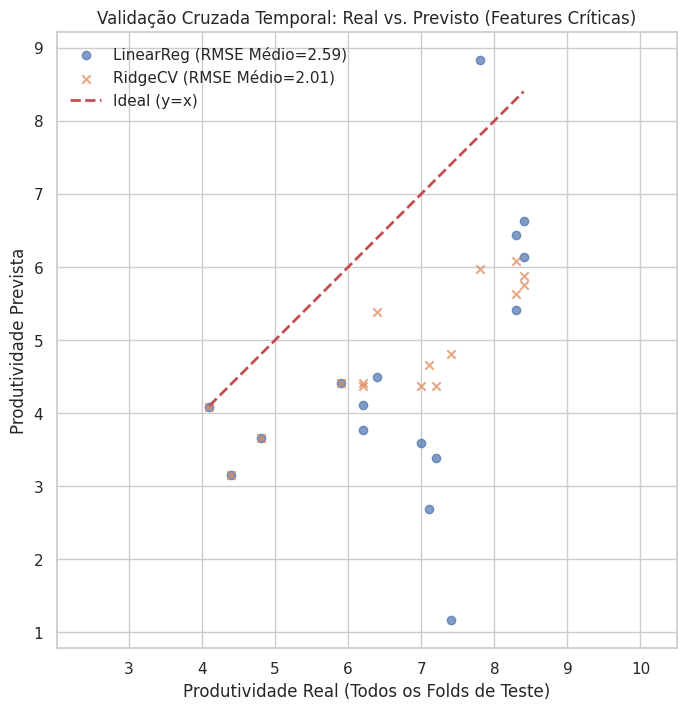


--- Treinamento do Modelo Final (Opcional) ---
  Treinando modelo RidgeCV final com todos os dados (features críticas)...
  Modelo Ridge final treinado com alpha=10.00
  Modelo final salvo em: resultados/modelos/modelo_final_ridge_critico.joblib
  Scaler final salvo em: resultados/modelos/scaler_final_critico.joblib

  Coeficientes do Modelo Ridge Final (Features Críticas):
TEMPERATURA_media_mensal_min_critico       0.370536
PRECIPITACAO_mm_mensal_soma_sum_critico    0.192160
TEMPERATURA_media_mensal_mean_critico      0.166340
TEMPERATURA_media_mensal_max_critico       0.078041
VENTO_VEL_media_mensal_mean_critico       -0.051178
NDVI_satveg_mensal_max_critico            -0.076657
NDVI_satveg_mensal_mean_critico           -0.128718
UMIDADE_media_mensal_mean_critico         -0.228571
RADIACAO_media_mensal_mean_critico        -0.426208
dtype: float64

--- Fim da Etapa 3 (Refinada com Features Críticas) ---


In [6]:
# Etapa 3: Construção do modelo de IA (Features de Período Crítico)

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
# import joblib # Não carregaremos modelo RF, treinaremos lineares
from sklearn.model_selection import TimeSeriesSplit, LeaveOneOut # Opções de Validação Cruzada
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV # Modelos Lineares
from sklearn.preprocessing import StandardScaler # Para escalonar features
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 3: Construção do Modelo (Features de Período Crítico) ---")

# --- 1. Carregar Dados Consolidados Mensais ---
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv') # Usando a base mensal

df_mensal = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    print(f"[OK] Base consolidada mensal carregada de: {consolidated_monthly_path}")
    if 'ANO' in df_mensal.columns:
        df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada.")
    if 'MES' in df_mensal.columns:
        df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    df_mensal = df_mensal.sort_values(by=['ANO', 'MES'])
    if not df_mensal.empty:
        print(f"     Intervalo de Anos Carregado: {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    else: raise ValueError("DataFrame mensal vazio após carregamento/limpeza inicial.")
except FileNotFoundError:
    print(f"[ERRO CRÍTICO] Arquivo '{consolidated_monthly_path}' não encontrado.")
    # sys.exit()
except ValueError as ve:
     print(f"[ERRO CRÍTICO] Problema ao processar colunas ANO/MES: {ve}")
     # sys.exit()
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar ou processar a base consolidada mensal: {e}")
    # sys.exit()

# --- 2. Engenharia de Atributos (Foco no Período Crítico) ---
print("\n--- Agregando Features do Período Crítico Anualmente ---")

# *** DEFINA OS MESES CRÍTICOS AQUI ***
# Baseado na análise anterior (pico NDVI SatVeg em Março?),
# vamos usar Fev, Mar, Abr (2, 3, 4) como exemplo. Ajuste se necessário.
meses_criticos = [2, 3, 4]
print(f"  Meses definidos como críticos: {meses_criticos}")

df_anual_critico = None

# Verifica se o DataFrame mensal foi carregado
if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame) and not df_mensal.empty:
    # Filtra os dados mensais para incluir apenas os meses críticos
    df_periodo_critico = df_mensal[df_mensal['MES'].isin(meses_criticos)].copy()

    if not df_periodo_critico.empty:
        print(f"  Dados filtrados para os meses críticos. Linhas restantes: {len(df_periodo_critico)}")

        # Define as agregações desejadas DENTRO do período crítico
        # Usaremos 'mean' para a maioria, 'sum' para precipitação, 'max' para NDVI pode ser interessante
        aggregations_critico = {
            # Clima (média no período crítico)
            'RADIACAO_media_mensal': ['mean'],
            'TEMPERATURA_media_mensal': ['mean', 'max', 'min'], # Média, max e min da temperatura no período
            'PRECIPITACAO_mm_mensal_soma': ['sum'], # Soma da precipitação no período
            'UMIDADE_media_mensal': ['mean'], # Média da umidade no período
            'VENTO_VEL_media_mensal': ['mean'],   # Média do vento no período
            # NDVI SatVeg (média e máximo no período crítico)
            'NDVI_satveg_mensal': ['mean', 'max'],
            # Produtividade (Alvo) - Pega o primeiro valor do ano (já deve ser único)
            'Produtividade_Anual': ['first']
        }

        # Filtra o dicionário de agregações para incluir apenas colunas existentes
        agg_funcs_critico_existentes = {}
        for col, funcs in aggregations_critico.items():
            if col in df_periodo_critico.columns:
                agg_funcs_critico_existentes[col] = funcs
            else:
                print(f"    [AVISO] Coluna '{col}' não encontrada para agregação no período crítico.")

        # Realiza a agregação anual se houver funções definidas
        if agg_funcs_critico_existentes:
            try:
                # Agrega os dados filtrados por ANO
                df_anual_critico = df_periodo_critico.groupby('ANO', observed=False).agg(agg_funcs_critico_existentes)
                # Achata os nomes das colunas multi-nível, adicionando sufixo '_critico'
                df_anual_critico.columns = ['_'.join(col).strip() + '_critico' for col in df_anual_critico.columns.values]
                # Renomeia a coluna alvo
                target_col_agg = 'Produtividade_Anual_first_critico'
                if target_col_agg in df_anual_critico.columns:
                    df_anual_critico = df_anual_critico.rename(columns={target_col_agg: 'Produtividade_Anual'})
                else: raise ValueError("Coluna alvo não encontrada após agregação crítica.")

                # Remove anos onde a produtividade anual é NaN
                df_anual_critico.dropna(subset=['Produtividade_Anual'], inplace=True)
                # Remove colunas que são totalmente NaN após agregação
                df_anual_critico.dropna(axis=1, how='all', inplace=True)
                # Garante ordenação por ano (índice)
                df_anual_critico = df_anual_critico.sort_index()

                if df_anual_critico.empty: raise ValueError("DataFrame anual crítico vazio após agregação/limpeza.")

                print("[OK] Agregação anual focada no período crítico concluída.")
                print(f"     Dimensões da base anual crítica: {df_anual_critico.shape}")
                print("     Primeiras linhas da base anual crítica:")
                print(df_anual_critico.head())
                print("\n     Colunas disponíveis na base anual crítica:")
                print(df_anual_critico.columns.tolist())

            except Exception as e_agg:
                 print(f"[ERRO] Falha durante a agregação do período crítico: {e_agg}")
                 df_anual_critico = None
        else:
            print("[ERRO] Nenhuma coluna válida encontrada para realizar a agregação do período crítico.")
            df_anual_critico = None
    else:
        print("[ERRO] Nenhum dado encontrado para os meses críticos selecionados.")
        df_anual_critico = None
else:
    print("[ERRO] DataFrame mensal ('df_mensal') não está definido ou vazio.")
    df_anual_critico = None

# --- 3. Seleção de Atributos (Features) e Alvo (Target) ---
print("\n--- Selecionando Features e Target (Período Crítico) ---")

X = None
y = None
features_cols = []

# Verifica se a base anual crítica foi criada
if 'df_anual_critico' in locals() and isinstance(df_anual_critico, pd.DataFrame) and 'Produtividade_Anual' in df_anual_critico.columns:
    target = 'Produtividade_Anual'
    y = df_anual_critico[target]
    # Seleciona todas as outras colunas (agregadas no período crítico) como features
    features_cols = [col for col in df_anual_critico.columns if col != target]
    X = df_anual_critico[features_cols]

    # Tratar NaNs restantes nas features (preenchendo com a média)
    if X.isnull().any().any():
         print("  [AVISO] Existem NaNs nas features críticas. Preenchendo com a média da coluna...")
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         X.fillna(means, inplace=True)
         if X.isnull().any().any():
              cols_com_nan_final = X.columns[X.isnull().any()].tolist()
              print(f"  [ERRO] NaNs persistentes nas features críticas após preenchimento: {cols_com_nan_final}.")
              X = None # Invalida se ainda houver NaNs

    if X is not None:
         print(f"[OK] Target definido: '{target}' ({len(y)} amostras)")
         print(f"[OK] Features (Período Crítico) definidas: {len(features_cols)} colunas ({X.shape[0]} amostras)")
         print("     Nomes das Features:", features_cols)

else:
    print("[ERRO] DataFrame anual crítico ('df_anual_critico') ou coluna 'Produtividade_Anual' não disponíveis.")


# --- 4. Validação Cruzada Temporal com Modelos Lineares ---
# (A lógica desta seção permanece a mesma, mas agora usará o X e y derivados do período crítico)
print("\n--- Implementando Validação Cruzada Temporal (Modelos Lineares com Features Críticas) ---")

if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")

        fold_metrics_lr = {'r2': [], 'rmse': [], 'mae': []}
        fold_metrics_ridge = {'r2': [], 'rmse': [], 'mae': []}
        fold_counter = 0
        all_y_test_ts, all_y_pred_lr, all_y_pred_ridge = [], [], []

        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]
            anos_treino = X_train_ts.index.tolist(); anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_ts)
                X_test_scaled = scaler.transform(X_test_ts)
                print("    Features escalonadas.")

                lr_model = LinearRegression()
                lr_model.fit(X_train_scaled, y_train_ts)
                y_pred_lr = lr_model.predict(X_test_scaled)
                r2_lr = r2_score(y_test_ts, y_pred_lr) if len(y_test_ts) > 1 else np.nan
                rmse_lr = np.sqrt(mean_squared_error(y_test_ts, y_pred_lr))
                mae_lr = mean_absolute_error(y_test_ts, y_pred_lr)
                fold_metrics_lr['r2'].append(r2_lr); fold_metrics_lr['rmse'].append(rmse_lr); fold_metrics_lr['mae'].append(mae_lr)
                print(f"      LR - Métricas: R²={r2_lr:.4f}, RMSE={rmse_lr:.4f}, MAE={mae_lr:.4f}")

                alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
                ridge_cv_model = RidgeCV(alphas=alphas_to_test, store_cv_values=True)
                ridge_cv_model.fit(X_train_scaled, y_train_ts)
                best_alpha = ridge_cv_model.alpha_
                print(f"    Melhor Alpha para Ridge (Fold {fold_counter}): {best_alpha:.2f}")
                y_pred_ridge = ridge_cv_model.predict(X_test_scaled)
                r2_ridge = r2_score(y_test_ts, y_pred_ridge) if len(y_test_ts) > 1 else np.nan
                rmse_ridge = np.sqrt(mean_squared_error(y_test_ts, y_pred_ridge))
                mae_ridge = mean_absolute_error(y_test_ts, y_pred_ridge)
                fold_metrics_ridge['r2'].append(r2_ridge); fold_metrics_ridge['rmse'].append(rmse_ridge); fold_metrics_ridge['mae'].append(mae_ridge)
                print(f"      RidgeCV - Métricas: R²={r2_ridge:.4f}, RMSE={rmse_ridge:.4f}, MAE={mae_ridge:.4f}")

                all_y_test_ts.extend(y_test_ts.tolist())
                all_y_pred_lr.extend(y_pred_lr.tolist())
                all_y_pred_ridge.extend(y_pred_ridge.tolist())

            except Exception as e_fold:
                print(f"    [ERRO] Falha ao treinar/avaliar o Fold {fold_counter}: {e_fold}")
                for metrics_dict in [fold_metrics_lr, fold_metrics_ridge]:
                    metrics_dict['r2'].append(np.nan); metrics_dict['rmse'].append(np.nan); metrics_dict['mae'].append(np.nan)

        # --- Resultados Consolidados da Validação Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal (Features Críticas) ---")
        print("\n    Modelo: Regressão Linear")
        if fold_metrics_lr['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_lr['r2']):.4f} ± {np.nanstd(fold_metrics_lr['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_lr['rmse']):.4f} ± {np.nanstd(fold_metrics_lr['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_lr['mae']):.4f} ± {np.nanstd(fold_metrics_lr['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        print("\n    Modelo: Regressão Ridge (com CV para Alpha)")
        if fold_metrics_ridge['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_ridge['r2']):.4f} ± {np.nanstd(fold_metrics_ridge['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_ridge['rmse']):.4f} ± {np.nanstd(fold_metrics_ridge['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_ridge['mae']):.4f} ± {np.nanstd(fold_metrics_ridge['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        # --- Plot Consolidado: Real vs Previsto (Todos os Folds) ---
        print("\n  --- Gráfico Consolidado: Real vs. Previsto (Todos os Folds) ---")
        if all_y_test_ts:
             plt.figure(figsize=(8, 8))
             plt.scatter(all_y_test_ts, all_y_pred_lr, alpha=0.7, label=f'LinearReg (RMSE Médio={np.nanmean(fold_metrics_lr["rmse"]):.2f})')
             plt.scatter(all_y_test_ts, all_y_pred_ridge, alpha=0.7, label=f'RidgeCV (RMSE Médio={np.nanmean(fold_metrics_ridge["rmse"]):.2f})', marker='x')
             min_val = min(all_y_test_ts); max_val = max(all_y_test_ts)
             plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
             plt.xlabel('Produtividade Real (Todos os Folds de Teste)')
             plt.ylabel('Produtividade Prevista')
             plt.title('Validação Cruzada Temporal: Real vs. Previsto (Features Críticas)')
             plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()
        else: print("    Nenhuma previsão válida gerada para o gráfico consolidado.")

    elif n_anos <= 1: print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit.")
    else: print(f"[AVISO] Número de splits ({n_splits_ts}) inválido. Validação não executada.")
else:
    print("[ERRO] Dados anuais (X, y) com features críticas não disponíveis para Validação.")

# --- 5. Treinar Modelo Final e Salvar (Opcional) ---
# (Código de Treinamento Final e Salvamento permanece o mesmo, mas usará as features críticas)
print("\n--- Treinamento do Modelo Final (Opcional) ---")
final_model = None
if X is not None and y is not None:
     try:
          print("  Treinando modelo RidgeCV final com todos os dados (features críticas)...")
          final_scaler = StandardScaler()
          X_scaled_final = final_scaler.fit_transform(X)
          final_ridge_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
          final_ridge_model.fit(X_scaled_final, y)
          final_model = final_ridge_model
          print(f"  Modelo Ridge final treinado com alpha={final_model.alpha_:.2f}")

          model_folder = os.path.join('resultados', 'modelos')
          os.makedirs(model_folder, exist_ok=True)
          model_path_final = os.path.join(model_folder, 'modelo_final_ridge_critico.joblib') # Nome diferente
          scaler_path_final = os.path.join(model_folder, 'scaler_final_critico.joblib') # Nome diferente
          # Importar joblib aqui se ainda não foi importado
          try: import joblib
          except ImportError: print("[ERRO] Biblioteca 'joblib' não instalada. Não foi possível salvar o modelo.")
          joblib.dump(final_model, model_path_final)
          joblib.dump(final_scaler, scaler_path_final)
          print(f"  Modelo final salvo em: {model_path_final}")
          print(f"  Scaler final salvo em: {scaler_path_final}")

          if hasattr(final_model, 'coef_') and hasattr(X, 'columns'):
               print("\n  Coeficientes do Modelo Ridge Final (Features Críticas):")
               coefs = pd.Series(final_model.coef_, index=X.columns).sort_values(ascending=False)
               print(coefs)

     except Exception as e_final:
          print(f"[ERRO] Falha ao treinar ou salvar o modelo final: {e_final}")
else:
     print("  Dados (X, y) não disponíveis para treinar modelo final.")

print("\n--- Fim da Etapa 3 (Refinada com Features Críticas) ---")


--- Iniciando Etapa 3: Construção do Modelo (RandomForest com Features Críticas) ---
[OK] Base consolidada mensal carregada de: dados_processados/base_consolidada_mensal.csv
     Intervalo de Anos Carregado: 2003 - 2025

--- Agregando Features do Período Crítico Anualmente ---
  Meses definidos como críticos: [2, 3, 4]
  Dados filtrados para os meses críticos. Linhas restantes: 59
[OK] Agregação anual focada no período crítico concluída.
     Dimensões da base anual crítica: (20, 10)

     Colunas disponíveis na base anual crítica:
['RADIACAO_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_max_critico', 'TEMPERATURA_media_mensal_min_critico', 'PRECIPITACAO_mm_mensal_soma_sum_critico', 'UMIDADE_media_mensal_mean_critico', 'VENTO_VEL_media_mensal_mean_critico', 'NDVI_satveg_mensal_mean_critico', 'NDVI_satveg_mensal_max_critico', 'Produtividade_Anual']

--- Selecionando Features e Target (Período Crítico) ---
[OK] Target: 'Produtividade_Anual

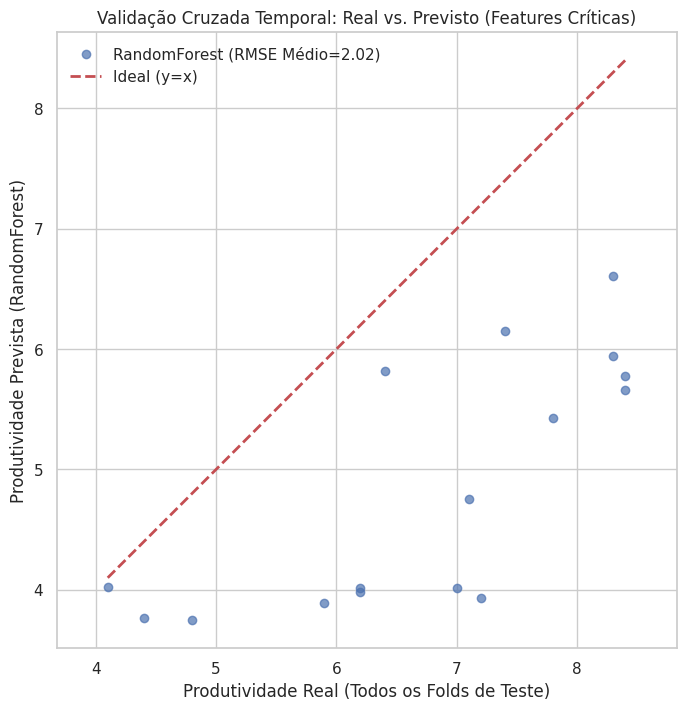


  --- Importância Média das Features (RandomForest - Todos os Folds) ---
                                   Feature  Importance
0       RADIACAO_media_mensal_mean_critico    0.227121
8           NDVI_satveg_mensal_max_critico    0.211355
1    TEMPERATURA_media_mensal_mean_critico    0.102206
5        UMIDADE_media_mensal_mean_critico    0.098971
3     TEMPERATURA_media_mensal_min_critico    0.098023
2     TEMPERATURA_media_mensal_max_critico    0.095173
4  PRECIPITACAO_mm_mensal_soma_sum_critico    0.070469
6      VENTO_VEL_media_mensal_mean_critico    0.056589
7          NDVI_satveg_mensal_mean_critico    0.040093


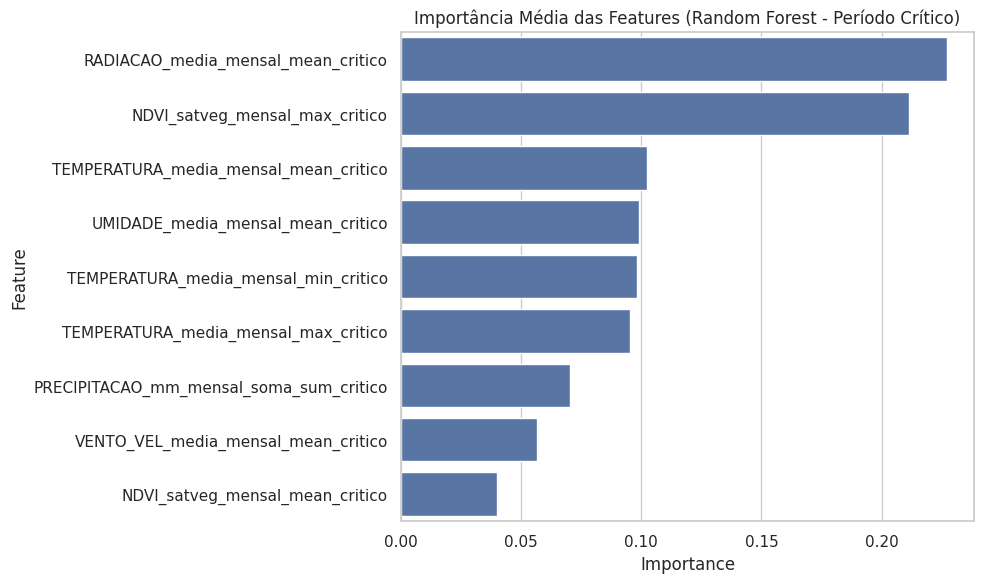


--- Treinamento do Modelo Final RandomForest (Opcional) ---
  Treinando modelo RandomForest final com todos os dados (features críticas)...
  Modelo RandomForest final treinado.
  Modelo final RandomForest salvo em: resultados/modelos/modelo_final_rf_critico.joblib

  Importância das Features (Modelo Final RandomForest):
                                   Feature  Importance
0       RADIACAO_media_mensal_mean_critico    0.364641
5        UMIDADE_media_mensal_mean_critico    0.150204
8           NDVI_satveg_mensal_max_critico    0.133145
2     TEMPERATURA_media_mensal_max_critico    0.090964
1    TEMPERATURA_media_mensal_mean_critico    0.082740
3     TEMPERATURA_media_mensal_min_critico    0.082507
6      VENTO_VEL_media_mensal_mean_critico    0.048585
4  PRECIPITACAO_mm_mensal_soma_sum_critico    0.028286
7          NDVI_satveg_mensal_mean_critico    0.018929

--- Fim da Etapa 3 (RandomForest com Features Críticas) ---


In [7]:
# -*- coding: utf-8 -*-
# Etapa 3: Construção do Modelo de IA (RandomForest com Features de Período Crítico)

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
import joblib # Para salvar o modelo treinado
from sklearn.model_selection import TimeSeriesSplit # Para validação cruzada temporal
from sklearn.ensemble import RandomForestRegressor # <<< MUDANÇA: Usando RandomForest
# from sklearn.linear_model import LinearRegression, Ridge, RidgeCV # Removido
# from sklearn.preprocessing import StandardScaler # Removido (RF menos sensível)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 3: Construção do Modelo (RandomForest com Features Críticas) ---")

# --- 1. Carregar Dados Consolidados Mensais ---
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')

df_mensal = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    print(f"[OK] Base consolidada mensal carregada de: {consolidated_monthly_path}")
    if 'ANO' in df_mensal.columns:
        df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada.")
    if 'MES' in df_mensal.columns:
        df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    df_mensal = df_mensal.sort_values(by=['ANO', 'MES'])
    if not df_mensal.empty:
        print(f"     Intervalo de Anos Carregado: {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    else: raise ValueError("DataFrame mensal vazio após carregamento/limpeza inicial.")
except FileNotFoundError:
    print(f"[ERRO CRÍTICO] Arquivo '{consolidated_monthly_path}' não encontrado.")
    # sys.exit()
except ValueError as ve:
     print(f"[ERRO CRÍTICO] Problema ao processar colunas ANO/MES: {ve}")
     # sys.exit()
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar ou processar a base consolidada mensal: {e}")
    # sys.exit()

# --- 2. Engenharia de Atributos (Foco no Período Crítico) ---
print("\n--- Agregando Features do Período Crítico Anualmente ---")

# *** DEFINA OS MESES CRÍTICOS AQUI ***
meses_criticos = [2, 3, 4] # Exemplo: Fev, Mar, Abr
print(f"  Meses definidos como críticos: {meses_criticos}")

df_anual_critico = None

if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame) and not df_mensal.empty:
    df_periodo_critico = df_mensal[df_mensal['MES'].isin(meses_criticos)].copy()

    if not df_periodo_critico.empty:
        print(f"  Dados filtrados para os meses críticos. Linhas restantes: {len(df_periodo_critico)}")
        aggregations_critico = {
            'RADIACAO_media_mensal': ['mean'],
            'TEMPERATURA_media_mensal': ['mean', 'max', 'min'],
            'PRECIPITACAO_mm_mensal_soma': ['sum'],
            'UMIDADE_media_mensal': ['mean'],
            'VENTO_VEL_media_mensal': ['mean'],
            'NDVI_satveg_mensal': ['mean', 'max'],
            'Produtividade_Anual': ['first']
        }
        agg_funcs_critico_existentes = {col: funcs for col, funcs in aggregations_critico.items() if col in df_periodo_critico.columns}

        if agg_funcs_critico_existentes:
            try:
                df_anual_critico = df_periodo_critico.groupby('ANO', observed=False).agg(agg_funcs_critico_existentes)
                df_anual_critico.columns = ['_'.join(col).strip() + '_critico' for col in df_anual_critico.columns.values]
                target_col_agg = 'Produtividade_Anual_first_critico'
                if target_col_agg in df_anual_critico.columns:
                    df_anual_critico = df_anual_critico.rename(columns={target_col_agg: 'Produtividade_Anual'})
                else: raise ValueError("Coluna alvo não encontrada após agregação crítica.")
                df_anual_critico.dropna(subset=['Produtividade_Anual'], inplace=True)
                df_anual_critico.dropna(axis=1, how='all', inplace=True)
                df_anual_critico = df_anual_critico.sort_index()
                if df_anual_critico.empty: raise ValueError("DataFrame anual crítico vazio após agregação/limpeza.")
                print("[OK] Agregação anual focada no período crítico concluída.")
                print(f"     Dimensões da base anual crítica: {df_anual_critico.shape}")
                # print("     Primeiras linhas da base anual crítica:") # Comentado para brevidade
                # print(df_anual_critico.head())
                print("\n     Colunas disponíveis na base anual crítica:")
                print(df_anual_critico.columns.tolist())
            except Exception as e_agg: print(f"[ERRO] Falha durante a agregação: {e_agg}"); df_anual_critico = None
        else: print("[ERRO] Nenhuma coluna válida para agregação."); df_anual_critico = None
    else: print("[ERRO] Nenhum dado encontrado para os meses críticos."); df_anual_critico = None
else: print("[ERRO] DataFrame mensal não definido ou vazio."); df_anual_critico = None

# --- 3. Seleção de Atributos (Features) e Alvo (Target) ---
print("\n--- Selecionando Features e Target (Período Crítico) ---")
X = None; y = None; features_cols = []
if 'df_anual_critico' in locals() and isinstance(df_anual_critico, pd.DataFrame) and 'Produtividade_Anual' in df_anual_critico.columns:
    target = 'Produtividade_Anual'
    y = df_anual_critico[target]
    features_cols = [col for col in df_anual_critico.columns if col != target]
    X = df_anual_critico[features_cols]
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features críticas com a média...");
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): print(f"  [ERRO] NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); X = None
    if X is not None: print(f"[OK] Target: '{target}' ({len(y)} amostras). Features: {len(features_cols)} ({X.shape[0]} amostras)."); print("     Features:", features_cols)
else: print("[ERRO] DataFrame anual crítico ou Target não disponíveis.")

# --- 4. Validação Cruzada Temporal com RandomForestRegressor ---
print("\n--- Implementando Validação Cruzada Temporal (RandomForest com Features Críticas) ---")

if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")

        fold_metrics_rf = {'r2': [], 'rmse': [], 'mae': []} # Métricas para RandomForest
        fold_counter = 0
        all_y_test_ts = []
        all_y_pred_rf = []
        feature_importances_list = [] # Para armazenar importâncias de cada fold

        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]
            anos_treino = X_train_ts.index.tolist(); anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                # --- Modelo: RandomForestRegressor ---
                print("    Treinando RandomForestRegressor (parâmetros padrão)...")
                # Usar random_state para reprodutibilidade
                rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
                rf_model.fit(X_train_ts, y_train_ts) # Treina com dados não escalonados
                y_pred_rf = rf_model.predict(X_test_ts)

                # Calcular e armazenar métricas RF
                r2_rf = r2_score(y_test_ts, y_pred_rf) if len(y_test_ts) > 1 else np.nan
                rmse_rf = np.sqrt(mean_squared_error(y_test_ts, y_pred_rf))
                mae_rf = mean_absolute_error(y_test_ts, y_pred_rf)
                fold_metrics_rf['r2'].append(r2_rf); fold_metrics_rf['rmse'].append(rmse_rf); fold_metrics_rf['mae'].append(mae_rf)
                print(f"      RF - Métricas: R²={r2_rf:.4f}, RMSE={rmse_rf:.4f}, MAE={mae_rf:.4f}")

                # Armazenar importâncias das features deste fold
                if hasattr(rf_model, 'feature_importances_'):
                     feature_importances_list.append(rf_model.feature_importances_)

                # Armazenar resultados para plot final
                all_y_test_ts.extend(y_test_ts.tolist())
                all_y_pred_rf.extend(y_pred_rf.tolist())

            except Exception as e_fold:
                print(f"    [ERRO] Falha ao treinar/avaliar o Fold {fold_counter}: {e_fold}")
                fold_metrics_rf['r2'].append(np.nan); fold_metrics_rf['rmse'].append(np.nan); fold_metrics_rf['mae'].append(np.nan)

        # --- Resultados Consolidados da Validação Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal (RandomForest) ---")
        if fold_metrics_rf['rmse']:
             print(f"    R² Médio    : {np.nanmean(fold_metrics_rf['r2']):.4f} ± {np.nanstd(fold_metrics_rf['r2']):.4f}")
             print(f"    RMSE Médio  : {np.nanmean(fold_metrics_rf['rmse']):.4f} ± {np.nanstd(fold_metrics_rf['rmse']):.4f}")
             print(f"    MAE Médio   : {np.nanmean(fold_metrics_rf['mae']):.4f} ± {np.nanstd(fold_metrics_rf['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        # --- Plot Consolidado: Real vs Previsto (Todos os Folds) ---
        print("\n  --- Gráfico Consolidado: Real vs. Previsto (RandomForest - Todos os Folds) ---")
        if all_y_test_ts:
             plt.figure(figsize=(8, 8))
             plt.scatter(all_y_test_ts, all_y_pred_rf, alpha=0.7, label=f'RandomForest (RMSE Médio={np.nanmean(fold_metrics_rf["rmse"]):.2f})')
             min_val = min(all_y_test_ts); max_val = max(all_y_test_ts)
             plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
             plt.xlabel('Produtividade Real (Todos os Folds de Teste)')
             plt.ylabel('Produtividade Prevista (RandomForest)')
             plt.title('Validação Cruzada Temporal: Real vs. Previsto (Features Críticas)')
             plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()
        else: print("    Nenhuma previsão válida gerada para o gráfico consolidado.")

        # --- Análise de Importância Média das Features ---
        if feature_importances_list and features_cols:
             print("\n  --- Importância Média das Features (RandomForest - Todos os Folds) ---")
             mean_importances = np.mean(feature_importances_list, axis=0)
             feature_importance_df = pd.DataFrame({'Feature': features_cols, 'Importance': mean_importances})
             feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
             print(feature_importance_df)

             plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.3)))
             sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
             plt.title('Importância Média das Features (Random Forest - Período Crítico)')
             plt.tight_layout()
             plt.show()

    elif n_anos <= 1: print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit.")
    else: print(f"[AVISO] Número de splits ({n_splits_ts}) inválido. Validação não executada.")
else:
    print("[ERRO] Dados anuais (X, y) com features críticas não disponíveis para Validação.")


# --- 5. Treinar Modelo Final e Salvar (Opcional) ---
print("\n--- Treinamento do Modelo Final RandomForest (Opcional) ---")
final_model_rf = None
if X is not None and y is not None:
     try:
          print("  Treinando modelo RandomForest final com todos os dados (features críticas)...")
          # Usar parâmetros padrão ou os melhores encontrados em um GridSearch anterior (se feito)
          final_model_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
          final_model_rf.fit(X, y) # Treina com todos os dados
          print(f"  Modelo RandomForest final treinado.")

          # Salvar o modelo final
          model_folder = os.path.join('resultados', 'modelos')
          os.makedirs(model_folder, exist_ok=True)
          model_path_final_rf = os.path.join(model_folder, 'modelo_final_rf_critico.joblib')
          joblib.dump(final_model_rf, model_path_final_rf)
          print(f"  Modelo final RandomForest salvo em: {model_path_final_rf}")

          # Exibir importância das features do modelo final
          if hasattr(final_model_rf, 'feature_importances_') and hasattr(X, 'columns'):
               print("\n  Importância das Features (Modelo Final RandomForest):")
               importances_final = final_model_rf.feature_importances_
               feature_names_final = X.columns
               feature_importance_df_final = pd.DataFrame({'Feature': feature_names_final, 'Importance': importances_final})
               feature_importance_df_final = feature_importance_df_final.sort_values(by='Importance', ascending=False)
               print(feature_importance_df_final)

     except Exception as e_final:
          print(f"[ERRO] Falha ao treinar ou salvar o modelo final RandomForest: {e_final}")
else:
     print("  Dados (X, y) não disponíveis para treinar modelo final.")


print("\n--- Fim da Etapa 3 (RandomForest com Features Críticas) ---")


--- Iniciando Etapa 3: Construção do Modelo (Agregação por Safra - Apenas Dados Reais) ---
[OK] Base consolidada mensal (232 linhas) e base de milho (52 linhas) carregadas.
     Intervalo de Anos (Mensal): 2003 - 2025
     Intervalo de Anos (Milho): 2002 - 2024
     Safras encontradas: ['1ª Safra', '2ª Safra', '3ª Safra']

--- Agregando Features por Safra (Refatorado) ---
    [AVISO] Nenhum dado mensal encontrado para Ano 2002, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2002, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2021, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2021, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2021, Safra '3ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2022, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2022, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encont

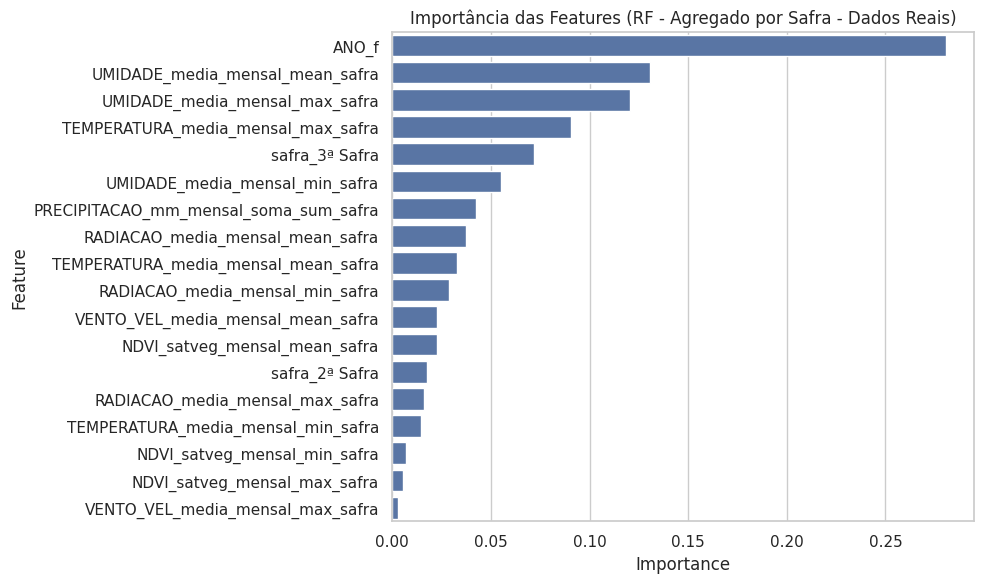

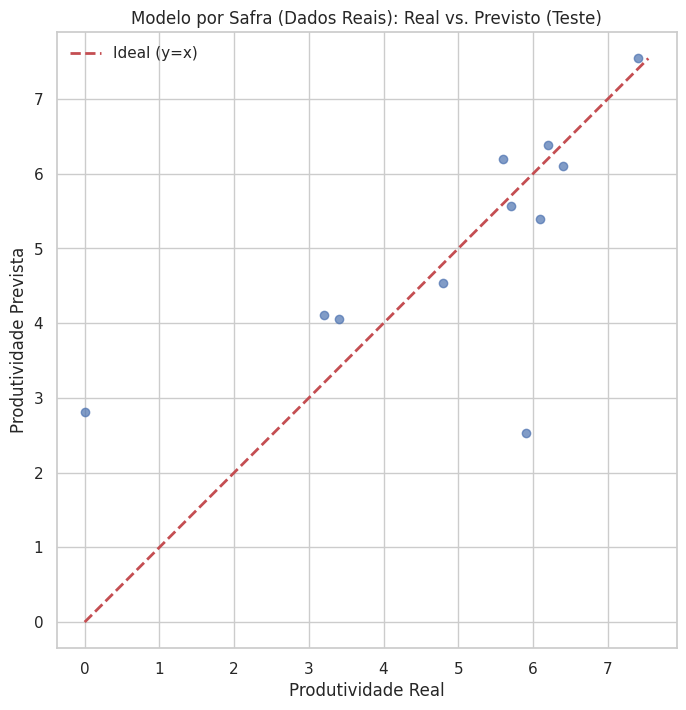


--- Salvando Modelo Final (por Safra - Dados Reais - Opcional) ---
  Modelo final RandomForest (por safra) salvo em: resultados/modelos/modelo_final_rf_por_safra_real.joblib

--- Fim da Etapa 3 (Agregação por Safra - Apenas Dados Reais) ---


In [12]:
# Etapa 3: Construção do Modelo de IA (Agregação por Safra - Apenas Dados Reais)

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
import joblib # Para salvar o modelo treinado
from sklearn.model_selection import train_test_split # Usaremos split simples inicialmente
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 3: Construção do Modelo (Agregação por Safra - Apenas Dados Reais) ---")

# --- 1. Carregar Dados Processados da Etapa 1 ---
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')
milho_path = os.path.join(processed_folder, 'milho.csv')
# solo_path = os.path.join(processed_folder, 'dados_solo_sorriso.csv') # Não tentaremos carregar solo

df_mensal = None
df_milho_proc = None
# df_solo = None # Removido
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    df_milho_proc = pd.read_csv(milho_path)
    # if os.path.exists(solo_path):
    #     df_solo = pd.read_csv(solo_path)
    #     print("[OK] Arquivo de dados de solo carregado.")
    # else:
    #     print(f"[AVISO] Arquivo de dados de solo '{solo_path}' não encontrado.") # Aviso removido

    print(f"[OK] Base consolidada mensal ({len(df_mensal)} linhas) e base de milho ({len(df_milho_proc)} linhas) carregadas.")

    # --- Preparação Inicial dos Dados ---
    if 'ANO' in df_mensal.columns: df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_mensal.")
    if 'MES' in df_mensal.columns: df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada em df_mensal.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    for col in df_mensal.select_dtypes(include=np.number).columns:
        if col not in ['ANO', 'MES']: df_mensal[col] = pd.to_numeric(df_mensal[col], errors='coerce')

    if 'ANO' in df_milho_proc.columns: df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_milho_proc.")
    if 'Produtividade_Anual' in df_milho_proc.columns: df_milho_proc['Produtividade_Anual'] = pd.to_numeric(df_milho_proc['Produtividade_Anual'], errors='coerce')
    else: raise ValueError("Coluna 'Produtividade_Anual' não encontrada.")
    if 'safra' not in df_milho_proc.columns: raise ValueError("Coluna 'safra' não encontrada.")
    df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'], inplace=True)

    if df_mensal.empty or df_milho_proc.empty: raise ValueError("DataFrames vazios.")
    print(f"     Intervalo de Anos (Mensal): {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    print(f"     Intervalo de Anos (Milho): {df_milho_proc['ANO'].min()} - {df_milho_proc['ANO'].max()}")
    print(f"     Safras encontradas: {df_milho_proc['safra'].unique().tolist()}")

except FileNotFoundError as e: print(f"[ERRO CRÍTICO] Arquivo não encontrado: {e}."); sys.exit()
except ValueError as ve: print(f"[ERRO CRÍTICO] Problema ao preparar dados: {ve}"); sys.exit()
except Exception as e: print(f"[ERRO CRÍTICO] Falha ao carregar/preparar dados: {e}"); sys.exit()

# --- 2. Engenharia de Atributos por Safra (Refatorado) ---
print("\n--- Agregando Features por Safra (Refatorado) ---")

# Define os meses para cada safra
meses_safra1 = [(10, -1), (11, -1), (12, -1), (1, 0), (2, 0)]
meses_safra2 = [(2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]
meses_safra3 = [(5, 0), (6, 0), (7, 0), (8, 0), (9, 0)]

# Colunas e funções de agregação desejadas
agg_config = {
    'mean': ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'min':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'NDVI_satveg_mensal'],
    'max':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'sum':  ['PRECIPITACAO_mm_mensal_soma']
}

lista_features_safra = []

# Itera sobre cada safra no df_milho_proc
for index, row in df_milho_proc.iterrows():
    ano_agricola = row['ANO']
    tipo_safra = row['safra']
    produtividade = row['Produtividade_Anual']

    # Removido o print repetitivo para cada safra
    # print(f"\n  Processando: Ano {ano_agricola}, Safra '{tipo_safra}'...")

    # Define os meses/anos alvo
    meses_anos_target = []
    if '1ª' in tipo_safra: meses_anos_base = meses_safra1
    elif '2ª' in tipo_safra: meses_anos_base = meses_safra2
    elif '3ª' in tipo_safra: meses_anos_base = meses_safra3
    else: print(f"    [AVISO] Tipo de safra '{tipo_safra}' não reconhecido para Ano {ano_agricola}. Pulando."); continue

    for mes, deslocamento_ano in meses_anos_base:
        meses_anos_target.append((ano_agricola + deslocamento_ano, mes))

    # Filtra dados mensais para esta safra
    df_mensal_safra = df_mensal[df_mensal.set_index(['ANO', 'MES']).index.isin(meses_anos_target)]

    if df_mensal_safra.empty:
        print(f"    [AVISO] Nenhum dado mensal encontrado para Ano {ano_agricola}, Safra '{tipo_safra}'. Pulando.")
        continue
    # print(f"    Dados mensais encontrados: {len(df_mensal_safra)} meses.") # Removido print repetitivo

    # Dicionário para armazenar features agregadas desta safra
    features_safra_dict = {'ANO': ano_agricola, 'safra': tipo_safra, 'Produtividade_Anual': produtividade}

    # Realiza agregações separadas
    for agg_func, cols_to_agg in agg_config.items():
        cols_existentes = [col for col in cols_to_agg if col in df_mensal_safra.columns]
        if not cols_existentes: continue # Pula se não houver colunas para esta função
        try:
            aggregated_data = df_mensal_safra[cols_existentes].agg(agg_func)
            for col_original, valor_agregado in aggregated_data.items():
                novo_nome = f"{col_original}_{agg_func}_safra"
                features_safra_dict[novo_nome] = valor_agregado
            # print(f"    Agregação '{agg_func}' realizada para: {cols_existentes}") # Removido print repetitivo
        except Exception as e_agg:
            print(f"    [ERRO] Falha ao agregar com '{agg_func}' para Ano {ano_agricola}, Safra '{tipo_safra}': {e_agg}")

    lista_features_safra.append(features_safra_dict)

# Cria o DataFrame final para modelagem por safra
if lista_features_safra:
    df_modelar_safra = pd.DataFrame(lista_features_safra)
    if 'ANO' in df_modelar_safra.columns and 'safra' in df_modelar_safra.columns:
         df_modelar_safra = df_modelar_safra.set_index(['ANO', 'safra']).sort_index()
         print("\n[OK] Base de dados por safra criada.")
         print(f"     Dimensões: {df_modelar_safra.shape}")

         # <<< REMOVIDO: Adição de Feature Sintética de pH >>>
         # if 'df_solo' in locals() and isinstance(df_solo, pd.DataFrame) and 'ph_solo' in df_solo.columns:
         #      print("  + Adicionando feature de pH do solo (aleatório)...")
         #      np.random.seed(42)
         #      df_modelar_safra['ph_solo_sintetico'] = np.random.uniform(5.5, 7.0, size=len(df_modelar_safra))
         # else:
         #      print("  - [AVISO] Dados de solo não disponíveis, pH não adicionado.")
         print("  - [INFO] Nenhuma feature sintética adicionada.")


         print("     Primeiras linhas da base para modelar (por safra):")
         print(df_modelar_safra.head())
         print("\n     Colunas finais para modelagem:")
         print(df_modelar_safra.columns.tolist())
    else:
         print("[ERRO] Colunas ANO ou safra ausentes após agregação."); df_modelar_safra = None
else:
    print("[ERRO] Nenhuma feature pôde ser agregada por safra."); df_modelar_safra = None

# --- 3. Seleção de Atributos (Features) e Alvo (Target) ---
print("\n--- Selecionando Features e Target (por Safra) ---")
X = None; y = None; features_cols = []
if 'df_modelar_safra' in locals() and isinstance(df_modelar_safra, pd.DataFrame) and 'Produtividade_Anual' in df_modelar_safra.columns:
    target = 'Produtividade_Anual'
    y = df_modelar_safra[target]
    features_cols_init = [col for col in df_modelar_safra.columns if col != target]
    X = df_modelar_safra[features_cols_init].copy()

    # Adicionar ANO e SAFRA como features
    X['ANO_f'] = X.index.get_level_values('ANO').astype(int)
    X['safra_f'] = X.index.get_level_values('safra')
    X = pd.get_dummies(X, columns=['safra_f'], prefix='safra', drop_first=True)
    features_cols = X.columns.tolist()

    # Preenchimento de NaNs (com média)
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features com a média...");
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         if means.isnull().any():
              print(f"    [AVISO] Colunas com média NaN (serão preenchidas com 0): {means[means.isnull()].index.tolist()}")
              means = means.fillna(0)
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): print(f"  [ERRO] NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); X = None

    if X is not None: print(f"[OK] Target: '{target}' ({len(y)} amostras). Features: {len(features_cols)} ({X.shape[0]} amostras)."); print("     Features:", features_cols)
else: print("[ERRO] DataFrame por safra ou Target não disponíveis.")


# --- 4. Divisão Treino/Teste (Simples Estratificada por Safra) ---
print("\n--- Dividindo Dados em Treino e Teste (Estratificado por Safra) ---")
X_train, X_test, y_train, y_test = None, None, None, None

if X is not None and y is not None and not X.empty and not y.empty:
    try:
        safra_original = df_modelar_safra.index.get_level_values('safra')
        if safra_original.nunique() > 1 and all(safra_original.value_counts() >= 2):
            print("  Estratificando divisão por safra.")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=safra_original)
        else:
            print("  [AVISO] Não é possível estratificar. Usando divisão aleatória simples.")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

        print(f"[OK] Dados divididos:")
        print(f"     Treino: {X_train.shape[0]} amostras")
        print(f"     Teste:  {X_test.shape[0]} amostras")
        safra_dummy_cols = [col for col in X_train.columns if 'safra_' in col]
        if safra_dummy_cols:
            print("     Distribuição das safras no treino:"); print(X_train[safra_dummy_cols].sum())
            print("     Distribuição das safras no teste:"); print(X_test[safra_dummy_cols].sum())

    except Exception as e: print(f"[ERRO] Falha ao dividir os dados: {e}")
else: print("[ERRO] Features (X) ou Target (y) não prontos para divisão.")

# --- 5. Treinamento e Avaliação do RandomForestRegressor ---
print("\n--- Treinando e Avaliando RandomForestRegressor (por Safra - Apenas Dados Reais) ---")
model_rf_safra = None

if X_train is not None and y_train is not None and X_test is not None and y_test is not None:
    try:
        print("  Treinando RandomForestRegressor...")
        model_rf_safra = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=10, min_samples_leaf=2)
        model_rf_safra.fit(X_train, y_train)
        y_pred = model_rf_safra.predict(X_test)

        # Avaliação
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        print("\n[OK] Métricas de Avaliação no Conjunto de Teste (por Safra):")
        print(f"     R-quadrado (R²): {r2:.4f}")
        print(f"     RMSE: {rmse:.4f}")
        print(f"     MAE: {mae:.4f}")

        # Importância das Features
        if hasattr(model_rf_safra, 'feature_importances_') and hasattr(X_train, 'columns'):
            print("\n     Importância das Features:")
            importances = model_rf_safra.feature_importances_
            feature_names = X_train.columns
            feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
            print(feature_importance_df)
            plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.3)))
            sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
            plt.title('Importância das Features (RF - Agregado por Safra - Dados Reais)')
            plt.tight_layout(); plt.show()

        # Gráfico Real vs Previsto
        plt.figure(figsize=(8, 8))
        plt.scatter(y_test, y_pred, alpha=0.7)
        min_val = min(y_test.min(), y_pred.min()); max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
        plt.xlabel('Produtividade Real'); plt.ylabel('Produtividade Prevista')
        plt.title('Modelo por Safra (Dados Reais): Real vs. Previsto (Teste)')
        plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()

    except Exception as e_train_eval: print(f"[ERRO] Falha ao treinar ou avaliar: {e_train_eval}")
else: print("[ERRO] Dados de treino/teste não disponíveis.")

# --- 6. Salvar Modelo Final (Opcional) ---
print("\n--- Salvando Modelo Final (por Safra - Dados Reais - Opcional) ---")
if model_rf_safra is not None:
     model_folder = os.path.join('resultados', 'modelos')
     os.makedirs(model_folder, exist_ok=True)
     model_path_final_rf_safra = os.path.join(model_folder, 'modelo_final_rf_por_safra_real.joblib') # Nome ajustado
     try:
          joblib.dump(model_rf_safra, model_path_final_rf_safra)
          print(f"  Modelo final RandomForest (por safra) salvo em: {model_path_final_rf_safra}")
     except Exception as e_save: print(f"[ERRO] Falha ao salvar o modelo: {e_save}")
else: print("  Nenhum modelo treinado para salvar.")

print("\n--- Fim da Etapa 3 (Agregação por Safra - Apenas Dados Reais) ---")






--- Iniciando Etapa 3: Construção do Modelo (Otimização RF por Safra) ---
[OK] Base consolidada mensal (232 linhas) e base de milho (52 linhas) carregadas.
     Intervalo de Anos (Mensal): 2003 - 2025
     Intervalo de Anos (Milho): 2002 - 2024
     Safras encontradas: ['1ª Safra', '2ª Safra', '3ª Safra']

--- Agregando Features por Safra (Refatorado) ---
    [AVISO] Nenhum dado mensal para Ano 2002, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2002, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2021, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2021, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2021, Safra '3ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2022, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2022, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2022, Safra '3ª Safra'. Pulando.

[OK] Base de dados por safra criada.
     Dimensões: (44,

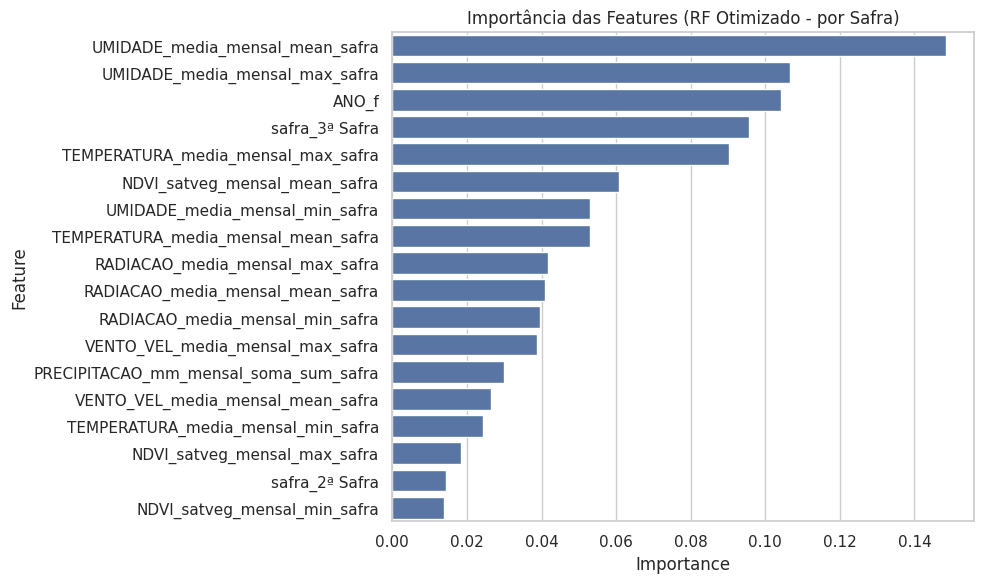

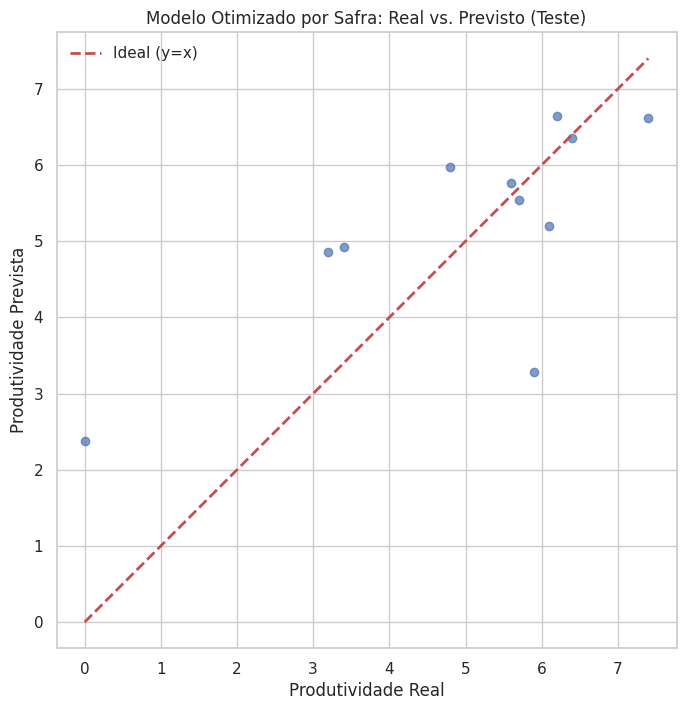


--- Salvando Modelo Final Otimizado (por Safra - Opcional) ---
  Melhor modelo RandomForest (por safra) salvo em: resultados/modelos/modelo_final_rf_por_safra_otimizado.joblib

--- Fim da Etapa 3 (Otimização RF por Safra) ---


In [13]:
# Etapa 3: Construção do Modelo de IA (Otimização RF por Safra) # <<< Título Atualizado

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
import joblib # Para salvar o modelo treinado
# <<< ADICIONADO: GridSearchCV >>>
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 3: Construção do Modelo (Otimização RF por Safra) ---") # <<< Título Atualizado

# --- 1. Carregar Dados Processados da Etapa 1 ---
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')
milho_path = os.path.join(processed_folder, 'milho.csv')
# solo_path = os.path.join(processed_folder, 'dados_solo_sorriso.csv') # Não usaremos solo

df_mensal = None
df_milho_proc = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    df_milho_proc = pd.read_csv(milho_path)
    print(f"[OK] Base consolidada mensal ({len(df_mensal)} linhas) e base de milho ({len(df_milho_proc)} linhas) carregadas.")

    # Preparação Inicial dos Dados (igual à versão anterior)
    if 'ANO' in df_mensal.columns: df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_mensal.")
    if 'MES' in df_mensal.columns: df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada em df_mensal.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    for col in df_mensal.select_dtypes(include=np.number).columns:
        if col not in ['ANO', 'MES']: df_mensal[col] = pd.to_numeric(df_mensal[col], errors='coerce')

    if 'ANO' in df_milho_proc.columns: df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_milho_proc.")
    if 'Produtividade_Anual' in df_milho_proc.columns: df_milho_proc['Produtividade_Anual'] = pd.to_numeric(df_milho_proc['Produtividade_Anual'], errors='coerce')
    else: raise ValueError("Coluna 'Produtividade_Anual' não encontrada.")
    if 'safra' not in df_milho_proc.columns: raise ValueError("Coluna 'safra' não encontrada.")
    df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'], inplace=True)

    if df_mensal.empty or df_milho_proc.empty: raise ValueError("DataFrames vazios.")
    print(f"     Intervalo de Anos (Mensal): {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    print(f"     Intervalo de Anos (Milho): {df_milho_proc['ANO'].min()} - {df_milho_proc['ANO'].max()}")
    print(f"     Safras encontradas: {df_milho_proc['safra'].unique().tolist()}")

except FileNotFoundError as e: print(f"[ERRO CRÍTICO] Arquivo não encontrado: {e}."); sys.exit()
except ValueError as ve: print(f"[ERRO CRÍTICO] Problema ao preparar dados: {ve}"); sys.exit()
except Exception as e: print(f"[ERRO CRÍTICO] Falha ao carregar/preparar dados: {e}"); sys.exit()

# --- 2. Engenharia de Atributos por Safra (Refatorado) ---
print("\n--- Agregando Features por Safra (Refatorado) ---")
meses_safra1 = [(10, -1), (11, -1), (12, -1), (1, 0), (2, 0)]
meses_safra2 = [(2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]
meses_safra3 = [(5, 0), (6, 0), (7, 0), (8, 0), (9, 0)]
agg_config = {
    'mean': ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'min':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'NDVI_satveg_mensal'],
    'max':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'sum':  ['PRECIPITACAO_mm_mensal_soma']
}
lista_features_safra = []
for index, row in df_milho_proc.iterrows():
    ano_agricola = row['ANO']; tipo_safra = row['safra']; produtividade = row['Produtividade_Anual']
    meses_anos_target = []; meses_anos_base = None
    if '1ª' in tipo_safra: meses_anos_base = meses_safra1
    elif '2ª' in tipo_safra: meses_anos_base = meses_safra2
    elif '3ª' in tipo_safra: meses_anos_base = meses_safra3
    else: print(f"    [AVISO] Tipo de safra '{tipo_safra}' não reconhecido para Ano {ano_agricola}. Pulando."); continue
    for mes, deslocamento_ano in meses_anos_base: meses_anos_target.append((ano_agricola + deslocamento_ano, mes))
    df_mensal_safra = df_mensal[df_mensal.set_index(['ANO', 'MES']).index.isin(meses_anos_target)]
    if df_mensal_safra.empty: print(f"    [AVISO] Nenhum dado mensal para Ano {ano_agricola}, Safra '{tipo_safra}'. Pulando."); continue
    features_safra_dict = {'ANO': ano_agricola, 'safra': tipo_safra, 'Produtividade_Anual': produtividade}
    for agg_func, cols_to_agg in agg_config.items():
        cols_existentes = [col for col in cols_to_agg if col in df_mensal_safra.columns]
        if not cols_existentes: continue
        try:
            aggregated_data = df_mensal_safra[cols_existentes].agg(agg_func)
            for col_original, valor_agregado in aggregated_data.items(): features_safra_dict[f"{col_original}_{agg_func}_safra"] = valor_agregado
        except Exception as e_agg: print(f"    [ERRO] Falha ao agregar com '{agg_func}' para Ano {ano_agricola}, Safra '{tipo_safra}': {e_agg}")
    lista_features_safra.append(features_safra_dict)

if lista_features_safra:
    df_modelar_safra = pd.DataFrame(lista_features_safra)
    if 'ANO' in df_modelar_safra.columns and 'safra' in df_modelar_safra.columns:
         df_modelar_safra = df_modelar_safra.set_index(['ANO', 'safra']).sort_index()
         print("\n[OK] Base de dados por safra criada.")
         print(f"     Dimensões: {df_modelar_safra.shape}")
         print("  - [INFO] Nenhuma feature sintética adicionada.")
         # print("     Primeiras linhas:"); print(df_modelar_safra.head()) # Comentado
         # print("\n     Colunas finais:"); print(df_modelar_safra.columns.tolist()) # Comentado
    else: print("[ERRO] Colunas ANO ou safra ausentes."); df_modelar_safra = None
else: print("[ERRO] Nenhuma feature agregada por safra."); df_modelar_safra = None

# --- 3. Seleção de Atributos (Features) e Alvo (Target) ---
print("\n--- Selecionando Features e Target (por Safra) ---")
X = None; y = None; features_cols = []
if 'df_modelar_safra' in locals() and isinstance(df_modelar_safra, pd.DataFrame) and 'Produtividade_Anual' in df_modelar_safra.columns:
    target = 'Produtividade_Anual'
    y = df_modelar_safra[target]
    features_cols_init = [col for col in df_modelar_safra.columns if col != target]
    X = df_modelar_safra[features_cols_init].copy()
    X['ANO_f'] = X.index.get_level_values('ANO').astype(int)
    X['safra_f'] = X.index.get_level_values('safra')
    X = pd.get_dummies(X, columns=['safra_f'], prefix='safra', drop_first=True)
    features_cols = X.columns.tolist()
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features com a média...");
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean(); means = means.fillna(0)
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): print(f"  [ERRO] NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); X = None
    if X is not None: print(f"[OK] Target: '{target}' ({len(y)} amostras). Features: {len(features_cols)} ({X.shape[0]} amostras)."); # print("     Features:", features_cols) # Comentado
else: print("[ERRO] DataFrame por safra ou Target não disponíveis.")

# --- 4. Divisão Treino/Teste (Simples Estratificada por Safra) ---
print("\n--- Dividindo Dados em Treino e Teste (Estratificado por Safra) ---")
X_train, X_test, y_train, y_test = None, None, None, None
if X is not None and y is not None and not X.empty and not y.empty:
    try:
        safra_original = df_modelar_safra.index.get_level_values('safra')
        test_size_ratio = 0.25 # 25% para teste
        # Garante que haja pelo menos 1 amostra em cada classe para estratificar
        min_samples_per_class = 2
        counts = safra_original.value_counts()
        if safra_original.nunique() > 1 and all(counts >= min_samples_per_class):
             # Tenta estratificar, mas se falhar (ex: test_size muito pequeno para classes raras), faz divisão simples
             try:
                  print(f"  Tentando estratificar divisão por safra (teste={test_size_ratio:.0%})...")
                  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42, stratify=safra_original)
                  print("  [OK] Divisão estratificada realizada.")
             except ValueError as e_stratify:
                  print(f"  [AVISO] Falha na estratificação ({e_stratify}). Usando divisão aleatória simples.")
                  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)
        else:
            print(f"  [AVISO] Não é possível estratificar (nunique={safra_original.nunique()}, min_count={counts.min()}<{min_samples_per_class}). Usando divisão aleatória simples.")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)

        print(f"[OK] Dados divididos:")
        print(f"     Treino: {X_train.shape[0]} amostras")
        print(f"     Teste:  {X_test.shape[0]} amostras")
    except Exception as e: print(f"[ERRO] Falha ao dividir os dados: {e}")
else: print("[ERRO] Features (X) ou Target (y) não prontos para divisão.")

# --- 5. Otimização de Hiperparâmetros com GridSearchCV ---
print("\n--- Otimizando Hiperparâmetros do RandomForestRegressor com GridSearchCV ---")
best_model_rf = None # Inicializa o melhor modelo

if X_train is not None and y_train is not None:
    try:
        # Define a grade de parâmetros a serem testados
        # Reduzido o número de opções para acelerar com poucos dados
        param_grid_rf = {
            'n_estimators': [50, 100, 150],       # Número de árvores
            'max_depth': [5, 10, None],          # Profundidade máxima (None = sem limite)
            'min_samples_split': [2, 5],         # Mínimo de amostras para dividir um nó
            'min_samples_leaf': [1, 3],           # Mínimo de amostras em um nó folha
            'max_features': ['sqrt', 'log2']     # Número de features a considerar (alternativas a 'auto')
        }

        # Cria a instância base do RandomForest
        base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

        # Configura o GridSearchCV
        # cv=3: Usa validação cruzada com 3 folds (mais adequado para poucos dados)
        cv_folds = min(3, len(X_train)) if len(X_train) > 1 else 2
        if cv_folds < 2:
             print("[AVISO] Poucas amostras de treino para validação cruzada. Treinando modelo com parâmetros padrão.")
             best_model_rf = base_rf.fit(X_train, y_train) # Treina com params padrão
        else:
             print(f"  Iniciando busca com {cv_folds}-Fold CV (pode levar um tempo)...")
             # Usar 'r2' como scoring é mais intuitivo que neg_mean_squared_error
             grid_search_rf = GridSearchCV(estimator=base_rf, param_grid=param_grid_rf,
                                          cv=cv_folds, scoring='r2', n_jobs=-1, verbose=1)
             grid_search_rf.fit(X_train, y_train)

             # Obtém o melhor modelo encontrado
             best_model_rf = grid_search_rf.best_estimator_
             print("\n[OK] Otimização concluída!")
             print(f"     Melhores Hiperparâmetros encontrados: {grid_search_rf.best_params_}")
             print(f"     Melhor Score (R²) na validação cruzada: {grid_search_rf.best_score_:.4f}")

    except Exception as e_grid:
        print(f"[ERRO] Falha durante o GridSearchCV: {e_grid}")
        print("       Tentando treinar modelo com parâmetros padrão...")
        try:
             best_model_rf = RandomForestRegressor(random_state=42, n_jobs=-1).fit(X_train, y_train)
             print("       [OK] Modelo treinado com parâmetros padrão.")
        except Exception as e_fallback:
             print(f"       [ERRO] Falha ao treinar modelo padrão: {e_fallback}")
else:
    print("[ERRO] Dados de treino não disponíveis para otimização.")


# --- 6. Avaliação do Melhor Modelo no Conjunto de Teste ---
print("\n--- Avaliando o Melhor Modelo RandomForest no Conjunto de Teste ---")

if best_model_rf is not None and X_test is not None and y_test is not None:
    try:
        y_pred = best_model_rf.predict(X_test)

        # Avaliação
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        print("\n[OK] Métricas de Avaliação no Conjunto de Teste (Modelo Otimizado):")
        print(f"     R-quadrado (R²): {r2:.4f}")
        print(f"     RMSE: {rmse:.4f}")
        print(f"     MAE: {mae:.4f}")

        # Importância das Features
        if hasattr(best_model_rf, 'feature_importances_') and hasattr(X_train, 'columns'):
            print("\n     Importância das Features (Modelo Otimizado):")
            importances = best_model_rf.feature_importances_
            feature_names = X_train.columns
            feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
            print(feature_importance_df)
            plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.3)))
            sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
            plt.title('Importância das Features (RF Otimizado - por Safra)')
            plt.tight_layout(); plt.show()

        # Gráfico Real vs Previsto
        plt.figure(figsize=(8, 8))
        plt.scatter(y_test, y_pred, alpha=0.7)
        min_val = min(y_test.min(), y_pred.min()); max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
        plt.xlabel('Produtividade Real'); plt.ylabel('Produtividade Prevista')
        plt.title('Modelo Otimizado por Safra: Real vs. Previsto (Teste)')
        plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()

    except Exception as e_eval: print(f"[ERRO] Falha ao avaliar o modelo otimizado: {e_eval}")
else: print("[ERRO] Melhor modelo ou dados de teste não disponíveis para avaliação.")

# --- 7. Salvar Modelo Final Otimizado (Opcional) ---
print("\n--- Salvando Modelo Final Otimizado (por Safra - Opcional) ---")
if best_model_rf is not None:
     model_folder = os.path.join('resultados', 'modelos')
     os.makedirs(model_folder, exist_ok=True)
     model_path_final_rf_safra_opt = os.path.join(model_folder, 'modelo_final_rf_por_safra_otimizado.joblib') # Nome ajustado
     try:
          joblib.dump(best_model_rf, model_path_final_rf_safra_opt)
          print(f"  Melhor modelo RandomForest (por safra) salvo em: {model_path_final_rf_safra_opt}")
     except Exception as e_save: print(f"[ERRO] Falha ao salvar o modelo: {e_save}")
else: print("  Nenhum modelo otimizado treinado para salvar.")

print("\n--- Fim da Etapa 3 (Otimização RF por Safra) ---")



--- Iniciando Etapa 3: Construção do Modelo (RF, Features Críticas Min/Max + pH Sintético) ---
[OK] Base consolidada mensal e base de milho carregadas.
     Intervalo de Anos (Mensal): 2003 - 2025
     Intervalo de Anos (Milho): 2002 - 2024

--- Agregando Features do Período Crítico Anualmente (com Min/Max) ---
  Meses definidos como críticos: [2, 3, 4]
  Dados filtrados para os meses críticos. Linhas restantes: 59
[OK] Agregação anual (período crítico com min/max) concluída.
     Dimensões da base agregada: (21, 15)

--- Preparando Produtividade (Média Anual) ---
[OK] Produtividade média anual calculada.

--- Criando Base Final para Modelagem ---
[OK] Merge realizado. Base para modelagem criada.
     Dimensões da base para modelar: (20, 16)
  + Adicionando feature sintética de pH...
     Primeiras linhas da base para modelar:
      RADIACAO_media_mensal_mean_critico  RADIACAO_media_mensal_min_critico  \
ANO                                                                           
200

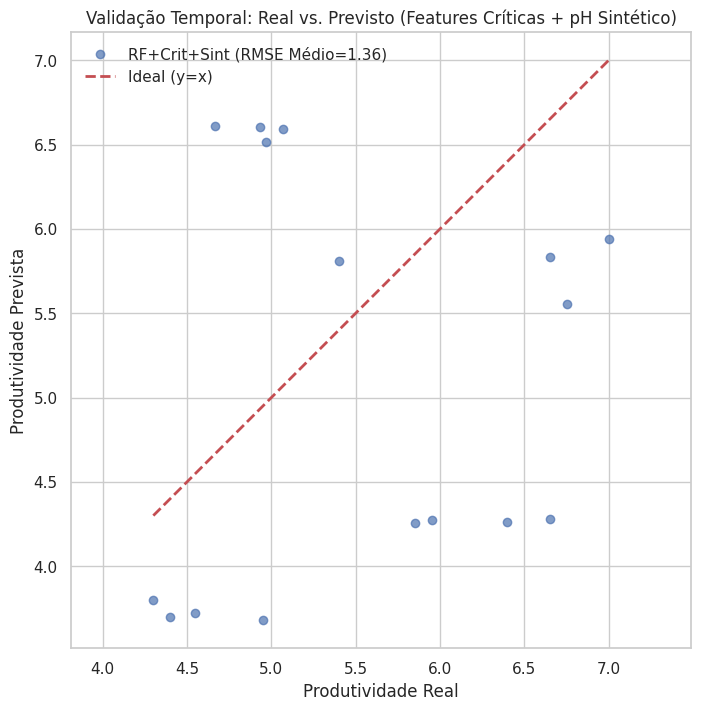


  --- Importância Média das Features (RF + Crítico/Sintético) ---
                                    Feature  Importance
16                                      ANO    0.425137
9          UMIDADE_media_mensal_max_critico    0.071012
0        RADIACAO_media_mensal_mean_critico    0.054671
2         RADIACAO_media_mensal_max_critico    0.047016
12          NDVI_satveg_mensal_mean_critico    0.043296
4      TEMPERATURA_media_mensal_min_critico    0.036596
7         UMIDADE_media_mensal_mean_critico    0.035450
6   PRECIPITACAO_mm_mensal_soma_sum_critico    0.034795
14           NDVI_satveg_mensal_min_critico    0.034512
8          UMIDADE_media_mensal_min_critico    0.034400
1         RADIACAO_media_mensal_min_critico    0.033907
15                        ph_solo_sintetico    0.032405
13           NDVI_satveg_mensal_max_critico    0.031243
5      TEMPERATURA_media_mensal_max_critico    0.028210
3     TEMPERATURA_media_mensal_mean_critico    0.021335
10      VENTO_VEL_media_mensal_mean_c

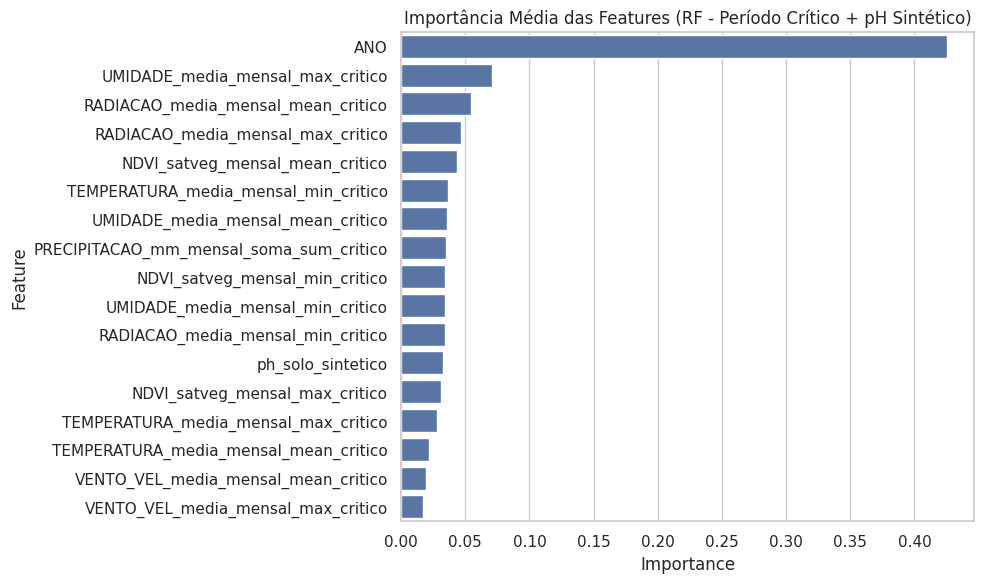


--- Treinamento do Modelo Final RandomForest (Opcional) ---
  Treinando modelo RandomForest final com todos os dados (features críticas + pH sintético)...
  Modelo RandomForest final treinado.
  Modelo final RandomForest salvo em: resultados/modelos/modelo_final_rf_critico_ph_sintetico.joblib

  Importância das Features (Modelo Final RF + Crítico/pH Sintético):
                                    Feature  Importance
16                                      ANO    0.475777
9          UMIDADE_media_mensal_max_critico    0.070439
13           NDVI_satveg_mensal_max_critico    0.059122
4      TEMPERATURA_media_mensal_min_critico    0.052114
15                        ph_solo_sintetico    0.045420
1         RADIACAO_media_mensal_min_critico    0.041342
7         UMIDADE_media_mensal_mean_critico    0.040118
12          NDVI_satveg_mensal_mean_critico    0.037165
2         RADIACAO_media_mensal_max_critico    0.034407
14           NDVI_satveg_mensal_min_critico    0.031375
8          UMIDADE_

In [9]:
# Dados sinteticos (ph ficticio) + reais

# -*- coding: utf-8 -*-
# Etapa 3: Construção do Modelo de IA (RF, Features Críticas Min/Max + pH Sintético)

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
import joblib # Para salvar o modelo treinado
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 3: Construção do Modelo (RF, Features Críticas Min/Max + pH Sintético) ---")

# --- 1. Carregar Dados Consolidados Mensais e Dados de Milho ---
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')
milho_path = os.path.join(processed_folder, 'milho.csv') # Carrega o milho processado

df_mensal = None
df_milho_proc = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    df_milho_proc = pd.read_csv(milho_path)
    print(f"[OK] Base consolidada mensal e base de milho carregadas.")

    # Prepara df_mensal
    if 'ANO' in df_mensal.columns: df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_mensal.")
    if 'MES' in df_mensal.columns: df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada em df_mensal.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    df_mensal = df_mensal.sort_values(by=['ANO', 'MES'])
    if df_mensal.empty: raise ValueError("DataFrame mensal vazio.")
    print(f"     Intervalo de Anos (Mensal): {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")

    # Prepara df_milho_proc
    if 'ANO' in df_milho_proc.columns: df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_milho_proc.")
    if 'Produtividade_Anual' in df_milho_proc.columns: df_milho_proc['Produtividade_Anual'] = pd.to_numeric(df_milho_proc['Produtividade_Anual'], errors='coerce')
    else: raise ValueError("Coluna 'Produtividade_Anual' não encontrada em df_milho_proc.")
    df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual'], inplace=True)
    if df_milho_proc.empty: raise ValueError("DataFrame de milho vazio após limpeza.")
    print(f"     Intervalo de Anos (Milho): {df_milho_proc['ANO'].min()} - {df_milho_proc['ANO'].max()}")


except FileNotFoundError as e:
    print(f"[ERRO CRÍTICO] Arquivo não encontrado: {e}.")
    # sys.exit()
except ValueError as ve:
     print(f"[ERRO CRÍTICO] Problema ao processar colunas ANO/MES/Produtividade: {ve}")
     # sys.exit()
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar ou processar dados: {e}")
    # sys.exit()

# --- 2. Engenharia de Atributos (Período Crítico com Min/Max) ---
print("\n--- Agregando Features do Período Crítico Anualmente (com Min/Max) ---")
meses_criticos = [2, 3, 4] # Exemplo: Fev, Mar, Abr
print(f"  Meses definidos como críticos: {meses_criticos}")
df_anual_critico_agg = None

if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame) and not df_mensal.empty:
    df_periodo_critico = df_mensal[df_mensal['MES'].isin(meses_criticos)].copy()
    if not df_periodo_critico.empty:
        print(f"  Dados filtrados para os meses críticos. Linhas restantes: {len(df_periodo_critico)}")
        # Define as agregações, incluindo min e max
        aggregations_critico = {
            'RADIACAO_media_mensal': ['mean', 'min', 'max'], # <<< Adicionado Min/Max
            'TEMPERATURA_media_mensal': ['mean', 'min', 'max'],
            'PRECIPITACAO_mm_mensal_soma': ['sum'],
            'UMIDADE_media_mensal': ['mean', 'min', 'max'], # <<< Adicionado Min/Max
            'VENTO_VEL_media_mensal': ['mean', 'max'],     # <<< Adicionado Max
            'NDVI_satveg_mensal': ['mean', 'max', 'min']   # <<< Adicionado Min
        }
        # Filtra apenas colunas existentes e funções de agregação válidas
        agg_funcs_critico_existentes = {}
        for col, funcs in aggregations_critico.items():
            if col in df_periodo_critico.columns:
                # Garante que a coluna seja numérica antes de agregar
                if pd.api.types.is_numeric_dtype(df_periodo_critico[col]):
                     agg_funcs_critico_existentes[col] = funcs
                else:
                     print(f"    [AVISO] Coluna '{col}' não é numérica, pulando agregação.")
            else:
                print(f"    [AVISO] Coluna '{col}' não encontrada para agregação.")

        if agg_funcs_critico_existentes:
            try:
                df_anual_critico_agg = df_periodo_critico.groupby('ANO', observed=False).agg(agg_funcs_critico_existentes)
                df_anual_critico_agg.columns = ['_'.join(col).strip() + '_critico' for col in df_anual_critico_agg.columns.values]
                df_anual_critico_agg.dropna(axis=1, how='all', inplace=True) # Remove colunas só com NaN
                df_anual_critico_agg = df_anual_critico_agg.sort_index()
                if df_anual_critico_agg.empty: raise ValueError("DataFrame agregado vazio.")
                print("[OK] Agregação anual (período crítico com min/max) concluída.")
                print(f"     Dimensões da base agregada: {df_anual_critico_agg.shape}")
            except Exception as e_agg: print(f"[ERRO] Falha na agregação: {e_agg}"); df_anual_critico_agg = None
        else: print("[ERRO] Nenhuma coluna válida para agregação."); df_anual_critico_agg = None
    else: print("[ERRO] Nenhum dado nos meses críticos."); df_anual_critico_agg = None
else: print("[ERRO] DataFrame mensal não definido."); df_anual_critico_agg = None

# --- 3. Preparar Dados de Produtividade (Média Anual por Ano) ---
print("\n--- Preparando Produtividade (Média Anual) ---")
df_prod_anual_media = None
if 'df_milho_proc' in locals() and isinstance(df_milho_proc, pd.DataFrame):
     if 'ANO' in df_milho_proc.columns and 'Produtividade_Anual' in df_milho_proc.columns:
          try:
               # Calcula a média da produtividade para cada ano (caso haja múltiplas safras)
               df_prod_anual_media = df_milho_proc.groupby('ANO', observed=False)['Produtividade_Anual'].mean().reset_index()
               # Renomeia para evitar conflito se já existir média no nome
               df_prod_anual_media = df_prod_anual_media.rename(columns={'Produtividade_Anual': 'Produtividade_Anual_Media'})
               if not df_prod_anual_media.empty:
                    print("[OK] Produtividade média anual calculada.")
               else: print("[AVISO] DataFrame de produtividade média anual vazio.")
          except Exception as e_prod_agg: print(f"[ERRO] Falha ao agregar produtividade: {e_prod_agg}"); df_prod_anual_media = None
     else: print("[ERRO] Colunas ANO ou Produtividade_Anual não encontradas em df_milho_proc.")
else: print("[ERRO] df_milho_proc não disponível.")


# --- 4. Merge e Criação da Base Final para Modelagem ---
print("\n--- Criando Base Final para Modelagem ---")
df_modelar = None
if 'df_anual_critico_agg' in locals() and isinstance(df_anual_critico_agg, pd.DataFrame) and \
   'df_prod_anual_media' in locals() and isinstance(df_prod_anual_media, pd.DataFrame):
    try:
        # Junta os dados agregados do período crítico com a produtividade média anual
        # Usa 'inner' merge para manter apenas os anos presentes em AMBOS datasets
        df_modelar = pd.merge(df_anual_critico_agg.reset_index(), # Traz ANO para coluna
                              df_prod_anual_media,
                              on='ANO',
                              how='inner') # Garante que só temos anos com ambos os dados
        df_modelar = df_modelar.set_index('ANO').sort_index() # Define ANO como índice novamente

        if not df_modelar.empty:
            print("[OK] Merge realizado. Base para modelagem criada.")
            print(f"     Dimensões da base para modelar: {df_modelar.shape}")

            # Adicionar Feature Sintética de pH (Aleatório entre 5.5 e 7.0)
            print("  + Adicionando feature sintética de pH...")
            np.random.seed(42) # Para reprodutibilidade do aleatório
            df_modelar['ph_solo_sintetico'] = np.random.uniform(5.5, 7.0, size=len(df_modelar))

            # Adicionar Feature ANO (se não for o índice) - Neste caso, ANO é o índice
            # df_modelar['ANO_feature'] = df_modelar.index

            print("     Primeiras linhas da base para modelar:")
            print(df_modelar.head())
            print("\n     Colunas finais para modelagem:")
            print(df_modelar.columns.tolist())

        else:
            print("[ERRO] Base para modelagem vazia após o merge. Verifique a sobreposição de anos.")
            df_modelar = None

    except Exception as e_merge:
        print(f"[ERRO] Falha durante o merge final: {e_merge}")
        df_modelar = None
else:
    print("[ERRO] DataFrames agregados ou de produtividade não estão disponíveis para o merge.")

# --- 5. Seleção de Atributos (Features) e Alvo (Target) ---
print("\n--- Selecionando Features e Target ---")
X = None; y = None; features_cols = []
if 'df_modelar' in locals() and isinstance(df_modelar, pd.DataFrame) and 'Produtividade_Anual_Media' in df_modelar.columns:
    target = 'Produtividade_Anual_Media' # Alvo é a produtividade média anual
    y = df_modelar[target]
    features_cols = [col for col in df_modelar.columns if col != target]
    # Adiciona ANO (índice) como feature
    X = df_modelar[features_cols].copy()
    X['ANO'] = X.index # Adiciona o índice ANO como uma coluna feature
    features_cols.append('ANO') # Adiciona à lista de nomes

    # Preenchimento de NaNs
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features com a média...");
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): print(f"  [ERRO] NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); X = None

    if X is not None: print(f"[OK] Target: '{target}' ({len(y)} amostras). Features: {len(features_cols)} ({X.shape[0]} amostras)."); print("     Features:", features_cols)
else: print("[ERRO] DataFrame para modelar ou Target não disponíveis.")


# --- 6. Validação Cruzada Temporal com RandomForestRegressor ---
print("\n--- Implementando Validação Cruzada Temporal (RandomForest com Features Refinadas) ---")
# (A lógica da validação cruzada com RF permanece a mesma da versão anterior - ID: etapa3_modelo_ia_v5_rf_critico)
# Apenas garantimos que ela use o X e y definidos nesta célula.

if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")

        fold_metrics_rf = {'r2': [], 'rmse': [], 'mae': []}
        fold_counter = 0
        all_y_test_ts = []
        all_y_pred_rf = []
        feature_importances_list = []

        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]
            anos_treino = X_train_ts.index.tolist(); anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                print("    Treinando RandomForestRegressor...")
                rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
                rf_model.fit(X_train_ts, y_train_ts)
                y_pred_rf = rf_model.predict(X_test_ts)

                r2_rf = r2_score(y_test_ts, y_pred_rf) if len(y_test_ts) > 1 else np.nan
                rmse_rf = np.sqrt(mean_squared_error(y_test_ts, y_pred_rf))
                mae_rf = mean_absolute_error(y_test_ts, y_pred_rf)
                fold_metrics_rf['r2'].append(r2_rf); fold_metrics_rf['rmse'].append(rmse_rf); fold_metrics_rf['mae'].append(mae_rf)
                print(f"      RF - Métricas: R²={r2_rf:.4f}, RMSE={rmse_rf:.4f}, MAE={mae_rf:.4f}")

                if hasattr(rf_model, 'feature_importances_'): feature_importances_list.append(rf_model.feature_importances_)
                all_y_test_ts.extend(y_test_ts.tolist()); all_y_pred_rf.extend(y_pred_rf.tolist())

            except Exception as e_fold:
                print(f"    [ERRO] Falha no Fold {fold_counter}: {e_fold}")
                fold_metrics_rf['r2'].append(np.nan); fold_metrics_rf['rmse'].append(np.nan); fold_metrics_rf['mae'].append(np.nan)

        # --- Resultados Consolidados da Validação Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal (RF + Crítico/Sintético) ---")
        if fold_metrics_rf['rmse']:
             print(f"    R² Médio    : {np.nanmean(fold_metrics_rf['r2']):.4f} ± {np.nanstd(fold_metrics_rf['r2']):.4f}")
             print(f"    RMSE Médio  : {np.nanmean(fold_metrics_rf['rmse']):.4f} ± {np.nanstd(fold_metrics_rf['rmse']):.4f}")
             print(f"    MAE Médio   : {np.nanmean(fold_metrics_rf['mae']):.4f} ± {np.nanstd(fold_metrics_rf['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        # --- Plot Consolidado: Real vs Previsto ---
        print("\n  --- Gráfico Consolidado: Real vs. Previsto (RF + Crítico/Sintético) ---")
        if all_y_test_ts:
             plt.figure(figsize=(8, 8))
             plt.scatter(all_y_test_ts, all_y_pred_rf, alpha=0.7, label=f'RF+Crit+Sint (RMSE Médio={np.nanmean(fold_metrics_rf["rmse"]):.2f})')
             min_val = min(all_y_test_ts); max_val = max(all_y_test_ts)
             plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
             plt.xlabel('Produtividade Real'); plt.ylabel('Produtividade Prevista')
             plt.title('Validação Temporal: Real vs. Previsto (Features Críticas + pH Sintético)')
             plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()
        else: print("    Nenhuma previsão válida gerada.")

        # --- Análise de Importância Média das Features ---
        if feature_importances_list and features_cols:
             print("\n  --- Importância Média das Features (RF + Crítico/Sintético) ---")
             mean_importances = np.mean(feature_importances_list, axis=0)
             # Garante que o número de nomes de features corresponda ao número de importâncias
             if len(features_cols) == len(mean_importances):
                  feature_importance_df = pd.DataFrame({'Feature': features_cols, 'Importance': mean_importances})
                  feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
                  print(feature_importance_df)
                  plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.3)))
                  sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
                  plt.title('Importância Média das Features (RF - Período Crítico + pH Sintético)')
                  plt.tight_layout(); plt.show()
             else:
                  print(f"  [ERRO] Discrepância entre número de features ({len(features_cols)}) e importâncias ({len(mean_importances)}).")

    elif n_anos <= 1: print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit.")
    else: print(f"[AVISO] Número de splits ({n_splits_ts}) inválido. Validação não executada.")
else:
    print("[ERRO] Dados (X, y) com features refinadas não disponíveis para Validação.")


# --- 7. Treinar Modelo Final e Salvar (Opcional) ---
print("\n--- Treinamento do Modelo Final RandomForest (Opcional) ---")
final_model_rf = None
if X is not None and y is not None:
     try:
          print("  Treinando modelo RandomForest final com todos os dados (features críticas + pH sintético)...")
          final_model_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
          final_model_rf.fit(X, y)
          print(f"  Modelo RandomForest final treinado.")
          model_folder = os.path.join('resultados', 'modelos')
          os.makedirs(model_folder, exist_ok=True)
          model_path_final_rf = os.path.join(model_folder, 'modelo_final_rf_critico_ph_sintetico.joblib') # Nome diferente
          try: import joblib
          except ImportError: print("[ERRO] Biblioteca 'joblib' não instalada."); raise
          joblib.dump(final_model_rf, model_path_final_rf)
          print(f"  Modelo final RandomForest salvo em: {model_path_final_rf}")

          if hasattr(final_model_rf, 'feature_importances_') and hasattr(X, 'columns'):
               print("\n  Importância das Features (Modelo Final RF + Crítico/pH Sintético):")
               importances_final = final_model_rf.feature_importances_
               feature_names_final = X.columns
               feature_importance_df_final = pd.DataFrame({'Feature': feature_names_final, 'Importance': importances_final})
               feature_importance_df_final = feature_importance_df_final.sort_values(by='Importance', ascending=False)
               print(feature_importance_df_final)

     except Exception as e_final: print(f"[ERRO] Falha ao treinar ou salvar o modelo final: {e_final}")
else: print("  Dados (X, y) não disponíveis para treinar modelo final.")

print("\n--- Fim da Etapa 3 (RF com Features Críticas Min/Max + pH Sintético) ---")



# Etapa 4



*   Testar o modelo com diferentes períodos de dados, avaliando sua precisão e confiabilidade.
*   Ajustar a estratégia de modelagem com base nos resultados obtidos.
*   Gerar visualizações e métricas de desempenho para demonstrar os insights obtidos.





In [15]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.3 MB/s eta 0:00:00


In [16]:
!streamlit run app_produtividade.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app_produtividade.py


2025-04-26 14:34:21.507 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-26 14:34:21.512 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-26 14:34:21.682 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-26 14:34:21.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-26 14:34:21.688 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-26 14:34:21.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-26 14:34:21.696 No runtime found, using MemoryCacheStorageManager
2025-04-26 14:34:21.703 No runtime

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

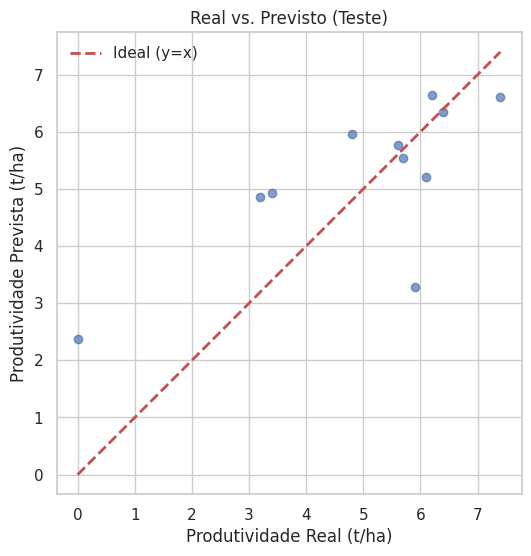

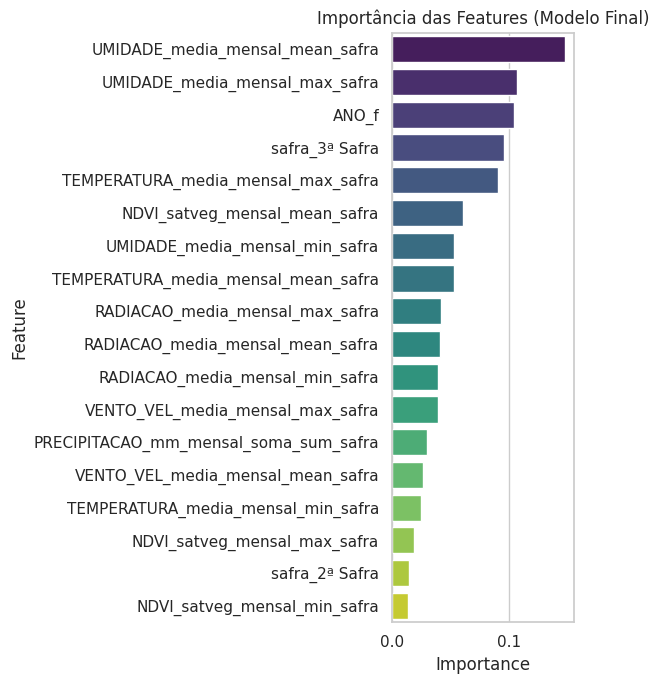

In [17]:
# -*- coding: utf-8 -*-
# Aplicação Streamlit para Visualização do Modelo de Previsão de Produtividade

import streamlit as st
import pandas as pd
import numpy as np
import os
import joblib # Para carregar o modelo salvo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor # Apenas para type hint, o modelo é carregado
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configurações Iniciais e Carregamento ---
st.set_page_config(layout="wide", page_title="Dashboard Produtividade Milho")

st.title("🌽 Dashboard de Previsão da Produtividade de Milho (Sorriso-MT)")
st.markdown("""
Esta aplicação demonstra os resultados de um modelo de Machine Learning (RandomForest)
treinado para prever a produtividade anual de milho (t/ha) por safra, utilizando dados
climáticos e de NDVI (SatVeg) agregados por safra.
**Fonte de Dados:** CONAB, INMET, SatVeg (Processados nas Etapas 1 e 2).
**Modelo:** RandomForestRegressor otimizado (Etapa 3).
""")

# --- Funções Auxiliares (Recriar Dados e Features) ---
# É necessário recriar os dados EXATAMENTE como na Etapa 3 para obter o X_test/y_test corretos
@st.cache_data # Cache para evitar recálculos desnecessários
def carregar_e_preparar_dados(processed_folder):
    """Carrega e prepara os DataFrames base."""
    consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')
    milho_path = os.path.join(processed_folder, 'milho.csv')
    df_mensal = None
    df_milho_proc = None

    try:
        df_mensal = pd.read_csv(consolidated_monthly_path)
        df_milho_proc = pd.read_csv(milho_path)

        # Preparação básica (tipos, NaNs)
        if 'ANO' in df_mensal.columns: df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
        else: raise ValueError("Coluna 'ANO' não encontrada em df_mensal.")
        if 'MES' in df_mensal.columns: df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
        else: raise ValueError("Coluna 'MES' não encontrada em df_mensal.")
        df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
        for col in df_mensal.select_dtypes(include=np.number).columns:
            if col not in ['ANO', 'MES']: df_mensal[col] = pd.to_numeric(df_mensal[col], errors='coerce')

        if 'ANO' in df_milho_proc.columns: df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce').astype('Int64')
        else: raise ValueError("Coluna 'ANO' não encontrada em df_milho_proc.")
        if 'Produtividade_Anual' in df_milho_proc.columns: df_milho_proc['Produtividade_Anual'] = pd.to_numeric(df_milho_proc['Produtividade_Anual'], errors='coerce')
        else: raise ValueError("Coluna 'Produtividade_Anual' não encontrada.")
        if 'safra' not in df_milho_proc.columns: raise ValueError("Coluna 'safra' não encontrada.")
        df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'], inplace=True)

        if df_mensal.empty or df_milho_proc.empty: raise ValueError("DataFrames vazios após preparação inicial.")

        return df_mensal, df_milho_proc

    except FileNotFoundError as e:
        st.error(f"Erro: Arquivo CSV processado não encontrado: {e}. Verifique a pasta '{processed_folder}'.")
        return None, None
    except Exception as e:
        st.error(f"Erro ao carregar ou preparar dados base: {e}")
        return None, None

@st.cache_data # Cache para evitar recálculos
def agregar_features_por_safra(df_mensal, df_milho_proc):
    """Agrega features climáticas/NDVI por safra."""
    if df_mensal is None or df_milho_proc is None:
        return None

    meses_safra1 = [(10, -1), (11, -1), (12, -1), (1, 0), (2, 0)]
    meses_safra2 = [(2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]
    meses_safra3 = [(5, 0), (6, 0), (7, 0), (8, 0), (9, 0)]
    agg_config = {
        'mean': ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
        'min':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'NDVI_satveg_mensal'],
        'max':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
        'sum':  ['PRECIPITACAO_mm_mensal_soma']
    }
    lista_features_safra = []

    for index, row in df_milho_proc.iterrows():
        ano_agricola = row['ANO']; tipo_safra = row['safra']; produtividade = row['Produtividade_Anual']
        meses_anos_target = []; meses_anos_base = None
        if '1ª' in tipo_safra: meses_anos_base = meses_safra1
        elif '2ª' in tipo_safra: meses_anos_base = meses_safra2
        elif '3ª' in tipo_safra: meses_anos_base = meses_safra3
        else: continue # Pula safra não reconhecida
        for mes, deslocamento_ano in meses_anos_base: meses_anos_target.append((ano_agricola + deslocamento_ano, mes))
        df_mensal_safra = df_mensal[df_mensal.set_index(['ANO', 'MES']).index.isin(meses_anos_target)]
        if df_mensal_safra.empty: continue

        features_safra_dict = {'ANO': ano_agricola, 'safra': tipo_safra, 'Produtividade_Anual': produtividade}
        for agg_func, cols_to_agg in agg_config.items():
            cols_existentes = [col for col in cols_to_agg if col in df_mensal_safra.columns]
            if not cols_existentes: continue
            try:
                aggregated_data = df_mensal_safra[cols_existentes].agg(agg_func)
                for col_original, valor_agregado in aggregated_data.items(): features_safra_dict[f"{col_original}_{agg_func}_safra"] = valor_agregado
            except Exception as e_agg: print(f"Erro agregando {agg_func} para {ano_agricola}/{tipo_safra}: {e_agg}") # Log interno
        lista_features_safra.append(features_safra_dict)

    if lista_features_safra:
        df_modelar_safra = pd.DataFrame(lista_features_safra)
        if 'ANO' in df_modelar_safra.columns and 'safra' in df_modelar_safra.columns:
            df_modelar_safra = df_modelar_safra.set_index(['ANO', 'safra']).sort_index()
            return df_modelar_safra
    return None

@st.cache_data # Cache
def preparar_X_y(df_modelar_safra):
    """Prepara X e y a partir do DataFrame agregado por safra."""
    if df_modelar_safra is None or 'Produtividade_Anual' not in df_modelar_safra.columns:
        return None, None, None

    target = 'Produtividade_Anual'
    y = df_modelar_safra[target]
    features_cols_init = [col for col in df_modelar_safra.columns if col != target]
    X = df_modelar_safra[features_cols_init].copy()
    X['ANO_f'] = X.index.get_level_values('ANO').astype(int)
    X['safra_f'] = X.index.get_level_values('safra')
    X = pd.get_dummies(X, columns=['safra_f'], prefix='safra', drop_first=True)
    features_cols = X.columns.tolist()

    # Preenchimento de NaNs
    if X.isnull().any().any():
         st.warning("Preenchendo NaNs nas features com a média...")
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean(); means = means.fillna(0)
         X.fillna(means, inplace=True)
         if X.isnull().any().any():
              st.error(f"NaNs persistentes após preenchimento: {X.columns[X.isnull().any()].tolist()}")
              return None, None, None
    return X, y, features_cols

# --- Carregar Modelo Salvo ---
@st.cache_resource # Cache para o modelo carregado
def carregar_modelo(model_path):
    """Carrega o modelo .joblib salvo."""
    try:
        model = joblib.load(model_path)
        st.success(f"Modelo carregado com sucesso de: {model_path}")
        return model
    except FileNotFoundError:
        st.error(f"Erro: Arquivo do modelo não encontrado em '{model_path}'. Execute a Etapa 3 para salvá-lo.")
        return None
    except Exception as e:
        st.error(f"Erro ao carregar o modelo: {e}")
        return None

# --- Execução Principal ---
# Define caminhos
processed_folder = 'dados_processados'
results_folder = 'resultados'
model_folder = os.path.join(results_folder, 'modelos')
# Usa o nome do modelo otimizado salvo na última execução da Etapa 3
model_path = os.path.join(model_folder, 'modelo_final_rf_por_safra_otimizado.joblib')

# Carrega os dados base
df_mensal, df_milho_proc = carregar_e_preparar_dados(processed_folder)

# Gera a base agregada por safra
df_modelar_safra = None
if df_mensal is not None and df_milho_proc is not None:
    df_modelar_safra = agregar_features_por_safra(df_mensal, df_milho_proc)

# Prepara X e y
X, y, features_cols = preparar_X_y(df_modelar_safra)

# Carrega o modelo
best_model_rf = carregar_modelo(model_path)

# --- Exibir Resultados (se tudo carregou corretamente) ---
if X is not None and y is not None and best_model_rf is not None:
    st.header("Avaliação do Modelo Otimizado")

    # Recriar a divisão Treino/Teste para obter X_test, y_test
    # É crucial usar o mesmo random_state e estratificação da Etapa 3
    X_train, X_test, y_train, y_test = None, None, None, None
    try:
        safra_original = df_modelar_safra.loc[X.index].index.get_level_values('safra') # Pega a safra correspondente a X
        test_size_ratio = 0.25
        min_samples_per_class = 2
        counts = safra_original.value_counts()
        if safra_original.nunique() > 1 and all(counts >= min_samples_per_class):
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42, stratify=safra_original)
        else:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)
        st.write(f"Dados divididos para avaliação: {len(X_train)} treino, {len(X_test)} teste.")

    except Exception as e_split:
         st.error(f"Erro ao recriar divisão treino/teste: {e_split}")

    # Avaliar no conjunto de teste (se a divisão funcionou)
    if X_test is not None and y_test is not None:
        try:
            y_pred = best_model_rf.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            mae = mean_absolute_error(y_test, y_pred)

            st.subheader("Métricas de Desempenho (Conjunto de Teste)")
            col1, col2, col3 = st.columns(3)
            col1.metric("R² (R-quadrado)", f"{r2:.4f}")
            col2.metric("RMSE (t/ha)", f"{rmse:.4f}")
            col3.metric("MAE (t/ha)", f"{mae:.4f}")
            st.caption(f"R²: Proporção da variância explicada (quanto maior, melhor). RMSE/MAE: Erro médio da previsão (quanto menor, melhor).")

            st.subheader("Gráficos de Avaliação")
            col_g1, col_g2 = st.columns(2)

            with col_g1:
                # Gráfico Real vs Previsto
                fig1, ax1 = plt.subplots(figsize=(6, 6))
                ax1.scatter(y_test, y_pred, alpha=0.7)
                min_val = min(y_test.min(), y_pred.min()); max_val = max(y_test.max(), y_pred.max())
                ax1.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
                ax1.set_xlabel('Produtividade Real (t/ha)')
                ax1.set_ylabel('Produtividade Prevista (t/ha)')
                ax1.set_title('Real vs. Previsto (Teste)')
                ax1.legend(); ax1.grid(True); ax1.axis('equal')
                st.pyplot(fig1)

            with col_g2:
                # Importância das Features
                if hasattr(best_model_rf, 'feature_importances_') and hasattr(X_train, 'columns'):
                    importances = best_model_rf.feature_importances_
                    feature_names = X_train.columns # Usa colunas do treino
                    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
                    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

                    fig2, ax2 = plt.subplots(figsize=(6, 7)) # Ajusta tamanho
                    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, ax=ax2, palette='viridis')
                    ax2.set_title('Importância das Features (Modelo Final)')
                    plt.tight_layout()
                    st.pyplot(fig2)
                else:
                    st.warning("Não foi possível extrair a importância das features do modelo carregado.")

            # Mostrar tabela de comparação (opcional)
            st.subheader("Comparação Detalhada (Conjunto de Teste)")
            df_resultados = pd.DataFrame({'Real': y_test, 'Previsto': y_pred, 'Erro': y_test - y_pred})
            st.dataframe(df_resultados.style.format('{:.2f}').background_gradient(cmap='RdYlGn', subset=['Erro'], axis=0, low=0.4, high=0.4))


        except Exception as e_eval:
            st.error(f"Erro ao avaliar o modelo no conjunto de teste: {e_eval}")

    else:
        st.error("Não foi possível recriar os dados de teste para avaliação.")

else:
    st.error("Não foi possível carregar todos os dados necessários ou o modelo. Verifique as etapas anteriores e os caminhos dos arquivos.")

st.sidebar.header("Sobre")
st.sidebar.info("Este dashboard apresenta os resultados de um modelo RandomForest para prever a produtividade de milho em Sorriso-MT, usando dados climáticos e NDVI SatVeg agregados por safra.")
st.sidebar.header("Arquivos Necessários")
st.sidebar.markdown(f"- `{consolidated_monthly_path}`")
st.sidebar.markdown(f"- `{milho_path}`")
st.sidebar.markdown(f"- `{model_path}`")



In [18]:
!pip install pyngrok -q

In [19]:
# Importa bibliotecas necessárias
from pyngrok import ngrok
import os

# Define a porta padrão do Streamlit
port = 8501

# Configura o authtoken do ngrok (substitua pelo seu)
# É importante fazer isso ANTES de abrir o túnel
ngrok.set_auth_token("2wGqptEkQTG7ZEKY5uBlrv8XIkR_45gVgfX3UJ6oeW6djrVBY")

# Executa o Streamlit em segundo plano (&) e abre o túnel ngrok
# Certifique-se que 'app_produtividade.py' está no diretório correto
os.system(f"streamlit run app_produtividade.py --server.port {port} &")

# Abre um túnel HTTP para a porta do Streamlit
public_url = ngrok.connect(port)
print("---")
print(f"Aplicação Streamlit rodando! Acesse em: {public_url}")
print("---")
# ngrok.kill() # Descomente esta linha se quiser parar o túnel depois

---
Aplicação Streamlit rodando! Acesse em: NgrokTunnel: "https://1385-35-196-143-233.ngrok-free.app" -> "http://localhost:8501"
---
